# TSARA, Phase 4 — combining measurements without inventing any

**A walkthrough you can run, change and try to break.** Every number and figure
below is produced by the package from data manufactured inside this notebook,
where the truth is known. No real measurement is read, and nothing needs
mounting. Notebook `04b` runs the same operations on the campaign archive.

---

## How to use this notebook

1. **Run everything once** (*Run All*, under a minute).
2. **Every section stands on its own.** Each one opens with a **parameters
   cell**: a short list of CAPITALISED names, each commented with what it
   controls. Change a value, then run that section's cells from the parameters
   cell down to the next section heading. A section reads nothing that another
   section made; all of them share only the two setup cells below.
3. **Every section prints checks.** A line beginning ✔ is a claim about TSARA,
   compared *as it ran* against a calculation written independently in this
   notebook: a loop written from the definition, a closed form, or random draws
   whose truth is known. The checks are written to hold at *any* parameters you
   choose. If you ever see ✘, you have found an edge case worth understanding
   or a bug. Either way, bring it back.
4. **"Try it"** notes after each section suggest a change and say what should
   happen. Each prediction was run before this notebook was committed.
5. **Section 15** collects every check into one scoreboard, and lists what is
   known to be imperfect.

When a section describes package code, it names the function and the file, for
example `bin_streams_onto_cells` in `src/tsara/align/binning.py`. That code is
commented so that it can be read alongside.

---

## What you asked for, and what this phase has to deliver

You described TSARA as *"a loader and transformer that allows us to run
parameter sweeps and determine the effect different things have on running a
PMF-like analysis"*, and said the eventual matrix *"should be able to hold
nearly anything flexibly."*

Phase 4 is the first stage that **combines** measurements. Everything before
it applies a declared, exact, one-to-one map: a unit conversion, a sigma from a
declared budget, a timestamp moved to its cell midpoint. Each of those can be
undone. A value averaged from many readings cannot, and a wrong one looks just
as plausible as a right one, because a transformation carries no correctness
signal the way a file that fails to parse does. So this notebook spends most of
its length on **evidence**.

For everything later to be trustworthy, this phase has to deliver seven
properties:

| | Property | Tested in |
|---|---|---|
| 1 | **One joining operation**, blind to what it joins: species, baselines, met, anything, onto any cells | §1, §2, §12 |
| 2 | **Exact weighting**: every value counts by how much of its interval falls in the target | §1, §2, §3 |
| 3 | **No invented gas data**: gases are averaged, never interpolated, and never copied onto finer cells unless asked by name -- and every column records what the join did to it | §4, §11, §12 |
| 4 | **Honest uncertainty**: random error shrinks under averaging, systematic error does not, and correlated error shrinks by less | §5, §6, §7 |
| 5 | **An honest N for regressions**: no reading counted twice without the product saying so | §8, §9, §12 |
| 6 | **Directions and positions treated as what they are** | §10, §11 |
| 7 | **Ratios survive the whole join**, and the check can see a tenth of a second of misplacement | §14 |

What this phase does **not** do: baselines and enhancements (Phase 5), plume
detection (Phase 6), regression and the uncertainty cube (Phase 7). Section 13
shows the one operation this phase refuses on your decision, and why.

---

## How a synthetic campaign fits together

Every section manufactures its data with the generator from notebook 01. A
campaign is described in three parts, in the order a campaign happens: where the
air is sampled, **what the air is**, and **who measures it**. The recipes cell
below writes each description as a Python dict called `campaign_description`;
a YAML file with the same keys works identically.

```
campaign_description
 ├─ platform        where the air is sampled: a fixed site, or a van with a GPS
 ├─ atmosphere      what the air IS, whoever measures it
 │   ├─ fields      one per physical quantity (ch4, benzene, …), each with a
 │   │              background: a level, a daily cycle, a drift, a wander
 │   └─ sources     emitters whose plumes cross the air, carrying several
 │                  fields at known ratios
 └─ instruments     who measures it, each on its own clock, with its own cells
     └─ measures    which fields, under what variable name, with what error
                │
          generate(SyntheticConfig.model_validate(campaign_description))
                │
                ▼
data.atmosphere     the truth: any field, at any instant or averaged over any cell
data.streams        one dataset per instrument: what it would have written
data.ground_truth   one row per plume per measured variable: when, how big, what ratio
```

The atmosphere is realized **once**, before any instrument exists, so two
instruments measuring `ch4` sample the same methane: the same background, the
same plumes. Whatever differs between their records is theirs, which is what
lets this notebook blame a disagreement on the join, the noise or the support,
and on nothing else.

Four kinds of name appear, and each has to be unique only where it is used:

| name | unique within | examples here |
|---|---|---|
| **field** | the atmosphere | `ch4`, `benzene`, `tracer` |
| **source** (an emitter) | the atmosphere | `well_pad`, `refinery` |
| **instrument** | the campaign | `fast`, `minute`, `iwas`, `methane_analyzer`, `van_analyzer` |
| **variable** | one instrument | `ch4` on `fast` and `minute_ch4` on `minute`, both recording `field: ch4` |

A variable says which field it measures in its `field` attribute, and ingestion
writes the same attribute from a manifest, so real and synthetic streams carry
the same identity (`METHODS.md` §1.6). Two instruments may even use the same
variable name; section 8 shows what a join does then.

---

## Rows, readings and pairs

Three counts appear throughout, and most of this phase's refusals and warnings
are about keeping them apart.

* A **reading** is one value an instrument wrote: one row of its *own* stream,
  describing one cell of air.
* A **row** is one line of a product TSARA builds, a joined table or a grid. It
  describes a *target* cell, and may be built from many readings or from part of
  one.
* A **pair** is a row of a paired product: a cell where both species of a
  regression have a value.

Normally several readings make one row. The reverse is where the trouble is:
**one reading can land in more than one row.** Think of trips on a monthly
calendar. A trip from 30 June to 2 July is marked in June *and* in July. The
calendar is right to show both, but count "months with a trip" and you have
counted one trip twice. A canister fill that straddles a grid boundary is that
trip:

```
60 s grid rows    |    row A     |    row B     |    row C     |
canister fills        [fill 1]            [fill 2]
                      inside A            straddles B | C

rows holding benzene:  A, B, C   = 3 rows
readings behind them:  fill 1, fill 2   = 2 readings
```

Both rows B and C honestly contain part of fill 2, and each reports the value
fill 2 measured. What would be wrong is a regression or a receptor model
treating B and C as two independent measurements. So TSARA counts both. In
section 12, the 55 canister fills of an eight-hour campaign put on a 60 s grid
occupy **69 rows**: 14 fills straddle a minute boundary. The grid records
`tsara_n_readings = 55` beside the column and warns. Pairing records the same
attribute over its surviving pairs (section 9), and it is how the walkthrough
found a real case: on the 2024-07-18 drive, one argument order made **16,893
pairs from 8,447 CO₂ readings** (`METHODS.md` §11.4; notebook 04b shows it on
the files).

`n_readings_<var>` is a third count, and a different one: how many readings
contributed to *this row*, whole or in part.

---

## Vocabulary used throughout

| term | meaning |
|---|---|
| **cell** | the interval of air one row describes. Stored as `time_bnds` (start, stop); `time` is its midpoint |
| **support** | what a cell is: a *point* sample at one instant, or a *mean* over the whole cell |
| **label** | which part of its cell a file's timestamp names: `start`, `mid` or `end` |
| **source** | an *emission* source only: something emitting gases at a ratio, such as `well_pad`. Never the input of a join, a file, or where a number came from |
| **readings / target cells** | the input of a join, each reading with its own cell / the cells a join puts values onto |
| **provenance** | where a number or a fact came from: `declared`, `reported`, `inferred`, `assumed`, `empirical` (e.g. `uncertainty_provenance`) |
| **field** | a physical quantity of the atmosphere, e.g. `ch4`; every variable records the field it measures |
| **reading / row / pair** | a value an instrument wrote / a line of a product TSARA builds / a row where both species have a value (see above) |
| **overlap weight** | how much of a reading's cell (in nanoseconds) falls inside a target cell |
| `n_readings_<var>` | how many readings contributed to a row, whole or in part |
| `coverage_<var>` | the fraction of a target cell's duration covered by contributing data |
| **readings** (as a count) | distinct readings behind a product's column. Fewer readings than rows means some reading sits in more than one row |
| **random / systematic** | the two uncertainty components: independent from reading to reading (averages down), or shared by all readings (does not) |
| **τ (tau)** | decorrelation timescale of a random error: how long consecutive errors stay alike |
| **N_eff** | the number of independent readings a mean of correlated ones is worth |
| **clock** | the cells a pair of species is put on for a regression |
| **grid** | uniform cells of one period covering a whole campaign |
| **R** | mean resultant length of averaged directions: 1 when all agree, 0 when they cancel |

---
## Setup (run these two cells first)

The first cell is the **toolkit**: imports, the figure style shared by
notebooks 01–04, helpers for building and drawing streams, and the
**reference implementations** every check compares TSARA against. The second
holds the **campaign recipes**, one function per synthetic campaign, whose
keyword arguments are the knobs the sections expose.

In [1]:
# =============================================================================
# TOOLKIT. Every section needs this cell and nothing else from other sections.
# =============================================================================
import logging
import tempfile
import time
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from tsara import setup_logging
from tsara.align import (
    TsaraAlignError,
    attach_positions,
    bin_streams_onto_cells,
    build_output_grid,
    interpolate_onto_cells,
    load_grid,
    pair_species,
    save_grid,
)
from tsara.config.analysis import OutputGridConfig
from tsara.config.loader import load_manifest
from tsara.core.bundle import TsaraBundleError
from tsara.core.circular import circular_mean
from tsara.core.naming import sigma_rand_name, sigma_sys_name
from tsara.core.propagation import (
    DOUBLE_SUM_MAX_POINTS,
    TsaraPropagationError,
    propagate_random,
    propagate_systematic,
)
from tsara.core.support import CellBounds
from tsara.ingest import ingest_campaign
from tsara.synthetic import generate
from tsara.synthetic.config import SyntheticConfig
from tsara.synthetic.export import export_raw

SECOND = 1_000_000_000  # TSARA keeps every time as integer nanoseconds

# --- 1. figure style (identical to notebooks 01, 02 and 03) ------------------
C1, C2, C3 = "#0072b2", "#e69f00", "#009e73"  # Okabe-Ito blue, amber, green: colour-blind safe
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": "#c3c2b7",
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "normal",
        "axes.titlelocation": "left",
        "axes.labelsize": 9.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "grid.color": GRID,
        "grid.linewidth": 0.7,
        "grid.linestyle": "-",
        "legend.frameon": False,
        "legend.fontsize": 9,
        "font.size": 9.5,
        "lines.linewidth": 1.4,
        "figure.dpi": 110,
    }
)


def finish(
    ax, title=None, sub=None, ylab=None, xlab=None, legend=False, grid_axis="y", loc="upper right"
):
    """Apply the shared chrome: left-aligned title, muted subtitle, hairline grid."""
    if title:
        ax.set_title(title, pad=19 if sub else 8)
    if sub:
        ax.text(0, 1.025, sub, transform=ax.transAxes, fontsize=8.8, color=MUTED, va="bottom")
    if ylab:
        ax.set_ylabel(ylab)
    if xlab:
        ax.set_xlabel(xlab)
    if grid_axis:
        ax.grid(True, axis=grid_axis, alpha=0.9)
    ax.set_axisbelow(True)
    if legend:
        ax.legend(loc=loc)


def hhmm(ax, fmt="%H:%M"):
    """Label the x axis as clock time; the date belongs in the title."""
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))


def break_gaps(clock, values, tolerance=5.0):
    """Insert a NaN wherever the clock jumps, so matplotlib draws no line across a gap.

    A plotted line is a straight segment between neighbouring points, so a hole
    in a record would otherwise render as a smooth ramp across it: exactly the
    interpolation TSARA refuses to perform on a gas.
    """
    clock, values = np.asarray(clock), np.asarray(values, dtype=float)
    steps = np.diff(clock).astype("timedelta64[ms]").astype(float)
    gaps = np.where(steps > tolerance * np.median(steps))[0]
    if gaps.size == 0:
        return clock, values
    return np.insert(clock, gaps + 1, clock[gaps]), np.insert(values, gaps + 1, np.nan)


# --- 2. streams and cells -----------------------------------------------------
def cells_of(stream):
    """Return a stream's cells as CellBounds: integer-nanosecond starts and stops.

    Every TSARA stream carries `time_bnds`, shape (time, 2), holding the start
    and stop of the interval of air each row describes.
    """
    edges = stream["time_bnds"].values.astype("datetime64[ns]").astype("int64")
    return CellBounds(start_ns=edges[:, 0].copy(), stop_ns=edges[:, 1].copy())


def bounds_of(stream):
    """Return cell starts and stops as datetime64 arrays, for drawing a value across its cell."""
    edges = stream["time_bnds"].values
    return edges[:, 0], edges[:, 1]


def uniform_cells(start, width_s, count):
    """Return `count` abutting cells, each `width_s` seconds wide, from `start`.

    `start` may be a timestamp string, a pandas Timestamp, or integer nanoseconds.
    """
    first = pd.Timestamp(start).value
    width = int(round(width_s * SECOND))
    starts = first + np.arange(count, dtype=np.int64) * width
    return CellBounds(start_ns=starts, stop_ns=starts + width)


def make_stream(start_ns, stop_ns, variables, attrs=None):
    """Build the smallest dataset TSARA accepts as a stream.

    All the join needs is one value per cell over a `time` axis and the cell
    edges in `time_bnds`; ingestion adds much more, none of which binning reads.
    `variables` maps a name to its values; `attrs` optionally maps a name to
    extra attributes such as {"role": "met", "circular": 1}.
    """
    start_ns = np.asarray(start_ns, dtype=np.int64)
    stop_ns = np.asarray(stop_ns, dtype=np.int64)
    attrs = attrs or {}
    stream = xr.Dataset(
        {
            name: (
                "time",
                np.asarray(values, dtype=float),
                {"cell_methods": "time: mean", **attrs.get(name, {})},
            )
            for name, values in variables.items()
        },
        coords={
            "time": (start_ns + (stop_ns - start_ns) // 2).astype("datetime64[ns]"),
            "time_bnds": (
                ("time", "nv"),
                np.stack([start_ns, stop_ns], axis=1).astype("datetime64[ns]"),
            ),
        },
    )
    stream["time"].attrs["bounds"] = "time_bnds"  # the CF link from an axis to its cell edges
    return stream


def measured(stream):
    """Drop the generator's answer-key columns (`truth_*`), keeping what an instrument reports.

    `drop_vars` rather than `stream[["ch4"]]`: selecting a list of variables
    keeps only coordinates over the same dimensions, and the (time, nv) cell
    edges are not, so they would silently disappear.
    """
    return stream.drop_vars([v for v in stream.data_vars if str(v).startswith("truth_")])


# --- 3. reference implementations --------------------------------------------
# Written from the definitions, deliberately slow and plain. They share no code
# with TSARA: no binary search, no bincount, no vectorized overlap expansion.
# If TSARA and these agree, it is because both compute the definition.


def reference_bin(reading_cells, values, target, sigma_rand=None, sigma_sys=None):
    """Overlap-weighted mean of one variable onto target cells, one target cell at a time.

    For each target cell [START, STOP) and every reading i:

        overlap_i  = max(0, min(stop_i, STOP) - max(start_i, START))     nanoseconds
        value      = sum(overlap_i * x_i) / sum(overlap_i), over readings with a value
        n_readings = how many readings that is
        coverage   = sum(overlap_i) / (STOP - START)
        sigma_rand = sqrt(sum(overlap_i^2 * s_i^2)) / sum(overlap_i)     independent errors
        sigma_sys  = sum(overlap_i * s_i) / sum(overlap_i)               fully shared errors
        borrowed   = sum(overlap_i * (1 - overlap_i / width_i)) / sum(overlap_i)
                     the share of the value resting on air OUTSIDE the target:
                     each reading's part of its own cell that the target does not cover

    Returns a dict of arrays with those six keys.
    """
    values = np.asarray(values, dtype=float)
    n = len(target)
    out = {
        "value": np.full(n, np.nan),
        "n_readings": np.zeros(n, dtype=int),
        "coverage": np.zeros(n),
        "borrowed": np.full(n, np.nan),
        "sigma_rand": np.full(n, np.nan),
        "sigma_sys": np.full(n, np.nan),
    }
    width = (reading_cells.stop_ns - reading_cells.start_ns).astype(float)
    for k in range(n):
        start, stop = int(target.start_ns[k]), int(target.stop_ns[k])
        overlap = np.minimum(reading_cells.stop_ns, stop) - np.maximum(
            reading_cells.start_ns, start
        )
        overlap = np.clip(overlap, 0, None).astype(float)
        use = (overlap > 0) & np.isfinite(values)
        if not use.any():
            continue
        w = overlap[use]
        out["value"][k] = np.sum(w * values[use]) / np.sum(w)
        out["n_readings"][k] = int(use.sum())
        out["coverage"][k] = np.sum(w) / (stop - start)
        out["borrowed"][k] = np.sum(w * (1.0 - w / width[use])) / np.sum(w)
        if sigma_rand is not None:
            s = np.asarray(sigma_rand, dtype=float)[use]
            out["sigma_rand"][k] = np.sqrt(np.sum(w**2 * s**2)) / np.sum(w)
        if sigma_sys is not None:
            s = np.asarray(sigma_sys, dtype=float)[use]
            out["sigma_sys"][k] = np.sum(w * s) / np.sum(w)
    return out


def reference_vector_mean(reading_cells, angles_deg, target):
    """Overlap-weighted vector mean of directions per target cell, from the definition.

    Each reading becomes the unit vector (sin θ, cos θ). The vectors are averaged
    with the same overlap weights as `reference_bin`; the mean direction is the
    angle of the average vector, and R is its length. Returns (direction, R).
    """
    angles = np.asarray(angles_deg, dtype=float)
    direction, resultant = np.full(len(target), np.nan), np.full(len(target), np.nan)
    for k in range(len(target)):
        start, stop = int(target.start_ns[k]), int(target.stop_ns[k])
        overlap = np.minimum(reading_cells.stop_ns, stop) - np.maximum(
            reading_cells.start_ns, start
        )
        overlap = np.clip(overlap, 0, None).astype(float)
        use = (overlap > 0) & np.isfinite(angles)
        if not use.any():
            continue
        w = overlap[use] / overlap[use].sum()
        east = np.sum(w * np.sin(np.radians(angles[use])))
        north = np.sum(w * np.cos(np.radians(angles[use])))
        direction[k] = np.degrees(np.arctan2(east, north)) % 360.0
        resultant[k] = np.hypot(east, north)
    return direction, resultant


def reference_ar1_sigma(sigma, times_s, tau_s):
    """1-sigma of an equal-weight mean of AR(1) errors: the double sum, every pair written out.

    Var(mean) = (1/N^2) * sum_i sum_j sigma^2 * exp(-|t_i - t_j| / tau)
    """
    times = np.asarray(times_s, dtype=float)
    total = 0.0
    for t_i in times:
        total += np.sum(np.exp(-np.abs(t_i - times) / tau_s))
    return float(sigma * np.sqrt(total) / times.size)


def angular_difference(a_deg, b_deg):
    """Smallest angle between two directions, in degrees (0 to 180)."""
    return np.abs((np.asarray(a_deg) - np.asarray(b_deg) + 180.0) % 360.0 - 180.0)


# --- 4. the scoreboard -------------------------------------------------------
CHECKS = {}  # claim -> (held?, detail); section 15 prints them all


def start_section(tag):
    """Forget a section's earlier checks, so re-running it replaces rather than piles up."""
    for claim in [c for c in CHECKS if c.startswith(tag + " ")]:
        del CHECKS[claim]


def check(claim, holds, detail=""):
    """Record one claim about TSARA and print whether it held just now."""
    CHECKS[claim] = (bool(holds), detail)
    mark = "✔" if holds else "✘ DOES NOT HOLD:"
    print(f"  {mark} {claim}" + (f"   [{detail}]" if detail else ""))


def sampling_tolerance(n):
    """Three standard errors of a standard deviation estimated from n random draws.

    The standard deviation of n normal draws scatters about its true value by
    about 1/sqrt(2(n-1)) in relative terms. A predicted/observed ratio within
    three of those of 1 is agreement; outside, it is a real disagreement.
    Fewer draws widen the band, so the checks stay honest when you shrink a
    Monte Carlo to make it faster.
    """
    return 3.0 / np.sqrt(2.0 * (n - 1))


# --- 5. logging, and a scratch directory --------------------------------------
_work = tempfile.TemporaryDirectory()
WORK = Path(_work.name)  # files written by the sections that go through real ingestion


def scrub_work_dir(record):
    """Show the scratch directory as <work> in TSARA's log messages.

    On the handler rather than the logger, because a record from a child
    logger such as `tsara.ingest` never consults its parent logger's filters.
    """
    if isinstance(record.msg, str):
        record.msg = record.msg.replace(str(WORK), "<work>")
    if isinstance(record.args, tuple):
        record.args = tuple(
            str(a).replace(str(WORK), "<work>") if str(WORK) in str(a) else a for a in record.args
        )
    return True


# TSARA is silent in a notebook until logging is configured; its warnings are
# part of what several sections demonstrate.
for handler in setup_logging(logging.WARNING).handlers:
    handler.addFilter(scrub_work_dir)


class Quietly(logging.Handler):
    """Collect the binner's warnings instead of printing each one.

    For a cell that makes many joins on purpose (a table of widths, a Monte
    Carlo), one warning per join is right and nine hundred lines of it is
    unreadable. The messages are kept in `.messages`, so the cell can say
    "N joins warned, the first reads ..." -- a summary, not a silencer.
    """

    def __init__(self):
        super().__init__(logging.WARNING)
        self.messages = []

    def __enter__(self):
        self.log = logging.getLogger("tsara.align.binning")
        self.log.addHandler(self)
        self.was_propagating, self.log.propagate = self.log.propagate, False
        return self

    def __exit__(self, *_):
        self.log.removeHandler(self)
        self.log.propagate = self.was_propagating

    def emit(self, record):
        """Keep the message."""
        self.messages.append(record.getMessage())


print("toolkit ready")

toolkit ready


In [2]:
# =============================================================================
# CAMPAIGN RECIPES. Each builds one synthetic campaign with the generator from
# notebook 01. The generator records the truth it used, so every result can be
# checked against it. Each keyword is a knob; its default is what the section
# that introduces the campaign uses.
# =============================================================================


def _field(offset, units="ppb", **background):
    """Return one atmosphere field: a gas at plume-free level `offset`, plus optional terms."""
    return {
        "role": "gas",
        "units": units,
        "background": {"kind": "parametric", "offset": offset, **background},
    }


def _measure(noise=None, name=None):
    """Return how an instrument measures a field: optional 1-sigma noise, optional own name."""
    spec = {}
    if noise:
        spec["uncertainty"] = {"random": {"absolute": noise}}
    if name:
        spec["name"] = name
    return spec


def minute_campaign(
    *,
    seed=7,
    duration="1h",
    fast_noise_ppb=1.5,
    minute_noise_ppb=0.4,
    dropouts_per_day=90.0,
    dropout_length="40s",
    plumes_per_hour=26.0,
    plume_sigma="6s",
    plume_tau="12s",
    plume_median_ppb=300.0,
    minute_label="start",
    minute_subsamples=64,
    minute_variable="minute_ch4",
    background_diurnal_ppb=0.0,
    background_drift_ppb_per_day=0.0,
    include_minute=True,
):
    """Build one methane atmosphere seen by two instruments that disagree about what a row means.

    The atmosphere holds one field, `ch4`: a 1900 ppb background (optionally
    breathing daily and drifting) with plumes from one well pad. Both
    instruments sample that same air.

    fast    a 1 Hz analyzer taking POINT samples: each row is one instant, in a
            1 s cell centred on its timestamp. It drops out now and then. Its
            variable is called `ch4`.
    minute  the shape of a stationary suite: each row is the MEAN over one
            minute, timestamped at the start of it (`minute_label`), as ICARTT
            files usually are. The generator builds that mean by averaging the
            atmosphere at `minute_subsamples` points inside each minute. Its
            variable is called `minute_variable`, and records field `ch4`.

    Any difference between the two records is the support, the noise, or a defect.
    A noise of None injects none; plumes_per_hour=0 removes the source.
    """
    drift = {
        "diurnal_amplitude": background_diurnal_ppb,
        "drift_per_day": background_drift_ppb_per_day,
    }
    fast = {
        "native_rate": "1s",
        "support": {"method": "point", "label": "mid"},
        "measures": {"ch4": _measure(fast_noise_ppb)},
    }
    if dropouts_per_day:
        fast["dropouts"] = {"rate_per_day": dropouts_per_day, "duration": dropout_length}
    instruments = {"fast": fast}
    if include_minute:
        instruments["minute"] = {
            "native_rate": "60s",
            "support": {"method": "mean", "label": minute_label, "subsamples": minute_subsamples},
            "measures": {"ch4": _measure(minute_noise_ppb, name=minute_variable)},
        }
    sources = {}
    if plumes_per_hour:
        sources["well_pad"] = {
            "rate_per_hour": plumes_per_hour,
            "reference_species": "ch4",
            "shape": {"kind": "emg", "sigma": plume_sigma, "tau": plume_tau},
            "amplitude": {"kind": "lognormal", "median": plume_median_ppb, "sigma_log": 0.3},
        }
    campaign_description = {
        "name": "minute_demo",
        "seed": seed,
        "start": "2026-06-15T14:00:00Z",
        "duration": duration,
        "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
        "atmosphere": {"fields": {"ch4": _field(1900.0, **drift)}, "sources": sources},
        "instruments": instruments,
    }
    return generate(SyntheticConfig.model_validate(campaign_description))


def canister_campaign(
    *,
    seed=21,
    duration="8h",
    analyzer_rate="1s",
    analyzer_noise_ppb=2.0,
    fill_width="15s",
    fill_every="530s",
    fill_jitter="200s",
    canister_noise_ppb=0.01,
    true_ratio=0.004,
    plumes_per_hour=14.0,
    plume_sigma="35s",
    plume_median_ppb=120.0,
):
    """Build a whole-air canister sampler beside a methane analyzer.

    Atmosphere: fields `ch4` (background 1950 ppb) and `benzene` (0.05 ppb),
    and a refinery emitting benzene at `true_ratio` times its methane enhancement.

    methane_analyzer  measures ch4 every `analyzer_rate`: point samples at 1 s, means if slower.
    iwas              measures benzene in canisters, each the mean over a `fill_width`
                      fill, roughly every `fill_every` (plus or minus `fill_jitter`).
    """
    analyzer = {"native_rate": analyzer_rate, "measures": {"ch4": _measure(analyzer_noise_ppb)}}
    if pd.Timedelta(analyzer_rate) > pd.Timedelta("1s"):
        analyzer["support"] = {"method": "mean"}
    campaign_description = {
        "name": "canister_demo",
        "seed": seed,
        "start": "2026-06-16T15:00:00Z",
        "duration": duration,
        "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
        "atmosphere": {
            "fields": {"ch4": _field(1950.0), "benzene": _field(0.05)},
            "sources": {
                "refinery": {
                    "rate_per_hour": plumes_per_hour,
                    "reference_species": "ch4",
                    "shape": {"kind": "gaussian", "sigma": plume_sigma},
                    "amplitude": {
                        "kind": "lognormal",
                        "median": plume_median_ppb,
                        "sigma_log": 0.6,
                    },
                    "ratios": {"benzene": {"mean": true_ratio}},
                }
            },
        },
        "instruments": {
            "methane_analyzer": analyzer,
            "iwas": {
                "native_rate": fill_every,
                "timestamp_jitter": fill_jitter,
                "support": {"method": "mean", "width": fill_width},
                "measures": {"benzene": _measure(canister_noise_ppb)},
            },
        },
    }
    return generate(SyntheticConfig.model_validate(campaign_description))


def budget_campaign(*, seed=5, duration="40min", random_ppb=2.0, systematic_relative=0.01):
    """Build a flat 1 Hz methane record with a declared two-component uncertainty budget.

    No plumes: the only thing varying is the error, which is what the
    uncertainty sections need to see. The instrument is `budget_analyzer`.
    """
    uncertainty = {"random": {"absolute": random_ppb}}
    if systematic_relative:
        uncertainty["systematic"] = {"relative": systematic_relative}
    campaign_description = {
        "name": "budget_demo",
        "seed": seed,
        "start": "2026-01-01T00:00:00Z",
        "duration": duration,
        "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.85},
        "atmosphere": {"fields": {"ch4": _field(1900.0)}},
        "instruments": {
            "budget_analyzer": {
                "native_rate": "1s",
                "measures": {"ch4": {"uncertainty": uncertainty}},
            }
        },
    }
    return generate(SyntheticConfig.model_validate(campaign_description))


def drive_campaign(*, seed=3, duration="30min", speed_m_s=13.0, heading_volatility=0.1):
    """Build a van on a wandering route, with a 1 Hz `gps` and a 1 Hz methane `van_analyzer`."""
    campaign_description = {
        "name": "drive_demo",
        "seed": seed,
        "start": "2026-06-19T15:00:00Z",
        "duration": duration,
        "platform": {
            "kind": "mobile",
            "gps_instrument": "gps",
            "gps_rate": "1s",
            "start_latitude": 40.76,
            "start_longitude": -111.89,
            "speed_m_s": speed_m_s,
            "pattern": "random_walk",
            "heading_volatility": heading_volatility,
        },
        "atmosphere": {"fields": {"ch4": _field(1950.0)}},
        "instruments": {"van_analyzer": {"native_rate": "1s", "measures": {"ch4": _measure()}}},
    }
    return generate(SyntheticConfig.model_validate(campaign_description))


def acceptance_campaign(
    *,
    seed=4242,
    duration="2h",
    true_ratio=0.25,
    plume_sigma="90s",
    fast_label="mid",
    slow_label="mid",
    slow_subsamples=64,
):
    """Build the acceptance campaign: one source, two fields, two clocks, a fixed ratio.

    Atmosphere: `ch4` (1900 ppb background) and `tracer` (0), and a pad emitting
    tracer at `true_ratio` times its methane enhancement.

    methane_1s   measures ch4 as 1 s means labelled `fast_label` (mid: centred on whole seconds);
    tracer_60s   measures the tracer as 60 s means labelled `slow_label`.
    No noise at all, so any error in the recovered ratio is the join's or the data's.
    """
    campaign_description = {
        "name": "acceptance",
        "seed": seed,
        "start": "2026-07-01T00:00:00Z",
        "duration": duration,
        "platform": {"kind": "stationary", "latitude": 40.0, "longitude": -111.0},
        "atmosphere": {
            "fields": {"ch4": _field(1900.0), "tracer": _field(0.0)},
            "sources": {
                "pad": {
                    "rate_per_hour": 30.0,
                    "shape": {"kind": "gaussian", "sigma": plume_sigma},
                    "reference_species": "ch4",
                    "amplitude": {"kind": "lognormal", "median": 200.0, "sigma_log": 0.3},
                    "ratios": {"tracer": {"mean": true_ratio}},
                }
            },
        },
        "instruments": {
            "methane_1s": {
                "native_rate": "1s",
                "support": {"method": "mean", "label": fast_label},
                "measures": {"ch4": {}},
            },
            "tracer_60s": {
                "native_rate": "60s",
                "support": {"method": "mean", "label": slow_label, "subsamples": slow_subsamples},
                "measures": {"tracer": {}},
            },
        },
    }
    return generate(SyntheticConfig.model_validate(campaign_description))


def vane_stream(
    *,
    seed=12,
    start="2026-06-18T16:00:00",
    minutes=60,
    start_heading_deg=320.0,
    veer_deg=80.0,
    steady_minutes=40,
    steady_spread_deg=15.0,
    final_spread_deg=90.0,
):
    """Build a 1 Hz wind vane by hand: a direction veering through north, then tumbling.

    The heading turns steadily by `veer_deg` over the record. Readings scatter
    about it by `steady_spread_deg` for `steady_minutes`, then the scatter grows
    linearly to `final_spread_deg` by the end.
    """
    rng = np.random.default_rng(seed)
    n = minutes * 60
    second = np.arange(n)
    heading = start_heading_deg + veer_deg * second / n
    tumble = np.clip((second - steady_minutes * 60) / max(n - steady_minutes * 60, 1), 0, None)
    spread = steady_spread_deg + (final_spread_deg - steady_spread_deg) * tumble
    readings = (heading + rng.normal(0.0, 1.0, n) * spread) % 360.0
    starts = pd.Timestamp(start).value + second.astype(np.int64) * SECOND
    return make_stream(
        starts,
        starts + SECOND,
        {"wind_dir": readings},
        {"wind_dir": {"units": "degrees", "circular": 1, "role": "met"}},
    )


def two_drives(*, days_between=7):
    """Build two thirty-minute 1 Hz methane drives, `days_between` days apart, as separate streams.

    The second is the first moved later in time and renamed, which is all a
    grid needs to show what happens to the empty time between two drives.
    """
    first = measured(drive_campaign().streams["van_analyzer"]).drop_vars(
        ["latitude", "longitude"], errors="ignore"
    )
    shift = np.timedelta64(days_between, "D")
    later = first.assign_coords(
        time=first["time"].values + shift,
        time_bnds=(("time", "nv"), first["time_bnds"].values + shift),
    )
    return {"drive1": first, "drive2": later.rename({"ch4": "ch4_later"})}


print("recipes ready")

recipes ready


---
## 1. The one operation

**The question.** When TSARA puts values measured over one set of intervals
onto another, what number comes out?

**The answer.** Always the same one, computed by `bin_streams_onto_cells` in
`src/tsara/align/binning.py`:

> every value is averaged onto the target cells, **weighted by how much of its
> own cell falls inside each one**.

Pairing two species for a regression (§8) and building a matrix for PMF (§12)
are both this operation with a different choice of target cells. There is no
second implementation, and the function does not know what a species is: it
bins whatever variables it is handed. That is property 1.

**How it is checked here.** On five 1 s readings, small enough to do with a
pencil. For every case, the cell writes out the arithmetic a pencil would do,
asks TSARA, and compares value, `n_readings`, `coverage` and `borrowed` -- the
three companions every joined column carries beside its value.

In [3]:
# ---- PARAMETERS (section 1) -------------------------------------------------
# The input: readings in abutting cells READING_WIDTH_S wide, the first
# starting at t = 0 s. Use np.nan for a reading QA/QC masked.
READING_WIDTH_S = 1.0

# Each case: (what it shows, the readings, the target cells as (start_s, stop_s)).
# A case may hold several target cells; each case is binned in its own call.
CASES = [
    ("one cell over all five readings", [1, 2, 3, 4, 5], [(0, 5)]),
    ("a cell starting half-way into a reading", [1, 2, 3, 4, 5], [(2.5, 7.5)]),
    ("the first case with one reading masked", [1, 2, np.nan, 4, 5], [(0, 5)]),
    ("two cells splitting the record", [1, 2, 3, 4, 5], [(0, 2.5), (2.5, 5)]),
    ("a cell no reading overlaps", [1, 2, 3, 4, 5], [(100, 105)]),
    # Overlapping targets are allowed, and are how §5 will roll a window.
    ("three overlapping cells", [1, 2, 3, 4, 5], [(0, 2), (1, 4), (4, 5)]),
]

In [4]:
start_section("§1")

for label, readings, intervals in CASES:
    print(f"\n{label}")
    # The input stream: one reading per cell, cells READING_WIDTH_S wide from t = 0.
    reading_cells = uniform_cells(0, READING_WIDTH_S, len(readings))
    stream = make_stream(reading_cells.start_ns, reading_cells.stop_ns, {"ch4": readings})
    target = CellBounds(
        start_ns=np.array([round(a * SECOND) for a, _ in intervals], dtype=np.int64),
        stop_ns=np.array([round(b * SECOND) for _, b in intervals], dtype=np.int64),
    )

    # TSARA's answer. Streams are passed as {instrument name: dataset}, the
    # shape a whole campaign has, and the variables to bin are named.
    try:
        got = bin_streams_onto_cells({"demo": stream}, target, ["ch4"])
    except TsaraAlignError as refused:
        print(f"  TSARA refused: {refused}")
        continue

    # The pencil's answer, written out term by term: seconds of overlap x reading.
    pencil = reference_bin(reading_cells, readings, target)
    for k, (a, b) in enumerate(intervals):
        terms = []
        for i, reading in enumerate(readings):
            inside_s = (
                min(reading_cells.stop_ns[i], target.stop_ns[k])
                - max(reading_cells.start_ns[i], target.start_ns[k])
            ) / SECOND
            if inside_s > 0 and np.isfinite(reading):
                terms.append(f"{inside_s:g}×{reading:g}")
        inside_total = sum(float(t.split("×")[0]) for t in terms)
        formula = (
            f"({' + '.join(terms)}) / {inside_total:g}" if terms else "no unmasked reading overlaps"
        )
        print(f"  target {a:g} to {b:g} s")
        print(
            f"    pencil : {formula} = {pencil['value'][k]:.4g};  "
            f"coverage {pencil['coverage'][k]:.2f}, borrowed {pencil['borrowed'][k]:.2f}"
        )
        print(
            f"    TSARA  : value {got['ch4'].values[k]:.4g}, "
            f"n_readings {got['n_readings_ch4'].values[k]}, "
            f"coverage {got['coverage_ch4'].values[k]:.2f}, "
            f"borrowed {got['borrowed_ch4'].values[k]:.2f}"
        )
    print(f"  label on the column: {got['ch4'].attrs['tsara_support_transform']!r}")

    # Exact to rounding: the same definition should give the same number.
    agrees = (
        np.allclose(got["ch4"].values, pencil["value"], rtol=1e-12, atol=0, equal_nan=True)
        and np.array_equal(got["n_readings_ch4"].values, pencil["n_readings"])
        and np.allclose(got["coverage_ch4"].values, pencil["coverage"], rtol=1e-12, atol=0)
        and np.allclose(
            got["borrowed_ch4"].values, pencil["borrowed"], rtol=1e-12, atol=0, equal_nan=True
        )
    )
    check(
        f"§1 {label}: TSARA's value, n_readings, coverage and borrowed equal the pencil's", agrees
    )


one cell over all five readings


  target 0 to 5 s
    pencil : (1×1 + 1×2 + 1×3 + 1×4 + 1×5) / 5 = 3;  coverage 1.00, borrowed 0.00
    TSARA  : value 3, n_readings 5, coverage 1.00, borrowed 0.00
  label on the column: 'averaged'
  ✔ §1 one cell over all five readings: TSARA's value, n_readings, coverage and borrowed equal the pencil's

a cell starting half-way into a reading
  target 2.5 to 7.5 s
    pencil : (0.5×3 + 1×4 + 1×5) / 2.5 = 4.2;  coverage 0.50, borrowed 0.10
    TSARA  : value 4.2, n_readings 3, coverage 0.50, borrowed 0.10
  label on the column: 'straddled'
  ✔ §1 a cell starting half-way into a reading: TSARA's value, n_readings, coverage and borrowed equal the pencil's

the first case with one reading masked
  target 0 to 5 s
    pencil : (1×1 + 1×2 + 1×4 + 1×5) / 4 = 3;  coverage 0.80, borrowed 0.00
    TSARA  : value 3, n_readings 4, coverage 0.80, borrowed 0.00
  label on the column: 'averaged'
  ✔ §1 the first case with one reading masked: TSARA's value, n_readings, coverage and borrowed equal t

**What to read off the output.**

* **Partial overlap is weighted, not counted.** In the second case the target
  starts half-way through the reading `3`, which contributes half as much as
  its neighbours. A nearest-timestamp join would have taken all of it or none
  of it, wrong by half a second either way.
  The weighting treats a reading's value as holding evenly across its own cell.
  That is the only assumption available (a cell mean says nothing about how the
  air varied inside the cell), and §14 shows where it starts to matter.
* **A masked reading lowers coverage instead of vanishing.** The third case
  still averages to 3.0, but over four readings covering 0.8 of the cell. A
  later stage that needs most of a cell measured can see that it was not.
* **An empty cell stays `nan`.** Gases are averaged, never interpolated;
  nothing reaches for a neighbour.
* **`n_readings`, `coverage` and `borrowed` are not decoration.** The first two
  separate a well-determined value from a number that merely exists. The third
  says how much of the value rests on air *outside* the cell: 0 in the first
  case, 0.10 in the second, where half of the reading `3` lies beyond the
  target and its value is assumed to hold there too (§4 is about that number).
  Every product in this phase carries all three.
* **The target cells are free-form, on purpose.** The last case asks for three
  cells that *overlap*, and gets three faithful answers: 1.5 over 0–2 s, 3.0
  over 1–4 s, 5.0 over 4–5 s. Nothing here requires the targets to tile, to be
  sorted, or to be disjoint, because each row is the definition applied to that
  cell alone. That is not a loophole, it is the reason phase 5 can roll a
  window and phase 6 can evaluate nested event windows through this same
  function instead of a second implementation.

  What it costs is *independence*: those three rows hold six reading-slots
  drawn from five readings, because the reading `2` lies in two of them. Each
  row is right; the rows are not separate evidence. The raw binner does not
  warn about it — how could it know whether you meant to? — while the two
  products that build their own cells, pairing (§8) and the grid (§12), count
  distinct readings and say so when rows outnumber them.

**Try it.**

* Add the case `("two half-second cells", [1, 2, 3, 4, 5], [(1.0, 1.5), (1.5, 2.0)])`.
  TSARA **refuses**: the reading `2` is twice as wide as each half-second cell,
  so it would be copied across two rows (§4 is about exactly this). A single
  half-second cell, `[(1.0, 1.5)]`, is refused too, since a 1 s reading is
  twice as wide as it -- the case the earlier rule let through.
* Mask every reading a cell touches, e.g. `[np.nan, np.nan, 3, 4, 5]` with
  target `[(0, 2)]`: value `nan`, `n_readings` 0, coverage 0, borrowed `nan`.
* Set `READING_WIDTH_S = 2.0`. Every pencil formula changes (the second case
  becomes `(1.5×2 + 2×3 + 1.5×4) / 5 = 3`), and TSARA follows.
* In the overlapping case, add a fourth cell identical to one already there,
  e.g. `[(0, 2), (1, 4), (4, 5), (1, 4)]`. It is accepted and returns the same
  answer twice, with two rows sharing a `time` label: asking the same question
  twice is not an error, and the product simply records that you did.

---
## 2. The same operation on a campaign

**The question.** Does the arithmetic hold on a record shaped like real data,
and does doing it carefully matter compared with the obvious `pandas`
resample?

**The campaign** (`minute_campaign` in the recipes cell). One methane
atmosphere, a 1900 ppb background crossed by plumes from a well pad, measured by
two instruments that disagree about what a row means:

* `fast`, a 1 Hz analyzer taking **point** samples, each in a 1 s cell centred
  on its timestamp, and dropping out now and then. Its variable is `ch4`.
* `minute`, the shape of the whole stationary suite: each row the **mean** over
  a minute, timestamped at the start of that minute as ICARTT files usually are.
  Its variable is `minute_ch4`.

Both measure the same field, `ch4`, so they sample the same air. The second
variable has its own name only so the two columns can sit side by side in one
joined table, and it still records `field: ch4`. Any difference between the two
records is the support, the injected noise, or a defect.

**How it is checked.** TSARA's join against `reference_bin`, the loop from the
definition in the toolkit, cell by cell. Then against `pandas` resample, which
is *not* expected to agree, to show what the careful version buys.

In [5]:
# ---- PARAMETERS (section 2) -------------------------------------------------
SEED = 7  # a different seed is a different hour of synthetic weather
FAST_NOISE_PPB = 1.5  # 1-sigma noise on each 1 Hz reading (None: no noise)
MINUTE_NOISE_PPB = 0.4  # 1-sigma noise on each minute mean (None: no noise)
DROPOUTS_PER_DAY = 90.0  # how often the 1 Hz analyzer drops out (0: never)
PLUME_SIGMA = "6s"  # plume rise width ...
PLUME_TAU = "12s"  # ... and tail: together about 20 s wide by default
MINUTE_LABEL = "start"  # where the minute instrument's timestamp sits: "start", "mid" or "end"
FULLY_COVERED = 0.999  # coverage above which a minute counts as fully measured

In [6]:
start_section("§2")
campaign = minute_campaign(
    seed=SEED,
    fast_noise_ppb=FAST_NOISE_PPB,
    minute_noise_ppb=MINUTE_NOISE_PPB,
    dropouts_per_day=DROPOUTS_PER_DAY,
    plume_sigma=PLUME_SIGMA,
    plume_tau=PLUME_TAU,
    minute_label=MINUTE_LABEL,
)
fast, minute = campaign.streams["fast"], campaign.streams["minute"]
for name, stream in (("fast", fast), ("minute", minute)):
    first_cell = stream["time_bnds"].values[0]
    print(f"{name:6}: {stream.sizes['time']} rows, first cell {first_cell[0]} to {first_cell[1]}")
print(
    f"field measured: fast.ch4 -> {fast['ch4'].attrs['field']}, "
    f"minute.minute_ch4 -> {minute['minute_ch4'].attrs['field']}"
)

# THE JOIN: both instruments onto the minute instrument's own cells, in one call.
target = cells_of(minute)
joined = bin_streams_onto_cells({"fast": fast, "minute": minute}, target, ["ch4", "minute_ch4"])
print(f"\njoined columns: {sorted(map(str, joined.data_vars))}")
print(
    f"tsara_binned: ch4 = {joined['ch4'].attrs['tsara_binned']} (averaged), "
    f"minute_ch4 = {joined['minute_ch4'].attrs['tsara_binned']} (already on these cells)\n"
)

# CHECK: the same numbers from the definition, one minute at a time.
reference = reference_bin(cells_of(fast), fast["ch4"].values, target)
check(
    "§2 the 1 Hz record binned onto minutes equals the loop from the definition",
    np.allclose(joined["ch4"].values, reference["value"], rtol=1e-12, atol=0, equal_nan=True),
    f"largest difference {np.nanmax(np.abs(joined['ch4'].values - reference['value'])):.1e} ppb",
)
check(
    "§2 n_readings and coverage equal the loop's",
    np.array_equal(joined["n_readings_ch4"].values, reference["n_readings"])
    and np.allclose(joined["coverage_ch4"].values, reference["coverage"], rtol=1e-12, atol=0),
)
# A stream already on the target cells is not averaged onto itself: that is the
# identity mathematically but not in floating point, so it passes through.
check(
    "§2 the minute instrument passed through bit for bit",
    np.array_equal(joined["minute_ch4"].values, minute["minute_ch4"].values, equal_nan=True),
)
check(
    "§2 both joined columns still say which field they measure",
    joined["ch4"].attrs.get("field") == joined["minute_ch4"].attrs.get("field") == "ch4",
)

# THE OBVIOUS ALTERNATIVE, not expected to agree: pandas resample onto the same
# minutes, which gives every reading timestamped inside a minute equal weight.
readings = pd.Series(fast["ch4"].values, index=pd.DatetimeIndex(fast["time"].values))
first_edge = pd.Timestamp(minute["time_bnds"].values[0, 0])
resampled = readings.resample("60s", origin=first_edge).mean()
resampled = resampled.reindex(pd.DatetimeIndex(minute["time_bnds"].values[:, 0])).to_numpy()
gap = np.abs(resampled - joined["ch4"].values)
print(
    f"\npandas resample('60s') on the same minutes: differs from TSARA by a median "
    f"{np.nanmedian(gap):.2f} ppb and at most {np.nanmax(gap):.2f} ppb"
)
print(
    f"a full minute holds {int(np.max(joined['n_readings_ch4'].values))} contributing readings: "
    "59 whole 1 s cells and one half-cell at each edge, which resample counts whole or not at all"
)

fast  : 3460 rows, first cell 2026-06-15T13:59:59.500000000 to 2026-06-15T14:00:00.500000000
minute: 60 rows, first cell 2026-06-15T14:00:00.000000000 to 2026-06-15T14:01:00.000000000
field measured: fast.ch4 -> ch4, minute.minute_ch4 -> ch4

joined columns: ['borrowed_ch4', 'borrowed_minute_ch4', 'ch4', 'coverage_ch4', 'coverage_minute_ch4', 'minute_ch4', 'n_readings_ch4', 'n_readings_minute_ch4']
tsara_binned: ch4 = 1 (averaged), minute_ch4 = 0 (already on these cells)

  ✔ §2 the 1 Hz record binned onto minutes equals the loop from the definition   [largest difference 1.6e-12 ppb]
  ✔ §2 n_readings and coverage equal the loop's
  ✔ §2 the minute instrument passed through bit for bit
  ✔ §2 both joined columns still say which field they measure

pandas resample('60s') on the same minutes: differs from TSARA by a median 0.26 ppb and at most 4.96 ppb
a full minute holds 61 contributing readings: 59 whole 1 s cells and one half-cell at each edge, which resample counts whole or not at al

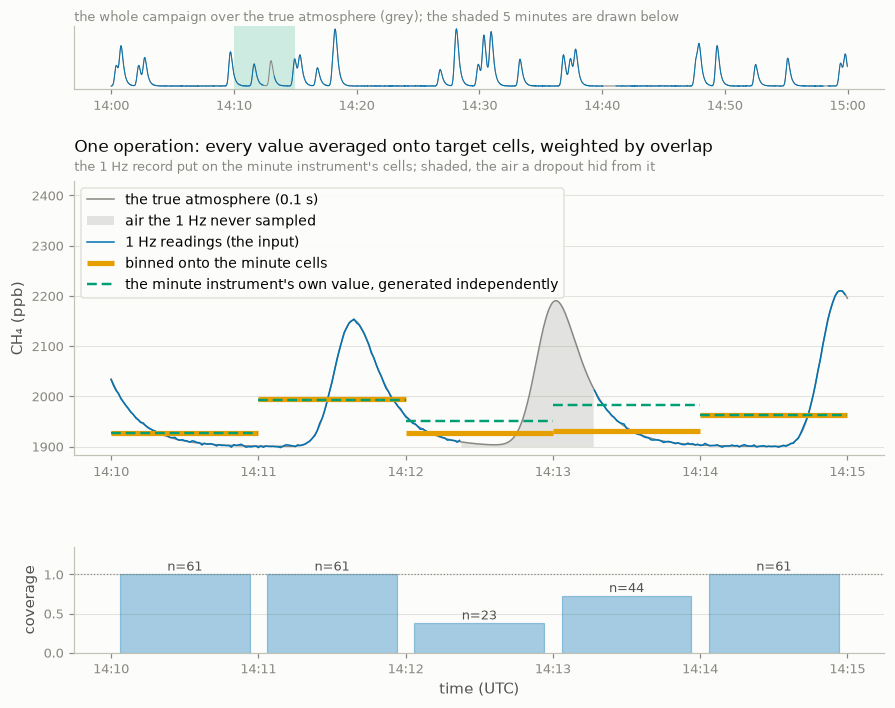

all 60 minutes      : median |TSARA - minute instrument|  0.298 ppb, largest  51.225 ppb
the 54 fully covered: median  0.258 ppb, largest   0.845 ppb
the worst minute has coverage 0.725 from 44 readings
the dropout drawn hid 6034 ppb·s of enhancement (the truth inside it peaks at 2190 ppb); the longest dropout, 63 s, hid 0 ppb·s


In [7]:
# Figure only: nothing in this cell computes a result.
# Behind the samples, the atmosphere the generator actually made, queried every
# 0.1 s. The notebook can draw the truth because it built it -- no real record
# allows that (04b) -- and it shows through exactly where the 1 Hz has nothing.
fast_start, fast_stop = bounds_of(fast)
truth_clock = pd.date_range(fast_start[0], fast_stop[-1], freq="100ms", inclusive="left")
truth = campaign.atmosphere.value("ch4", truth_clock)
background = campaign.atmosphere.background("ch4", truth_clock)

# Which of those instants the 1 Hz record sampled: inside a cell holding a value.
fast_cells = cells_of(fast)
t_ns = truth_clock.values.astype("datetime64[ns]").astype(np.int64)
row = np.searchsorted(fast_cells.start_ns, t_ns, side="right") - 1
sampled = np.zeros(t_ns.size, dtype=bool)
has_row = row >= 0
sampled[has_row] = (t_ns[has_row] < fast_cells.stop_ns[row[has_row]]) & np.isfinite(
    fast["ch4"].values[row[has_row]]
)

# The dropout to draw: NOT the longest, but the one that hid the most
# enhancement (ppb·s of truth above background inside it). The longest gap
# usually sits in flat air and shows nothing. A dropout is at least a second
# of unsampled air; a lone instant at a cell edge is not one.
step = np.diff(np.r_[0, (~sampled).astype(int), 0])
gap_start, gap_stop = np.flatnonzero(step == 1), np.flatnonzero(step == -1)
long_enough = (gap_stop - gap_start) >= 10
gap_start, gap_stop = gap_start[long_enough], gap_stop[long_enough]
missed = np.array([(truth[a:b] - background[a:b]).sum() * 0.1 for a, b in zip(gap_start, gap_stop)])
coverage = joined["coverage_ch4"].values
all_start, all_stop = bounds_of(joined)
if missed.size:
    g = int(np.argmax(missed))
    gap_middle = truth_clock[(gap_start[g] + gap_stop[g]) // 2]
    centre = int(np.searchsorted(all_start, np.datetime64(gap_middle), side="right") - 1)
else:  # no dropouts (DROPOUTS_PER_DAY = 0): centre on the largest disagreement instead
    centre = int(np.nanargmax(np.abs(joined["ch4"].values - joined["minute_ch4"].values)))
# Built from the cell EDGES, not from the labels. `time` is a cell MIDPOINT, so
# a window starting at a label would begin half a minute inside the first bar
# it draws, and the 1 Hz trace would be cut by that much at both ends -- the
# first orange bar would average readings the reader cannot see.
w0 = max(pd.Timestamp(all_start[centre]) - pd.Timedelta("2min"), pd.Timestamp(all_start[0]))
window = (w0, w0 + pd.Timedelta("5min"))
win = joined.sel(time=slice(*window))  # selects by midpoint, so whole cells
cell_start, cell_stop = bounds_of(win)
# The readings those cells were built from: the drawn cells' full extent, less
# one nanosecond so the first reading of the next cell is not drawn too.
fast_win = fast.sel(time=slice(cell_start[0], cell_stop[-1] - np.timedelta64(1, "ns")))
t_fast, v_fast = break_gaps(fast_win["time"].values, fast_win["ch4"].values)
in_win = (truth_clock >= cell_start[0]) & (truth_clock <= cell_stop[-1])

fig, (axo, ax, axc) = plt.subplots(
    3,
    1,
    figsize=(9.5, 7.4),
    gridspec_kw={"height_ratios": [0.6, 2.6, 1.0], "hspace": 0.62},
)
# An overview strip: the whole campaign, with the window below shaded, so the
# zoom is placed rather than floating. Grey shows through where the 1 Hz has nothing.
t_all, v_all = break_gaps(fast["time"].values, fast["ch4"].values)
axo.plot(truth_clock, truth, color=MUTED, lw=0.7)
axo.plot(t_all, v_all, color=C1, lw=0.6)
axo.axvspan(window[0], window[1], color=C3, alpha=0.18, lw=0)
axo.set_yticks([])
shaded_min = (window[1] - window[0]).seconds // 60
finish(
    axo,
    None,
    "the whole campaign over the true atmosphere (grey); "
    f"the shaded {shaded_min} minutes are drawn below",
    None,
    None,
    grid_axis=None,
)
hhmm(axo)
ax.sharex(axc)
ax.plot(
    truth_clock[in_win], truth[in_win], color=MUTED, lw=1.0, label="the true atmosphere (0.1 s)"
)
ax.fill_between(
    truth_clock[in_win],
    background[in_win],
    truth[in_win],
    where=~sampled[in_win],
    color=MUTED,
    alpha=0.22,
    lw=0,
    label="air the 1 Hz never sampled",
)
ax.plot(t_fast, v_fast, color=C1, lw=1.0, label="1 Hz readings (the input)")
ax.hlines(
    win["ch4"].values, cell_start, cell_stop, color=C2, lw=3.4, label="binned onto the minute cells"
)
ax.hlines(
    win["minute_ch4"].values,
    cell_start,
    cell_stop,
    color=C3,
    lw=1.6,
    ls=(0, (4, 2)),
    label="the minute instrument's own value, generated independently",
)
low = min(np.nanmin(v_fast), truth[in_win].min())
high = max(np.nanmax(v_fast), truth[in_win].max())
ax.set_ylim(low - 0.05 * (high - low), high + 0.70 * (high - low))  # room for the legend
finish(
    ax,
    "One operation: every value averaged onto target cells, weighted by overlap",
    "the 1 Hz record put on the minute instrument's cells; shaded, the air a dropout hid from it",
    "CH₄ (ppb)",
)
ax.legend(loc="upper left", frameon=True, facecolor=SURFACE, edgecolor=GRID, framealpha=0.95)
middle = cell_start + (cell_stop - cell_start) / 2
axc.bar(
    middle,
    win["coverage_ch4"].values,
    width=(cell_stop - cell_start) * 0.88,
    color=C1,
    alpha=0.35,
    edgecolor=C1,
    lw=0.8,
)
for x, c, n in zip(middle, win["coverage_ch4"].values, win["n_readings_ch4"].values):
    axc.text(x, c + 0.05, f"n={n}", ha="center", fontsize=8.2, color=INK2)
axc.axhline(1.0, color=MUTED, lw=0.8, ls=":")
axc.set_ylim(0, 1.35)
finish(axc, None, None, "coverage", "time (UTC)")
hhmm(axc)
# One tick per minute. The auto locator puts them every 40 s here, which %H:%M
# then renders as "14:56, 14:56, 14:57" -- the same label twice, at two
# different places on the axis.
axc.xaxis.set_major_locator(mdates.MinuteLocator())
plt.show()

difference = np.abs(joined["ch4"].values - joined["minute_ch4"].values)
full = coverage > FULLY_COVERED
worst = int(np.nanargmax(difference))
print(
    f"all {difference.size} minutes      : median |TSARA - minute instrument| "
    f"{np.nanmedian(difference):6.3f} ppb, "
    f"largest {np.nanmax(difference):7.3f} ppb"
)
print(
    f"the {int(full.sum())} fully covered: median {np.nanmedian(difference[full]):6.3f} ppb, "
    f"largest {np.nanmax(difference[full]):7.3f} ppb"
)
print(
    f"the worst minute has coverage {coverage[worst]:.3f} "
    f"from {joined['n_readings_ch4'].values[worst]} readings"
)
if missed.size:
    longest = int(np.argmax(gap_stop - gap_start))
    print(
        f"the dropout drawn hid {missed[g]:.0f} ppb·s of enhancement (the truth inside it peaks at "
        f"{truth[gap_start[g] : gap_stop[g]].max():.0f} ppb); the longest dropout, "
        f"{(gap_stop[longest] - gap_start[longest]) * 0.1:.0f} s, hid {missed[longest]:.0f} ppb·s"
    )

**What to read off the output.**

* **The ✔ lines are the operation.** The loop and TSARA agree to rounding on
  every minute: value, count and coverage.
* **The resample line is why the care is needed.** `pandas` gives every reading
  timestamped inside a minute equal weight, and a 1 s cell centred on a minute
  boundary is half inside each neighbour. On sharp plumes that edge reading is
  worth several ppb. TSARA weights it by the half that is inside.
* **In the figure, orange and green agree almost everywhere.** They come from
  different routes: green is the generator averaging the atmosphere over each
  minute, orange is TSARA averaging 1 Hz point samples of the same atmosphere
  over the same minute. That is an independent construction, not a
  self-consistency check.
* **Where they disagree badly, coverage says so first.** The worst minute is the
  one the dropout hit: a fraction of it was measured, and the surviving readings
  happened to catch part of a plume. Nothing in the *value* reveals that;
  `coverage` and `n_readings` do, which is why they travel automatically.
* **The grey line is the atmosphere the generator made**, drawn wherever it
  went, and the shading is the air the 1 Hz never sampled: here a whole plume,
  which the minute instrument recorded (green) and the surviving 1 Hz readings
  could not (orange). The dropout drawn is the one that hid the *most
  enhancement*, not the longest; the printed line says how much, and how little
  the longest one hid. No real record can show this, which is what notebook 04b
  says at its top.

**Try it.**

* `DROPOUTS_PER_DAY = 0.0`: no minute is short of data. The worst minute now
  has coverage 1.000, and its disagreement falls from about 50 ppb to about
  1 ppb, the level of the fully covered minutes.
* `MINUTE_LABEL = "end"`: the minute instrument's cells move a whole minute
  earlier. TSARA bins onto the cells the instrument declares, so the ✔ lines
  hold and the agreement is essentially unchanged.
* `FAST_NOISE_PPB = None` and `MINUTE_NOISE_PPB = None`: the typical fully
  covered minute now agrees to about 0.005 ppb, and the largest to about a tenth
  of a ppb, in a minute holding a plume. That remainder is not noise and not
  TSARA: 1 Hz point samples cannot see what the air did between them, and the
  minute instrument's mean can.
  Section 3 takes the terms apart one at a time.

---
## 3. How close is "almost everywhere"?

**The question.** Section 2's disagreement mixes three things: the binner's
arithmetic, the noise injected into both instruments, and the difference
between point samples and a true mean. Only the first is TSARA's. How big is
each?

**How it is answered.** Rebuild the campaign several times with one thing
switched on at a time, pooling several seeds per row so the statistics are
stable. If the binner is exact, the disagreement should fall to nothing when
there is nothing to disagree about, and to exactly the declared noise when
noise is all there is. Dropouts are removed, because a partly covered minute
is a fourth term.

The noise prediction is exact algebra, not a rule of thumb: a full minute
holds 59 whole 1 s readings and two halves, so the binned 1 Hz noise is
`σ_fast × √(59 + 2×0.5²) / 60`, combined in quadrature with the minute
instrument's own `σ_minute`.

**The minute instrument is silent by default here**, and that is what makes the
noise row worth reading. Its column is never binned — it already sits on the
target cells — so noise it carries passes straight through untouched. At the
0.4 ppb this campaign gives it elsewhere it would be four fifths of the row's
variance, and a binner that reduced the 1 Hz noise by √2 too much would still
land inside the tolerance. With it off, the row is the binner's arithmetic and
nothing else.

In [8]:
# ---- PARAMETERS (section 3) -------------------------------------------------
SEEDS = range(1, 13)  # campaigns pooled per row; each is one hour, 60 minutes
FAST_NOISE_PPB = 1.5
# The minute instrument's OWN noise, off by default here. Its column is never
# binned -- it is already on the target cells -- so any noise it carries passes
# straight through and inflates every row without telling us anything about the
# binner. Turn it back on (0.4) and watch check 2 lose most of its power.
MINUTE_NOISE_PPB = None
PLUME_SIGMA = "6s"  # the plumes' rise time; sharper plumes widen the gap in row 2
BACKGROUND_DIURNAL_PPB = 40.0  # a moving background, so a wrong weighting would show
BACKGROUND_DRIFT_PPB_PER_DAY = 0.0  # linear drift in the background (see "Try it")
MINUTE_SUBSAMPLES = 256  # points the GENERATOR averages inside each minute to build its mean

In [9]:
start_section("§3")


def pooled_gaps(**changes):
    """Rebuild the campaign for every seed with `changes`; return each full minute's gap."""
    gaps = []
    for seed in SEEDS:
        settings = dict(
            seed=seed,
            dropouts_per_day=0.0,  # a partly covered minute would be a fourth term
            minute_subsamples=MINUTE_SUBSAMPLES,
            # A background that moves: a constant averages to itself however
            # wrong the weights are, which would make the first row vacuous.
            background_diurnal_ppb=BACKGROUND_DIURNAL_PPB,
            background_drift_ppb_per_day=BACKGROUND_DRIFT_PPB_PER_DAY,
            fast_noise_ppb=FAST_NOISE_PPB,
            minute_noise_ppb=MINUTE_NOISE_PPB,
            plume_sigma=PLUME_SIGMA,
        )
        settings.update(changes)
        built = minute_campaign(**settings)
        got = bin_streams_onto_cells(
            dict(built.streams), cells_of(built.streams["minute"]), ["ch4", "minute_ch4"]
        )
        # Strictly full minutes only. The hour's last minute is missing the
        # half-reading at its end (the record stops there), so it describes
        # 59.5 s of the minute rather than 60: honest, but not like for like.
        full = got["coverage_ch4"].values > 0.999
        gaps.append((got["ch4"].values - got["minute_ch4"].values)[full])
    return np.concatenate(gaps)


def rms(values):
    """Root mean square."""
    return float(np.sqrt(np.mean(np.square(values))))


# The prediction when only noise differs: binned 1 Hz noise (59 whole readings
# and two halves, overlap-weighted) in quadrature with the minute's own noise.
weights = np.r_[0.5, np.ones(59), 0.5]
binned_fast = FAST_NOISE_PPB * np.sqrt(np.sum(weights**2)) / np.sum(weights)
# `None` is how the recipes spell "inject no noise", so it has to mean zero
# here rather than reaching np.hypot as a None.
predicted = float(np.hypot(binned_fast, MINUTE_NOISE_PPB or 0.0))
print(f"predicted spread from declared noise alone: {predicted:.4f} ppb")
print(
    f"  of which the binned 1 Hz noise is {binned_fast:.4f} ppb and the minute "
    f"instrument's own is {MINUTE_NOISE_PPB or 0.0:.4f} ppb\n"
)

ladder = {
    "no plumes, no noise": pooled_gaps(
        plumes_per_hour=0, fast_noise_ppb=None, minute_noise_ppb=None
    ),
    "plumes, no noise": pooled_gaps(fast_noise_ppb=None, minute_noise_ppb=None),
    "noise, no plumes": pooled_gaps(plumes_per_hour=0),
    "plumes and noise": pooled_gaps(),
}
print(f"{'campaign':20} {'minutes':>8} {'rms gap (ppb)':>14} {'÷ predicted':>12}")
for label, gaps in ladder.items():
    print(f"{label:20} {gaps.size:>8} {rms(gaps):>14.2e} {rms(gaps) / predicted:>11.3f}x")
print()

# CHECK 1: with nothing to disagree about, there should be nothing left.
row1 = rms(ladder["no plumes, no noise"])
check(
    "§3 with no plumes and no noise, TSARA and the generator agree to better than 1e-6 ppb",
    row1 < 1e-6,
    f"rms {row1:.1e} ppb",
)

# CHECK 2: with only noise differing, the measured spread is the declared noise.
# With the minute instrument silent this is the binner's own arithmetic: a
# binner reducing the noise by sqrt(2) too much would read 0.707x here.
n_noise = ladder["noise, no plumes"].size
ratio = rms(ladder["noise, no plumes"]) / predicted
check(
    "§3 the binner is transparent to noise: measured spread equals the declared sigmas",
    abs(ratio - 1) < sampling_tolerance(n_noise),
    f"{ratio:.3f}x, tolerance ±{sampling_tolerance(n_noise):.3f}",
)

# CHECK 3: independent terms add in quadrature: nothing double-counted or lost.
# How much this can see depends on the two terms being comparable, so the
# alternative it is being distinguished from is printed beside it: what the
# same rows would give if the terms were added LINEARLY instead.
plume_term, noise_term = rms(ladder["plumes, no noise"]), rms(ladder["noise, no plumes"])
expected = float(np.hypot(plume_term, noise_term))
combined = rms(ladder["plumes and noise"]) / expected
linear_would_read = (plume_term + noise_term) / expected
tolerance = sampling_tolerance(ladder["plumes and noise"].size)
print(
    f"a LINEAR sum of the same two terms would read {linear_would_read:.3f}x, "
    f"against a tolerance of {tolerance:.3f}"
)
check(
    "§3 plumes and noise add in quadrature",
    abs(combined - 1) < tolerance,
    f"{combined:.3f}x the quadrature sum",
)

predicted spread from declared noise alone: 0.1928 ppb
  of which the binned 1 Hz noise is 0.1928 ppb and the minute instrument's own is 0.0000 ppb



campaign              minutes  rms gap (ppb)  ÷ predicted
no plumes, no noise       708       1.44e-08       0.000x
plumes, no noise          708       1.81e-02       0.094x
noise, no plumes          708       1.92e-01       0.997x
plumes and noise          708       1.88e-01       0.976x

  ✔ §3 with no plumes and no noise, TSARA and the generator agree to better than 1e-6 ppb   [rms 1.4e-08 ppb]
  ✔ §3 the binner is transparent to noise: measured spread equals the declared sigmas   [0.997x, tolerance ±0.080]
a LINEAR sum of the same two terms would read 1.089x, against a tolerance of 0.080
  ✔ §3 plumes and noise add in quadrature   [0.975x the quadrature sum]


**Reading the ladder from the top.**

1. **The weighting is right, to a hundred-millionth of a ppb** — and that
   residual is not rounding, which is what an earlier version of this text
   claimed. It is the *curvature* of the background. The fast instrument
   reports point samples; averaging them over a minute is a trapezoid rule,
   and a trapezoid rule on a curve is wrong by about `spacing² × f″ / 12`.
   Three measurements say so:

   | change | row 1 |
   |---|---|
   | as run, 40 ppb daily cycle | 1.44 × 10⁻⁸ ppb |
   | `BACKGROUND_DIURNAL_PPB = 80.0` | 2.88 × 10⁻⁸ — exactly double, linear in the curvature |
   | `MINUTE_SUBSAMPLES = 4096` | 1.40 × 10⁻⁸ — unmoved, so it is not the generator's quadrature |
   | `BACKGROUND_DIURNAL_PPB = 0`, drift 60 ppb/day | 3.0 × 10⁻¹³ — a straight line has no curvature, and *this* is rounding |

   A hundred-millionth of a ppb on values near 1900 is eleven significant
   figures of agreement between two independent constructions. The point is
   not that it is small; it is that we can say exactly what it is.
2. **Sharp structure costs a few hundredths of a ppb, and it is the same
   mechanism.** Row 1 is the trapezoid error on a background that curves over
   hours; row 2 is the same error on plumes that curve over seconds. One
   second of sampling is the whole difference, no weighting can close it, and
   sharpening the plumes (`PLUME_SIGMA = "2s"`) widens it as you would expect.
3. **The binner is transparent to noise.** With only the fast instrument's
   declared noise, the measured spread is that noise reduced exactly as the
   algebra says, to within the sampling error of the pooled minutes. This row
   matters most: the whole uncertainty model assumes averaging does to an error
   what the arithmetic claims, and here that is tested against draws rather
   than against more algebra. A binner shrinking the noise by √2 too much
   would read 0.707x, and by √2 too little 1.414x, against a tolerance of 0.08.
4. **The terms add in quadrature** — and the line above the check says how much
   that can see. The two terms are not comparable here: the plume term is about
   a tenth of the noise term, so a *linear* sum of the same two numbers would
   read 1.09x against a tolerance of 0.08. The check distinguishes them, but
   only just, and it is worth knowing that rather than reading a ✔ as though it
   were decisive. `PLUME_SIGMA = "2s"` widens the gap to 1.14x; restoring the
   minute instrument's own noise narrows it to 1.04x, which no tolerance this
   loose can resolve.

**Two traps the previous version of this section fell into, kept because they
are instructive.** It reported the first row as "about 1 × 10⁻⁴ ppb" and the
second as "about 0.13 ppb". Both numbers were real, and neither was TSARA's.

* It counted a minute as full above 99 % coverage, which admits the hour's last
  minute: the record stops half a reading short of its end, so that minute
  describes 59.5 s rather than 60. When a plume sits there, that one minute
  disagrees by up to a couple of ppb, and twelve such minutes dominated the
  second row. This version requires 99.9 %.
* Its background also drifted, and the generator of the time measured linear
  drift from the first timestamp each instrument handed it: the 1 Hz analyzer's
  first reading, but the minute instrument's first *sub-sample*, half a
  sub-sample later. The two backgrounds differed by a constant
  `drift × (30 s ÷ subsamples)`.

Both surfaced while writing that version, because the check meant to confirm
the old explanation failed. The second was a generator defect, and it is gone:
the generator now builds one atmosphere, with drift measured from the campaign
start, and every instrument samples that same air (METHODS §8.1.1).

The earlier version of this notebook also had one more row. Before the
atmosphere existed, the two instruments could not measure *the same* methane;
the minute instrument measured a second species emitted at a ratio of 1 ± 1 %,
and that spread was the largest term in section 2's figure. It is not there to
remove any more.

**Try it.**

* `BACKGROUND_DRIFT_PPB_PER_DAY = 60.0`: the first row does not move from its
  1.4 × 10⁻⁸ ppb. The generator this section was first written against put
  about 8 × 10⁻⁵ ppb there, the drift-origin defect described above. Add
  `BACKGROUND_DIURNAL_PPB = 0.0` so drift is the only thing moving: the row is
  about 3 × 10⁻¹³ ppb, because the average of a straight line over a cell is its
  value at the midpoint, which is what both instruments report.
* `BACKGROUND_DIURNAL_PPB = 0.0`: a flat background. The first row falls to
  zero, and it proves nothing, because a constant averages to itself under any
  weights. That is why the default background moves.
* `BACKGROUND_DIURNAL_PPB = 80.0`: row 1 doubles, to 2.9 × 10⁻⁸ ppb. Nothing
  else moves. That is the curvature argument in one keystroke.
* `MINUTE_NOISE_PPB = 0.4`: the minute instrument speaks again, as it does in
  section 2. Every row grows, both checks still pass — and both get weaker.
  The noise row becomes four fifths untouched pass-through, and the linear
  alternative to check 3 falls from 1.09x to 1.04x, inside the tolerance. A
  parameter that makes every number bigger and every test worse is worth
  meeting once.
* `PLUME_SIGMA = "2s"`: sharper plumes. Row 2 nearly doubles (the support
  mismatch grows), and check 3's linear alternative widens to 1.14x.
* `FAST_NOISE_PPB = 5.0`: the prediction changes and the noise row still lands
  at 1.0x (0.997x). The row is a *ratio*, so the noise level cancels.
* `SEEDS = range(1, 3)`: two hours instead of twelve. The ratios wander more,
  the printed tolerance widens to match (±0.20), and the checks still hold.

---
## 4. What a target cell may be built from

**The question.** The operation is symmetric in the code: any readings, onto
any cells. Is it symmetric in use?

**It must not be, and one assumption decides where the line falls.** Every
joined value is the overlap-weighted mean of the readings touching its cell,
and each reading's value is that reading's mean over its *own* cell. So the
formula treats the part of a reading lying **outside** the target as if the air
there were the same as inside. That is the whole family of things a join can do
to a reading:

| the reading … | the join … | the assumption |
|---|---|---|
| sits wholly inside its target | **averages** it | none |
| straddles a boundary, no wider than the cell | **straddles** it across two rows | its air was uniform across the straddle |
| is wider than a cell it fills | **narrows** it: a whole-cell mean stands for a shorter interval | the same, over most of the reading |
| is at least twice as wide as a cell it fills | would **copy** it across rows | one reading pretending to be two rows' worth |

Two numbers say which, and how much (`METHODS.md` §11.2.4). Per (reading,
target) pair, the **width ratio** `r` = reading width ÷ target width: `r ≤ 1`
averaged or straddled, `1 < r < 2` narrowed, `r ≥ 2` copied. Per target cell, the
**borrowed share** `b`: the coverage-weighted fraction of each contributing
reading's own cell that lies outside the target -- how much of the value rests
on the assumption. Both come from the overlaps §1 already found, and neither
needs a tolerance: widths are integer nanoseconds, and the archive's worst
cadence jitter gives `r` = 1.024 against a line at 2.

**The rule** (`pair_width_ratios` and `COPY_RATIO` in `binning.py`): **a reading
at least twice as wide as a target cell it touches is refused**, unless
`finer_support="allow"` asks for the copies by name. The line is at 2 by
counting, not by taste: two disjoint cells of width W take 2W of distinct time,
so only a reading at least 2W wide can be the entire content of two rows.
Everything narrower is allowed, and every column records what happened: a label
(`tsara_support_transform`), the worst ratio, the column's borrowed share, the
distinct readings behind it, and a third companion beside the count and the
coverage, `borrowed_<name>`, with the share per cell. One warning per join
names the columns that were narrowed, copied, or hold more rows than readings.

Nothing else in the output would give a copy away. Each copied row would report
`coverage = 1.00`, because the target cell really is covered by readings, and
`n_readings = 1`, which is also what a legitimately sparse canister reports.

**How it is checked.** For a 60 s reading on target cells W seconds wide every
pair has `r` = 60/W, so the rule says refuse exactly when 60 ≥ 2W. The first
cell tries a list of widths, compares TSARA's verdict with that arithmetic, and
prints the label and the two numbers for every width that is built. The second
cell tries the two shapes the rule this one replaced got wrong. The third
measures what narrowing *costs*, against the atmosphere's true cell means.

In [10]:
# ---- PARAMETERS (section 4) -------------------------------------------------
TARGET_WIDTHS_S = [1, 10, 29, 30, 30.5, 45, 60, 61]  # target cell widths to try, seconds
TARGET_OFFSET_S = 0.0  # shift the target cells against the minute boundaries
FINER_SUPPORT = "refuse"  # at the copy line: "refuse" (the default) or "allow"
SEED = 7

In [11]:
start_section("§4")
campaign4 = minute_campaign(seed=SEED)  # kept whole: its atmosphere is queried under the figures
minute = campaign4.streams["minute"]
reading_cells = cells_of(minute)
reading_s = float(np.median(reading_cells.width_ns)) / SECOND  # 60 s


def record(column):
    """Return the four numbers a join writes beside every column (METHODS §11.2.4)."""
    a = column.attrs
    return (
        a["tsara_support_transform"],
        a["tsara_width_ratio_max"],
        a["tsara_borrowed_share"],
        a["tsara_n_readings"],
    )


# `Quietly` (the toolkit) collects the binner's one-warning-per-join so a table
# of many joins can report them in one line instead of under every row.
print(
    f"{'target width':>13} {'TSARA':>9} {'rule: 60 >= 2W':>15} {'label':>11} {'ratio':>6} "
    f"{'borrowed':>9} {'rows':>6} {'readings':>9}"
)
verdicts_agree = True
with Quietly() as quiet:
    for width_s in TARGET_WIDTHS_S:
        # Target cells tiling the hour, starting TARGET_OFFSET_S after a minute
        # boundary and beginning one cell early so the first minute is fully tiled.
        first = (
            int(reading_cells.start_ns[0])
            + round((TARGET_OFFSET_S % width_s) * SECOND)
            - round(width_s * SECOND)
        )
        count = int(np.ceil((reading_cells.stop_ns[-1] - first) / (width_s * SECOND))) + 1
        target = uniform_cells(first, width_s, count)
        rule_refuses = reading_s >= 2 * width_s
        try:
            out = bin_streams_onto_cells(
                {"minute": minute}, target, ["minute_ch4"], finer_support=FINER_SUPPORT
            )
            tsara_refuses = False
            label, ratio, borrowed, readings = record(out["minute_ch4"])
            rows = int(np.isfinite(out["minute_ch4"].values).sum())
            detail = f"{label:>11} {ratio:>6.3f} {borrowed:>9.3f} {rows:>6} {readings:>9}"
        except TsaraAlignError:
            tsara_refuses, detail = True, f"{'-':>11} {'-':>6} {'-':>9} {'-':>6} {'-':>9}"
        verdicts_agree &= tsara_refuses == (rule_refuses and FINER_SUPPORT == "refuse")
        print(
            f"{width_s:>11g} s {'refused' if tsara_refuses else 'built':>9} "
            f"{'refuse' if rule_refuses else 'allow':>15} {detail}"
        )
print()
check(
    "§4 TSARA refuses exactly the widths at which a 60 s reading is twice as wide as a cell",
    verdicts_agree,
    f"finer_support={FINER_SUPPORT!r}",
)
print(
    f"\n{len(quiet.messages)} warning(s) were issued for the widths built above; "
    "the first reads:\n  "
    + (quiet.messages[0].split(". A reading wider")[0] + "." if quiet.messages else "(none)")
)

# What the refusal says, at the width that shows the problem most plainly.
one_second = uniform_cells(int(reading_cells.start_ns[0]), 1.0, 3600)
try:
    with Quietly() as quiet:
        copied = bin_streams_onto_cells(
            {"minute": minute}, one_second, ["minute_ch4"], finer_support=FINER_SUPPORT
        )
    label, ratio, borrowed, readings = record(copied["minute_ch4"])
    n_rows = int(np.isfinite(copied["minute_ch4"].values).sum())
    print(
        f"\nTSARA, asked for 1 s cells with finer_support={FINER_SUPPORT!r}: built and "
        f"labelled {label!r}, ratio {ratio:g}, {n_rows} rows from {readings} readings, "
        f"borrowed share {borrowed:.3f}; and it warned:\n  {quiet.messages[0].split('. Every')[0]}."
    )
except TsaraAlignError as refused:
    print(f"\nTSARA, asked for 1 s cells:\n  {refused}")

 target width     TSARA  rule: 60 >= 2W       label  ratio  borrowed   rows  readings
          1 s   refused          refuse           -      -         -      -         -
         10 s   refused          refuse           -      -         -      -         -
         29 s   refused          refuse           -      -         -      -         -
         30 s   refused          refuse           -      -         -      -         -
       30.5 s     built           allow    narrowed  1.967     0.579    119        60
         45 s     built           allow    narrowed  1.333     0.417     80        60
         60 s     built           allow    averaged  1.000     0.000     60        60
         61 s     built           allow   straddled  0.984     0.333     60        60

  ✔ §4 TSARA refuses exactly the widths at which a 60 s reading is twice as wide as a cell   [finer_support='refuse']

2 warning(s) were issued for the widths built above; the first reads:
  1 column(s) of this join rest on a

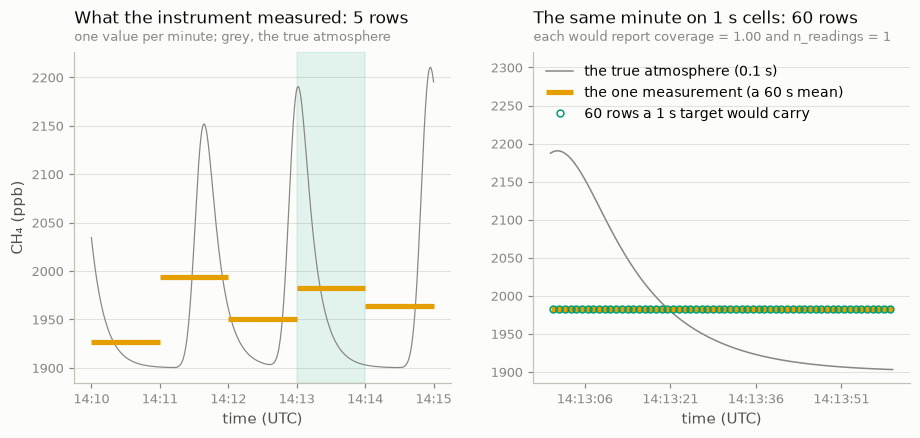

In [12]:
# Figure only. The "upsampled" rows are built BY HAND with np.repeat, to show
# what TSARA just refused to produce; under them, the atmosphere the generator
# made, so the copies can be seen against the air they claim to describe.
window = (
    pd.Timestamp(minute["time_bnds"].values[10, 0]),
    pd.Timestamp(minute["time_bnds"].values[15, 0]),
)
win = minute.sel(time=slice(*window))
cell_start, cell_stop = bounds_of(win)
copies = np.repeat(win["minute_ch4"].values, 60)
copy_clock = pd.date_range(window[0] + pd.Timedelta("0.5s"), periods=copies.size, freq="1s")
zoom = (window[0] + pd.Timedelta("3min"), window[0] + pd.Timedelta("4min"))
in_zoom = (copy_clock >= zoom[0]) & (copy_clock < zoom[1])
zoom_win = minute.sel(time=slice(*zoom))
zoom_start, zoom_stop = bounds_of(zoom_win)
truth_clock = pd.date_range(window[0], window[1], freq="100ms")
truth = campaign4.atmosphere.value("ch4", truth_clock)
in_z = (truth_clock >= zoom[0]) & (truth_clock <= zoom[1])

fig, (axl, axr) = plt.subplots(1, 2, figsize=(9.8, 3.9), gridspec_kw={"wspace": 0.22})
axl.plot(truth_clock, truth, color=MUTED, lw=0.8)
axl.hlines(win["minute_ch4"].values, cell_start, cell_stop, color=C2, lw=3.4)
axl.axvspan(zoom[0], zoom[1], color=C3, alpha=0.10)
finish(
    axl,
    f"What the instrument measured: {win.sizes['time']} rows",
    "one value per minute; grey, the true atmosphere",
    "CH₄ (ppb)",
    "time (UTC)",
)
hhmm(axl)
axr.plot(truth_clock[in_z], truth[in_z], color=MUTED, lw=1.0, label="the true atmosphere (0.1 s)")
axr.hlines(
    zoom_win["minute_ch4"].values,
    zoom_start,
    zoom_stop,
    color=C2,
    lw=3.4,
    label="the one measurement (a 60 s mean)",
)
axr.plot(
    copy_clock[in_zoom],
    copies[in_zoom],
    "o",
    color=C3,
    ms=4.5,
    mfc="none",
    mew=1.0,
    label=f"{int(in_zoom.sum())} rows a 1 s target would carry",
)
lo = min(float(truth[in_z].min()), float(zoom_win["minute_ch4"].values[0]))
hi = max(float(truth[in_z].max()), float(zoom_win["minute_ch4"].values[0]))
span = max(hi - lo, 12.0)
axr.set_ylim(lo - 0.06 * span, hi + 0.45 * span)  # room for the legend
finish(
    axr,
    f"The same minute on 1 s cells: {int(in_zoom.sum())} rows",
    "each would report coverage = 1.00 and n_readings = 1",
    None,
    "time (UTC)",
    legend=True,
    loc="upper left",
)
hhmm(axr, "%H:%M:%S")
axr.xaxis.set_major_locator(mdates.SecondLocator(interval=15))
plt.show()

**What to read off the output.** The line falls exactly at 30 s: at 30 s each
reading is twice as wide as a cell and is refused; at 30.5 s it is a hair under,
and the join is built -- labelled `narrowed`, ratio 1.967, more than half of
every value borrowed from outside its cell. At 45 s the ratio is 1.333 and the
share 0.41; at 61 s each reading is a little *narrower* than the cell, so the
label is `straddled`, and rows and readings agree. Between 30 and 60 s more rows
hold data than there are readings, because each reading lands partly in two
rows. None of that is hidden: the numbers are beside every column, and the
warning names the columns.

In the figure's right panel the grey line is the air itself, changing by
hundreds of ppb across the minute, while all sixty copies sit at the minute's
mean. The copies are not wrong about the minute; they are wrong about every
second of it, and each would report a coverage and a count saying it is fine.

**The escape route** for a case that is genuinely wanted, such as a smooth wind
or a GPS track on a 1 Hz clock, already exists: interpolation, under a gap
guard, which refuses any variable declaring `role: gas`. That is section 11. A
copy that is genuinely wanted -- a slow value held on a fast grid for display,
say -- is made by name with `finer_support="allow"`, labelled `copied`, and
warned about; nothing about it is quiet.

**Try it.**

* `TARGET_WIDTHS_S = [29.9, 30.0, 30.1]`: refused, refused, built. The rule has
  no tolerance to tune.
* `TARGET_OFFSET_S = 13.0`: the same verdicts; the ratio is a property of the
  widths, not of where the boundaries fall. The borrowed shares move, and the
  60 s row is the one to watch: its label turns from `averaged` to `straddled` with
  a share of 0.339, which is `2f(1 - f)` for `f` = 13/60 -- the closed form of a
  same-width blend, with 61 rows from 60 readings.
* `FINER_SUPPORT = "allow"`: nothing is refused. The 1 s request is built with
  3600 rows from 60 readings, labelled `copied`, ratio 60, and the warning says
  so twice, once for the instrument and once for the column.

In [13]:
# The two shapes the earlier rule got wrong (METHODS §11.2.1). That rule summed
# the time a reading shared with ALL target cells, which assumed the targets do
# not overlap: it let one wide reading onto one narrow cell and refused sliding
# windows. A ratio per pair has neither hole.
fast = campaign4.streams["fast"]
start = int(reading_cells.start_ns[0])


def spaced_cells(start_ns, width_s, count, step_s):
    """Return `count` cells `width_s` wide, starts `step_s` apart: overlapping when step < width."""
    starts = start_ns + np.arange(count, dtype=np.int64) * round(step_s * SECOND)
    return CellBounds(start_ns=starts, stop_ns=starts + round(width_s * SECOND))


# The fourth shape: two 0.7 s cells, each lying inside a different 1 s reading,
# placed at the first two consecutive readings that both hold a value.
fast_cells = cells_of(fast)
first = int(
    np.flatnonzero(np.isfinite(fast["ch4"].values[:-1]) & np.isfinite(fast["ch4"].values[1:]))[0]
)
two_cells = CellBounds(
    start_ns=fast_cells.start_ns[first : first + 2],
    stop_ns=fast_cells.start_ns[first : first + 2] + round(0.7 * SECOND),
)

shapes = [
    (
        "60 s means on one 15 s cell every 530 s (a canister's cells)",
        {"minute": minute},
        "minute_ch4",
        spaced_cells(start + 50 * SECOND, 15.0, 6, 530.0),
    ),
    (
        "60 s means on 300 s windows sliding every 30 s",
        {"minute": minute},
        "minute_ch4",
        spaced_cells(start, 300.0, 100, 30.0),
    ),
    (
        "1 s points on 60 s windows sliding every 1 s",
        {"fast": fast},
        "ch4",
        spaced_cells(start, 60.0, 600, 1.0),
    ),
    ("1 s points on two disjoint 0.7 s cells (one reading each)", {"fast": fast}, "ch4", two_cells),
]
print(
    f"{'shape':62} {'TSARA':>8} {'label':>9} {'ratio':>6} {'borrowed':>9} "
    f"{'rows':>5} {'readings':>9}"
)
verdicts, warned, built = [], [], {}
with Quietly() as quiet:
    for name, streams, variable, target in shapes:
        before = len(quiet.messages)
        try:
            out = bin_streams_onto_cells(streams, target, [variable])
            label, ratio, borrowed, readings = record(out[variable])
            rows = int(np.isfinite(out[variable].values).sum())
            verdicts.append("built")
            built[name] = out
            print(
                f"{name:62} {'built':>8} {label:>9} {ratio:>6.3f} {borrowed:>9.3f} "
                f"{rows:>5} {readings:>9}"
            )
        except TsaraAlignError:
            verdicts.append("refused")
            print(f"{name:62} {'refused':>8}")
        warned.append(len(quiet.messages) > before)  # did THIS join warn?
check(
    "§4 a 60 s mean is refused on a 15 s cell (four times as wide) and built on sliding windows",
    verdicts[:3] == ["refused", "built", "built"],
)
check(
    "§4 overlapping windows share their readings by construction and are not warned about",
    not any(warned[1:3]),
)

# The last shape is built, and every number a reader looks at first is clean:
# each row's value IS its reading (0.7 of one reading, divided by 0.7),
# coverage 1.00, n_readings 1 -- what an honestly sparse instrument reports.
# Only the record and the warning say what happened.
narrowed = built.get(shapes[3][0])
looks_clean = narrowed is not None and bool(
    np.allclose(narrowed["ch4"].values, fast["ch4"].values[first : first + 2], rtol=1e-12, atol=0)
    and np.all(narrowed["coverage_ch4"].values == 1.0)
    and np.all(narrowed["n_readings_ch4"].values == 1)
)
check(
    "§4 a narrowed join can look clean (values equal to the readings, coverage 1.00, "
    "n_readings 1); only the record and the warning say otherwise",
    looks_clean and narrowed["ch4"].attrs["tsara_support_transform"] == "narrowed" and warned[3],
)

shape                                                             TSARA     label  ratio  borrowed  rows  readings
60 s means on one 15 s cell every 530 s (a canister's cells)    refused
60 s means on 300 s windows sliding every 30 s                    built straddled  0.200     0.050   100        55
1 s points on 60 s windows sliding every 1 s                      built straddled  0.017     0.008   600       660
1 s points on two disjoint 0.7 s cells (one reading each)         built  narrowed  1.429     0.300     2         2
  ✔ §4 a 60 s mean is refused on a 15 s cell (four times as wide) and built on sliding windows
  ✔ §4 overlapping windows share their readings by construction and are not warned about
  ✔ §4 a narrowed join can look clean (values equal to the readings, coverage 1.00, n_readings 1); only the record and the warning say otherwise


**What to read off the output.** One 15 s cell inside a 60 s reading is refused:
the reading is four times as wide as it, three quarters of the value would be
borrowed, and the rule that summed shared time let it through because one
narrow cell never adds up to two cells' worth. The sliding windows are built,
and rows outnumber readings by design -- every reading sits in several windows
because that is what was asked -- so the warning that names shared columns is
not issued for overlapping targets. The borrowed share still records the little
that the window edges borrow.

The last row is the one to remember. Two 0.7 s cells, one inside each 1 s
reading: built, and every number a reader would look at first is clean -- the
values *are* the readings, coverage 1.00, `n_readings` 1 -- exactly what an
honest sparse instrument reports. Only the record says what happened:
`narrowed`, ratio 1.43, three tenths of each value resting on air the row does
not cover, and one warning. That is why the record exists: nothing else in the
output would give a narrowed join away, any more than it would a copy.

In [14]:
# ---- PARAMETERS (section 4, the cost) -----------------------------------------
NARROW_TO_S = 15.0  # stand each 60 s mean on cells this wide
COST_PLUMES_PER_HOUR = (
    26.0  # 0 removes the plumes: the cost collapses to the background's curvature
)
COST_DIURNAL_PPB = 20.0  # a daily breathing of the background, so the air is never exactly flat

In [15]:
# What narrowing costs, against the atmosphere's true cell means. Noise and
# dropouts are off, so the only error is the support; finer_support="allow"
# makes the join the rule refuses.
truthful = minute_campaign(
    seed=SEED,
    fast_noise_ppb=None,
    minute_noise_ppb=None,
    dropouts_per_day=0,
    plumes_per_hour=COST_PLUMES_PER_HOUR,
    background_diurnal_ppb=COST_DIURNAL_PPB,
)
minute_t, fast_t = truthful.streams["minute"], truthful.streams["fast"]
minute_cells = cells_of(minute_t)
per_cell = int(round(60 / NARROW_TO_S))
narrow = uniform_cells(
    int(minute_cells.start_ns[0]), NARROW_TO_S, per_cell * minute_t.sizes["time"]
)
with Quietly():
    narrowed = bin_streams_onto_cells(
        {"minute": minute_t}, narrow, ["minute_ch4"], finer_support="allow"
    )
narrowed = narrowed["minute_ch4"].values
truth = truthful.atmosphere.mean_over("ch4", narrow, subsamples=64)
error = narrowed - truth

# Two candidate prices for that error. P1 needs only the 60 s stream: the spread
# of each minute's mean against its neighbours'. P2 needs the FASTER stream: the
# spread of the 1 s samples inside each minute.
means = minute_t["minute_ch4"].values
padded = np.pad(means, 1, mode="edge")
p1 = np.array([np.std(padded[k : k + 3], ddof=1) for k in range(means.size)])
inside = reference_bin(cells_of(fast_t), fast_t["ch4"].values, minute_cells)["value"]
inside_sq = reference_bin(cells_of(fast_t), fast_t["ch4"].values ** 2, minute_cells)["value"]
p2 = np.sqrt(np.maximum(inside_sq - inside**2, 0.0))
p1_cells, p2_cells = np.repeat(p1, per_cell), np.repeat(p2, per_cell)

ok = np.isfinite(error) & (p1_cells > 0) & (p2_cells > 0)
if not ok.any():
    raise SystemExit(
        "nothing varies inside any minute: no error to price, and no spread to price it with"
    )
rms = float(np.sqrt(np.mean(error[ok] ** 2)))
price = {
    "P1": float(np.sqrt(np.mean((error[ok] / p1_cells[ok]) ** 2))),
    "P2": float(np.sqrt(np.mean((error[ok] / p2_cells[ok]) ** 2))),
}
print(
    f"60 s means stood on {NARROW_TO_S:g} s cells, against the true {NARROW_TO_S:g} s means: "
    f"RMS error {rms:.2f} ppb, worst {np.abs(error[ok]).max():.1f} ppb "
    f"(the true means themselves spread by {np.std(truth[ok]):.1f} ppb)"
)
print(f"  RMS(error / P1, the stream's own neighbours):          {price['P1']:.2f}")
print(
    f"  RMS(error / P2, the faster stream's within-cell spread): {price['P2']:.2f}   "
    "(1.00 = a calibrated 1-sigma; below 1 = a conservative one)"
)
# A theorem, not a fit: a part-mean's departure from the whole-cell mean is the
# between-part spread, and the partition of variance says that never exceeds the
# within-cell spread. The 1.05 allows the 1 s sampling of the spread and the
# 64-point quadrature of the truth.
check(
    "§4 the faster stream's within-cell spread bounds the narrowing error "
    "(between-part spread ≤ within-cell spread)",
    price["P2"] <= 1.05,
    f"RMS(error / spread) {price['P2']:.2f}",
)

60 s means stood on 15 s cells, against the true 15 s means: RMS error 76.54 ppb, worst 338.2 ppb (the true means themselves spread by 118.1 ppb)
  RMS(error / P1, the stream's own neighbours):          1.19
  RMS(error / P2, the faster stream's within-cell spread): 0.91   (1.00 = a calibrated 1-sigma; below 1 = a conservative one)
  ✔ §4 the faster stream's within-cell spread bounds the narrowing error (between-part spread ≤ within-cell spread)   [RMS(error / spread) 0.91]


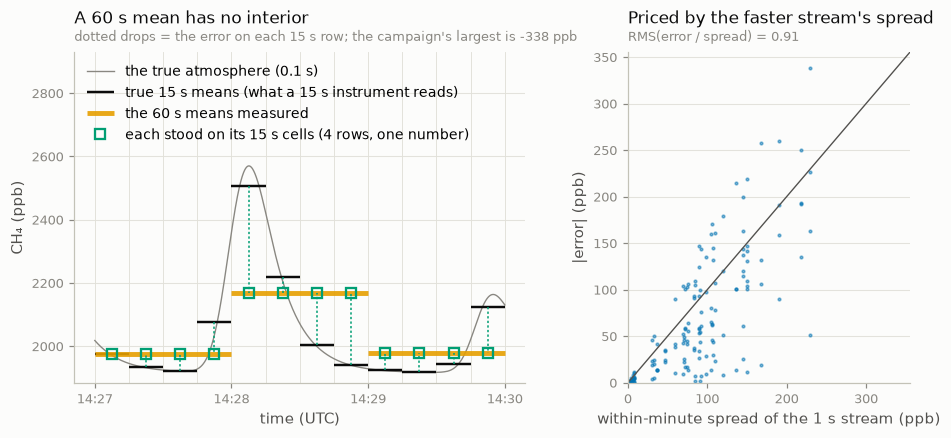

In [16]:
# Figure only: the narrowing, and what prices it. Three minutes around the
# largest error. The narrowed series IS the 60 s mean repeated on its cells, so
# drawn as a line it would lie exactly under the orange one and show nothing:
# it is drawn as one open marker per cell, with a dotted drop to that cell's
# true mean -- the per-row error, made visible.
k0 = int(np.argmax(np.where(ok, np.abs(error), 0)))  # the cell with the largest error
m0 = k0 // per_cell
lo, hi = max(m0 - 1, 0), min(m0 + 2, minute_t.sizes["time"])
sel = slice(lo * per_cell, hi * per_cell)
n_start, n_stop = (
    narrow.start_ns[sel].astype("datetime64[ns]"),
    narrow.stop_ns[sel].astype("datetime64[ns]"),
)
m_start, m_stop = (
    minute_cells.start_ns[lo:hi].astype("datetime64[ns]"),
    minute_cells.stop_ns[lo:hi].astype("datetime64[ns]"),
)
n_mid = n_start + (n_stop - n_start) / 2
fine_clock = pd.date_range(m_start[0], m_stop[-1], freq="100ms")
fine_truth = truthful.atmosphere.value("ch4", fine_clock)

fig, (axl, axr) = plt.subplots(
    1, 2, figsize=(9.8, 3.9), gridspec_kw={"wspace": 0.28, "width_ratios": [1.6, 1]}
)
for edge in np.r_[n_start, n_stop[-1:]]:  # the 15 s cells exist visually
    axl.axvline(edge, color=GRID, lw=0.6)
axl.plot(fine_clock, fine_truth, color=MUTED, lw=0.9, label="the true atmosphere (0.1 s)")
axl.hlines(
    truth[sel],
    n_start,
    n_stop,
    color=INK,
    lw=1.6,
    label=f"true {NARROW_TO_S:g} s means (what a {NARROW_TO_S:g} s instrument reads)",
)
axl.hlines(
    means[lo:hi], m_start, m_stop, color=C2, lw=3.2, alpha=0.9, label="the 60 s means measured"
)
axl.plot(
    n_mid,
    narrowed[sel],
    "s",
    color=C3,
    ms=7,
    mfc="none",
    mew=1.5,
    label=f"each stood on its {NARROW_TO_S:g} s cells ({per_cell} rows, one number)",
)
axl.vlines(n_mid, truth[sel], narrowed[sel], color=C3, lw=1.0, ls=(0, (1.5, 1.5)))
lo_y, hi_y = float(fine_truth.min()), float(fine_truth.max())
axl.set_ylim(lo_y - 0.05 * (hi_y - lo_y), hi_y + 0.55 * (hi_y - lo_y))  # room for the legend
finish(
    axl,
    "A 60 s mean has no interior",
    f"dotted drops = the error on each {NARROW_TO_S:g} s row; "
    f"the campaign's largest is {error[k0]:+.0f} ppb",
    "CH₄ (ppb)",
    "time (UTC)",
    legend=True,
    loc="upper left",
)
hhmm(axl)
axl.xaxis.set_major_locator(mdates.MinuteLocator())  # one tick per minute; finer repeats %H:%M
axr.plot(p2_cells[ok], np.abs(error[ok]), ".", color=C1, ms=3.5, alpha=0.5)
lim = max(float(np.abs(error[ok]).max()), float(p2_cells[ok].max())) * 1.05
axr.plot([0, lim], [0, lim], color=INK2, lw=0.9)
axr.set_xlim(0, lim)
axr.set_ylim(0, lim)
finish(
    axr,
    "Priced by the faster stream's spread",
    f"RMS(error / spread) = {price['P2']:.2f}",
    "|error| (ppb)",
    "within-minute spread of the 1 s stream (ppb)",
)
plt.show()

**What to read off the output.** Standing a 60 s mean on 15 s cells is wrong by
some eighty ppb RMS with these plumes -- a quarter of a typical plume here, and
more than three hundred at the worst cell -- because a mean has no interior: the
value is right for the minute and says nothing about its quarters. In the
figure, the open squares are the four rows each minute would carry, all at one
number; the black bars are what a 15 s instrument would have read in each; the
dotted drops are the error on every row, against the grey air itself. The stream's
own neighbours are not a price for that error (1.19 here, and it swings either
way at other parameters). The within-minute spread of the *faster* stream is: it
bounds the error by the partition of variance, and for quarter-minute cells the
bound is tight, about 0.9. So the only honest price for narrowing needs a faster
stream -- and with a faster stream the honest operation is to bin *it*, not to
narrow the slow one. That is why TSARA records how much was borrowed and never
converts it into an uncertainty (`METHODS.md` §11.2.4): when the price exists
the operation is unnecessary, and when the operation is the only option the
price does not exist.

**Try it.**

* `COST_PLUMES_PER_HOUR = 0`: no plumes, and the error collapses to a hundredth
  of a ppb -- the curvature of the diurnal background across a minute. The faster
  stream's spread still bounds it tightly (about 0.97); the neighbours read
  about 0.3, which is not a price either.
* `NARROW_TO_S = 30.0`: half a minute instead of a quarter. The error falls (to
  about 60 ppb RMS) and the bound loosens (to about 0.73): two halves depart from
  their minute's mean by less than four quarters do, while the spread inside the
  minute is the same. Tight for quarters, conservative for halves.
* `COST_DIURNAL_PPB = 0` with `COST_PLUMES_PER_HOUR = 0`: perfectly flat air, so
  nothing varies inside any minute and there is nothing to price -- the cell
  stops and says so instead of dividing by zero, and the figure cell after it
  does not run.

---
## 5. The uncertainty that travels with the value

**The question.** A binned value is a weighted mean. What is its uncertainty,
and does it come out right when the budget was declared in a manifest, written
into a file, and read back by ingestion, which is the path real data takes?

**What TSARA does** (`_bin_scalar` in `binning.py`, arithmetic in
`src/tsara/core/propagation.py`). Every variable carries up to two uncertainty
components, and they behave in opposite ways under averaging:

* **random**: independent from reading to reading, so averaging shrinks it,
  by √N for N equal readings;
* **systematic**: shared by every reading (a calibration offset, say), so
  averaging does not shrink it at all. The uncertainty of the mean is the
  weighted mean of the uncertainties.

Both are propagated through **the same overlap weights that formed the value**.
It can look as though inverse-variance weights would be better, since they give
the smallest uncertainty. They would describe a *different* mean from the one
reported, so they must not be used.

**How it is checked.** A record with a declared budget is written to CSV with
its manifest, ingested, and binned onto cells of several widths. Every cell's
two sigmas are compared with the textbook formulas evaluated by `reference_bin`:
random `√(Σ w²σ²) / Σ w`, systematic `Σ wσ / Σ w`.

In [17]:
# ---- PARAMETERS (section 5) -------------------------------------------------
RANDOM_PPB = 2.0  # declared random 1-sigma of each 1 s reading
SYSTEMATIC_RELATIVE = 0.01  # declared systematic 1-sigma as a fraction of the reading (0: none)
CELL_WIDTHS_S = [1, 10, 60, 600, 2400]  # widths to bin the 40-minute record onto
SEED = 5

# For the figure: one reading's sigma, and the decorrelation timescale of the
# third, correlated curve.
SIGMA_PPB = 2.0
TAU_S = 20.0

In [18]:
start_section("§5")

# 1. Manufacture a flat record whose errors have the declared budget.
budget = budget_campaign(seed=SEED, random_ppb=RANDOM_PPB, systematic_relative=SYSTEMATIC_RELATIVE)
# 2. Write it as raw CSV plus a manifest declaring that budget, as an archive would be.
manifest_path = export_raw(budget, WORK / "budget")
text = manifest_path.read_text()
print("the part of the written manifest that declares the budget:")
excerpt = text[text.index("variables:") :].splitlines()
print(
    "\n".join(
        "    " + line
        for line in excerpt[
            : next((i for i, line in enumerate(excerpt) if "decorrelation" in line), 20)
        ]
    )
)
# 3. Read it back exactly as real data is read.
analyzer = ingest_campaign(load_manifest(manifest_path))["budget_analyzer"]
print("\ningested columns:", sorted(map(str, analyzer.data_vars)))
print(
    "provenance:",
    {k: v for k, v in analyzer["ch4"].attrs.items() if k.startswith("uncertainty_provenance")},
)

reading_cells = cells_of(analyzer)
per_reading_random = analyzer[sigma_rand_name("ch4")].values
has_systematic = sigma_sys_name("ch4") in analyzer
per_reading_systematic = analyzer[sigma_sys_name("ch4")].values if has_systematic else None
record_s = (reading_cells.stop_ns[-1] - reading_cells.start_ns[0]) / SECOND

print(f"\n{'cell width':>12} {'readings':>9} {'random':>10} {'RANDOM/√N':>10} {'systematic':>11}")
random_ok = systematic_ok = True
for width_s in CELL_WIDTHS_S:
    target = uniform_cells(int(reading_cells.start_ns[0]), width_s, int(record_s // width_s))
    cell = bin_streams_onto_cells({"budget_analyzer": analyzer}, target, ["ch4"])
    reference = reference_bin(
        reading_cells,
        analyzer["ch4"].values,
        target,
        sigma_rand=per_reading_random,
        sigma_sys=per_reading_systematic,
    )
    random_ok &= np.allclose(
        cell[sigma_rand_name("ch4")].values, reference["sigma_rand"], rtol=1e-9, atol=0
    )
    n = float(np.median(cell["n_readings_ch4"].values))
    systematic = "-"
    if has_systematic:
        systematic_ok &= np.allclose(
            cell[sigma_sys_name("ch4")].values, reference["sigma_sys"], rtol=1e-9, atol=0
        )
        systematic = f"{np.median(cell[sigma_sys_name('ch4')].values):.5f}"
    print(
        f"{width_s:>10g} s {n:>9.0f} {np.median(cell[sigma_rand_name('ch4')].values):>10.5f} "
        f"{RANDOM_PPB / np.sqrt(n):>10.5f} {systematic:>11}"
    )
print()
check("§5 every cell's random sigma equals sqrt(sum w²σ²)/sum w, at every width", random_ok)
if has_systematic:
    check(
        "§5 every cell's systematic sigma equals sum wσ/sum w: no reduction with N", systematic_ok
    )

the part of the written manifest that declares the budget:
    variables:
          ch4:
            column: ch4
            field: null
            role: gas
            units: ppb
            convert: null
            circular: false
            uncertainty:
              random:
                mode: declared
                absolute: 2.0
                relative: 0.0
                at_width: null
              systematic:
                mode: declared
                absolute: 0.0
                relative: 0.01
                at_width: null

ingested columns: ['ch4', 'sigma_rand_ch4', 'sigma_sys_ch4']
provenance: {'uncertainty_provenance': 'declared', 'uncertainty_provenance_random': 'declared', 'uncertainty_provenance_systematic': 'declared'}

  cell width  readings     random  RANDOM/√N  systematic


         1 s         1    2.00000    2.00000    19.05501
        10 s        10    0.63246    0.63246    19.05499
        60 s        60    0.25820    0.25820    19.05483
       600 s       600    0.08165    0.08165    19.05432
      2400 s      2400    0.04082    0.04082    19.05456

  ✔ §5 every cell's random sigma equals sqrt(sum w²σ²)/sum w, at every width
  ✔ §5 every cell's systematic sigma equals sum wσ/sum w: no reduction with N


  ✔ §5 independent readings: the sigma of the mean is σ/√N at every N
  ✔ §5 systematic: the sigma of the mean is σ at every N
  ✔ §5 correlated (AR(1)) readings: TSARA's default form equals the double sum written out


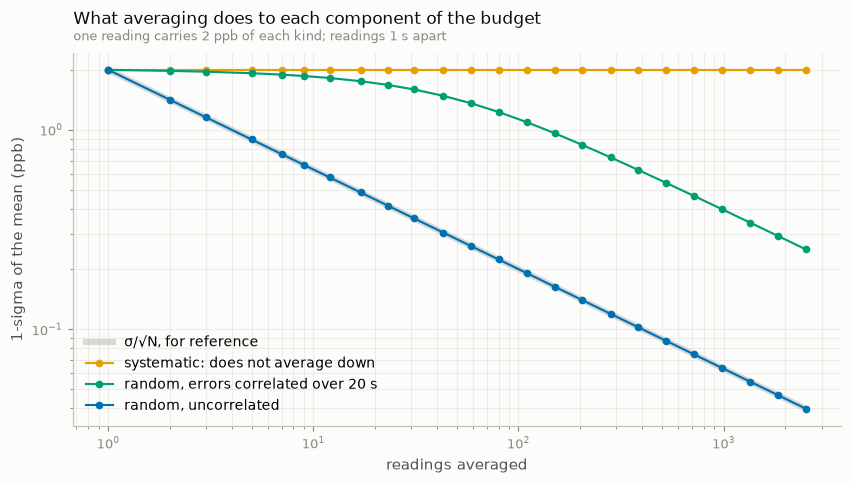

In [19]:
# The same two rules, plus a correlated random error, as the number of readings
# averaged grows. Each TSARA curve is checked against the textbook formula.
counts = np.unique(np.round(np.logspace(0, 3.4, 26)).astype(int))
independent, correlated, systematic, double_sum = [], [], [], []
for n in counts:
    ones, sigmas, clock = np.ones(n), np.full(n, SIGMA_PPB), np.arange(n, dtype=float)
    independent.append(propagate_random(sigmas, ones).sigma)
    correlated.append(propagate_random(sigmas, ones, tau_s=TAU_S, times_s=clock).sigma)
    systematic.append(propagate_systematic(sigmas, ones).sigma)
    double_sum.append(reference_ar1_sigma(SIGMA_PPB, clock, TAU_S))
check(
    "§5 independent readings: the sigma of the mean is σ/√N at every N",
    np.allclose(independent, SIGMA_PPB / np.sqrt(counts), rtol=1e-12),
)
check(
    "§5 systematic: the sigma of the mean is σ at every N",
    np.allclose(systematic, SIGMA_PPB, rtol=1e-12),
)
check(
    "§5 correlated (AR(1)) readings: TSARA's default form equals the double sum written out",
    np.allclose(correlated, double_sum, rtol=1e-9),
)

# Figure only from here.
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.loglog(
    counts,
    SIGMA_PPB / np.sqrt(counts),
    "-",
    color=MUTED,
    lw=4.0,
    alpha=0.30,
    label="σ/√N, for reference",
)
ax.loglog(counts, systematic, "o-", color=C2, ms=4, label="systematic: does not average down")
ax.loglog(
    counts, correlated, "o-", color=C3, ms=4, label=f"random, errors correlated over {TAU_S:g} s"
)
ax.loglog(counts, independent, "o-", color=C1, ms=4, label="random, uncorrelated")
finish(
    ax,
    "What averaging does to each component of the budget",
    f"one reading carries {SIGMA_PPB:g} ppb of each kind; readings 1 s apart",
    "1-sigma of the mean (ppb)",
    "readings averaged",
    legend=True,
    loc="lower left",
)
ax.grid(True, which="both", axis="both", alpha=0.55)
plt.show()

**What to read off the output.**

* **The manifest excerpt is the whole declaration.** `random` is an absolute
  2 ppb per reading, `systematic` is 1 % of the reading, and ingestion labels
  both `declared`.
* **The table.** The random column follows `RANDOM/√N` exactly, across
  three orders of magnitude of cell width. The systematic column does not move:
  averaging 2400 readings of a species whose calibration is 1 % uncertain
  leaves the mean 1 % uncertain, not 0.02 %. That is not conservatism. It is the
  exact result when every pair of errors is perfectly correlated, which is what
  calling a component systematic asserts. Collapsing the two into one number
  before averaging would apply one rule to both, so they stay separate
  throughout.
* **The figure's green line** is a third case, and the subject of the next two
  sections: a random error whose consecutive values stay alike for 20 s. It
  starts on σ/√N and peels away, because averaging readings that already
  agree buys less than averaging independent ones.

**Try it.**

* `SYSTEMATIC_RELATIVE = 0.05`: the systematic column is five times larger at
  every width, and still flat.
* `SYSTEMATIC_RELATIVE = 0`: the manifest declares no systematic component, the
  column disappears, and nothing is invented in its place. The provenance says
  `zero` for that component, which is different from `unknown`: an omitted
  calibration uncertainty must not read as a claim of perfect calibration.
* `TAU_S = 300.0`: errors that stay alike for five minutes. The green line hugs
  the orange for a hundred readings or more, and even after 2500 readings the
  mean is still about half as uncertain as a single reading.
* `CELL_WIDTHS_S = [7, 13, 90]`: widths that do not divide the record evenly.
  The ✔ still holds, since every cell is compared with its own loop.

---
## 6. Checked against random draws, not against more algebra

**The question.** Section 5 checked TSARA's arithmetic against the textbook
formulas. That proves the formulas were *typed* correctly. It cannot prove they
are the *right* formulas. Is the uncertainty TSARA attaches to a mean actually
the scatter that mean has?

**How it is answered.** Draw many realizations of an error whose structure is
known, average each one, and measure how much the averages really scatter. The
draws are written here from the textbook definitions rather than taken from
TSARA's generator, so that a misunderstanding shared by the two could not agree
with itself. Four kinds of error:

* **white noise**: independent draws;
* **systematic**: one offset per realization, shared by every reading in it;
* **AR(1)**: each error is ρ times the previous one plus fresh noise, with
  ρ = e^(−1 s / τ);
* the same AR(1) errors with the timescale *not declared*, which is what TSARA
  sees for every file in the real archive today.

TSARA offers three forms for correlated errors, all assuming AR(1):
`ar1_neff` (the default: an exact effective sample size for evenly spaced
readings), `ar1_asymptotic` (the textbook large-N formula), and
`ar1_double_sum` (every pair of readings correlated by the time between them;
the slow reference).

In [20]:
# ---- PARAMETERS (section 6) -------------------------------------------------
N_READINGS = 60  # readings averaged in each realization, 1 s apart
TRIALS = 40_000  # realizations drawn; the checks' tolerance scales with this
SIGMA_PPB = 2.0  # 1-sigma of one reading's error
TAU_S = 20.0  # decorrelation timescale of the AR(1) error
SEED = 4

In [21]:
start_section("§6")
rng = np.random.default_rng(SEED)
clock = np.arange(N_READINGS, dtype=float)
ones, sigmas = np.ones(N_READINGS), np.full(N_READINGS, SIGMA_PPB)

# The draws, from the definitions.
white = rng.normal(0.0, SIGMA_PPB, size=(TRIALS, N_READINGS))
shared = rng.normal(0.0, SIGMA_PPB, size=(TRIALS, 1)) * ones  # one offset per realization
rho = np.exp(-1.0 / TAU_S)
ar1 = np.empty((TRIALS, N_READINGS))
ar1[:, 0] = rng.normal(0.0, SIGMA_PPB, TRIALS)
for k in range(1, N_READINGS):
    ar1[:, k] = rho * ar1[:, k - 1] + rng.normal(0.0, SIGMA_PPB * np.sqrt(1 - rho**2), TRIALS)

observed = {
    "white": white.mean(axis=1).std(ddof=1),
    "systematic": shared.mean(axis=1).std(ddof=1),
    "ar1": ar1.mean(axis=1).std(ddof=1),
}
predicted = {
    "white noise, independent rule": ("white", propagate_random(sigmas, ones).sigma),
    "systematic rule": ("systematic", propagate_systematic(sigmas, ones).sigma),
    "AR(1), ar1_neff (default)": (
        "ar1",
        propagate_random(sigmas, ones, tau_s=TAU_S, times_s=clock).sigma,
    ),
    "AR(1), ar1_double_sum": (
        "ar1",
        propagate_random(sigmas, ones, tau_s=TAU_S, times_s=clock, form="ar1_double_sum").sigma,
    ),
    "AR(1), ar1_asymptotic": (
        "ar1",
        propagate_random(sigmas, ones, tau_s=TAU_S, times_s=clock, form="ar1_asymptotic").sigma,
    ),
    "AR(1), τ not declared": ("ar1", propagate_random(sigmas, ones).sigma),
}
tolerance = sampling_tolerance(TRIALS)
print(f"{'rule applied to':32} {'observed':>9} {'predicted':>10} {'ratio':>7}")
for label, (kind, value) in predicted.items():
    print(f"{label:32} {observed[kind]:>9.4f} {value:>10.4f} {value / observed[kind]:>7.3f}")
print(f"\nsampling tolerance on each ratio: ±{tolerance:.3f}\n")


def ratio(label):
    """Predicted over observed for one row."""
    kind, value = predicted[label]
    return value / observed[kind]


for label in (
    "white noise, independent rule",
    "systematic rule",
    "AR(1), ar1_neff (default)",
    "AR(1), ar1_double_sum",
):
    check(
        f"§6 {label}: predicts the scatter the draws really have",
        abs(ratio(label) - 1) < tolerance,
        f"{ratio(label):.3f}x",
    )
check(
    "§6 ar1_asymptotic is never narrower than the draws (it is a large-N bound)",
    ratio("AR(1), ar1_asymptotic") > 1 - tolerance,
    f"{ratio('AR(1), ar1_asymptotic'):.3f}x",
)
# Treating correlated errors as independent understates by exactly the factor
# the double sum says; checking that factor rather than a fixed "too narrow"
# keeps the claim true at any timescale, including one short enough not to matter.
expected = propagate_random(sigmas, ones).sigma / reference_ar1_sigma(SIGMA_PPB, clock, TAU_S)
check(
    "§6 an undeclared timescale understates by the factor the double sum predicts",
    abs(ratio("AR(1), τ not declared") / expected - 1) < tolerance,
    f"{ratio('AR(1), τ not declared'):.3f}x observed, {expected:.3f}x predicted",
)

rule applied to                   observed  predicted   ratio
white noise, independent rule       0.2569     0.2582   1.005
systematic rule                     1.9921     2.0000   1.004
AR(1), ar1_neff (default)           1.3537     1.3501   0.997
AR(1), ar1_double_sum               1.3537     1.3501   0.997
AR(1), ar1_asymptotic               1.3537     1.6332   1.206
AR(1), τ not declared               1.3537     0.2582   0.191

sampling tolerance on each ratio: ±0.011

  ✔ §6 white noise, independent rule: predicts the scatter the draws really have   [1.005x]
  ✔ §6 systematic rule: predicts the scatter the draws really have   [1.004x]
  ✔ §6 AR(1), ar1_neff (default): predicts the scatter the draws really have   [0.997x]
  ✔ §6 AR(1), ar1_double_sum: predicts the scatter the draws really have   [0.997x]
  ✔ §6 ar1_asymptotic is never narrower than the draws (it is a large-N bound)   [1.206x]
  ✔ §6 an undeclared timescale understates by the factor the double sum predicts   [0.191x 

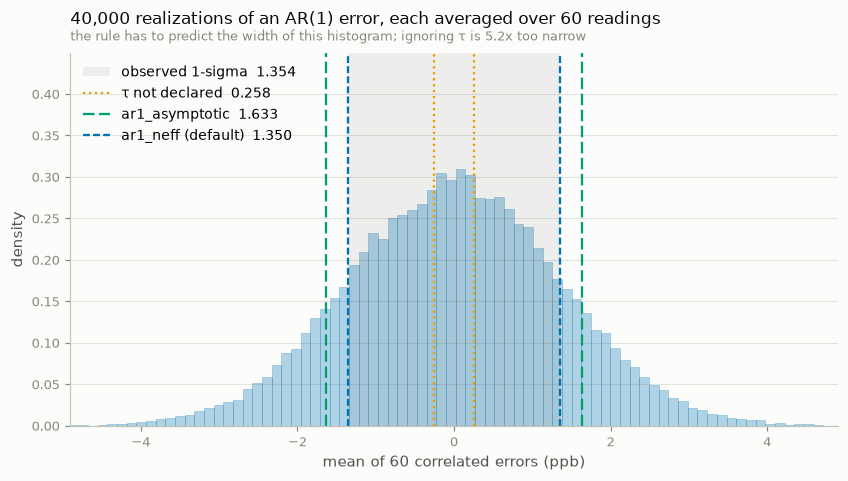

In [22]:
# Figure only.
means = ar1.mean(axis=1)
spread = float(means.std(ddof=1))
lines = {
    "τ not declared": predicted["AR(1), τ not declared"][1],
    "ar1_asymptotic": predicted["AR(1), ar1_asymptotic"][1],
    "ar1_neff (default)": predicted["AR(1), ar1_neff (default)"][1],
}
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.hist(means, bins=90, color=C1, alpha=0.30, edgecolor=C1, lw=0.5, density=True)
ax.axvspan(-spread, spread, color=INK, alpha=0.06, lw=0, label=f"observed 1-sigma  {spread:.3f}")
for (label, value), colour, dashes in zip(
    lines.items(), (C2, C3, C1), ((0, (1, 1.6)), (0, (5, 2)), (0, (3, 1.4)))
):
    ax.axvline(value, color=colour, lw=1.5, ls=dashes, label=f"{label}  {value:.3f}")
    ax.axvline(-value, color=colour, lw=1.5, ls=dashes)
limit = 3.0 * max(spread, *lines.values())
ax.set_xlim(-limit, limit)
heights, _ = np.histogram(means, bins=90, density=True)
ax.set_ylim(0, 1.45 * heights.max())  # headroom, so the legend covers no bars
finish(
    ax,
    f"{TRIALS:,} realizations of an AR(1) error, each averaged over {N_READINGS} readings",
    "the rule has to predict the width of this histogram; ignoring τ is "
    f"{spread / lines['τ not declared']:.1f}x too narrow",
    "density",
    f"mean of {N_READINGS} correlated errors (ppb)",
    legend=True,
    loc="upper left",
)
plt.show()

**What to read off the output.**

* **Four rules predict the scatter the draws really have**, each to within the
  sampling error of forty thousand draws: the independent rule on white noise,
  the systematic rule on a shared offset, and both `ar1_neff` and the reference
  `ar1_double_sum` on AR(1) errors. `ar1_neff` agrees with the reference to the
  last digits here because these readings are evenly spaced with equal sigma,
  exactly the case its effective sample size is exact for.
* **`ar1_asymptotic` is too wide**, because it is a large-N formula applied to a
  window only a few timescales long. Wrong in the safe direction.
* **Ignoring τ is confidently wrong.** In the figure, the dotted orange band is
  what treating these errors as independent claims, and it sits well inside the
  bulk of the histogram. That is why a declared σ is only ever moved onto
  another interval when a timescale was declared: the binner does that at the
  point of use and warns when it cannot (§7). Ingestion itself performs no such
  arithmetic at all — it records what the manifest declared and the interval it
  was declared at, and leaves the model to whichever stage needs it.

* **What this section does *not* establish.** Every correlated draw here is
  AR(1) by construction, which is the shape all three registered forms assume.
  So this shows the arithmetic is right *given* that model; it says nothing
  about whether a real instrument's error is AR(1). Drift or flicker noise
  would not be caught by anything here. Two threads pick that up: estimating τ
  from data (an Allan deviation would also show whether AR(1) fits at all),
  recorded as a future avenue in `METHODS.md` §7, and the Birge ratio of §5.1,
  which is where a wrong error model shows up downstream as fits that scatter
  more than their own error bars allow.

**Try it.**

* `TAU_S = 0.3`: consecutive errors are barely correlated, and every rule
  converges on the white-noise answer, including the one that ignores τ.
* `N_READINGS = 600`: `ar1_asymptotic` closes most of its gap, as a large-N
  formula should, while ignoring τ gets worse.
* `TRIALS = 2_000`: fifty times faster. The printed tolerance widens to about
  ±0.05, the histogram gets ragged, and the checks still hold.

---
## 7. Where the cheap form costs something, and a precision quoted at another interval

**The question.** The default form `ar1_neff` summarises a cell by two numbers:
how many readings it holds, and how far apart consecutive readings are. That is
exact when the readings are spread evenly. What does it cost when a dropout
splits a cell into two clumps?

**Why it could matter.** Thirty readings spread across a minute carry *more*
information than thirty readings in two blocks, because blocks far apart have
had time to decorrelate from each other. The count-and-spacing summary cannot
see the arrangement. The reference form, `ar1_double_sum`, can.

**How it is answered.** The same kind of AR(1) draws as section 6. Thirty
readings are taken either as one consecutive run or as two blocks separated by
a gap, and each form's prediction is compared with the observed scatter.

In [23]:
# ---- PARAMETERS (section 7) -------------------------------------------------
BLOCK_READINGS = 15  # readings in each of the two blocks (the run has twice this)
GAP_S = 30  # seconds of dropout between the two blocks
TAU_S = 20.0
SIGMA_PPB = 2.0
TRIALS = 40_000
SEED = 8

In [24]:
start_section("§7")
rng = np.random.default_rng(SEED)
length = 2 * BLOCK_READINGS + GAP_S  # readings in the full stretch, 1 s apart
rho = np.exp(-1.0 / TAU_S)
draws = np.empty((TRIALS, length))
draws[:, 0] = rng.normal(0.0, SIGMA_PPB, TRIALS)
for k in range(1, length):
    draws[:, k] = rho * draws[:, k - 1] + rng.normal(0.0, SIGMA_PPB * np.sqrt(1 - rho**2), TRIALS)

arrangements = {
    "one consecutive run": np.arange(2 * BLOCK_READINGS),
    "two blocks with a gap": np.r_[
        np.arange(BLOCK_READINGS), np.arange(length - BLOCK_READINGS, length)
    ],
}
n = 2 * BLOCK_READINGS
tolerance = sampling_tolerance(TRIALS)
print(f"{n} readings, arranged as    {'observed':>9} {'ar1_neff':>9} {'double sum':>11}")
for label, index in arrangements.items():
    seen = draws[:, index].mean(axis=1).std(ddof=1)
    times = index.astype(float)
    cheap = propagate_random(np.full(n, SIGMA_PPB), np.ones(n), tau_s=TAU_S, times_s=times).sigma
    exact = propagate_random(
        np.full(n, SIGMA_PPB), np.ones(n), tau_s=TAU_S, times_s=times, form="ar1_double_sum"
    ).sigma
    print(
        f"{label:27} {seen:>9.4f} {cheap:>9.4f} {exact:>11.4f}   "
        f"({cheap / seen:.3f}x, {exact / seen:.3f}x)"
    )
    check(
        f"§7 {label}: ar1_double_sum predicts the observed scatter",
        abs(exact / seen - 1) < tolerance,
        f"{exact / seen:.3f}x",
    )
    if label == "one consecutive run":
        check(
            "§7 one consecutive run: ar1_neff predicts the observed scatter",
            abs(cheap / seen - 1) < tolerance,
            f"{cheap / seen:.3f}x",
        )
    else:
        check(
            "§7 two blocks: ar1_neff errs only on the wide (safe) side",
            cheap / seen > 1 - tolerance,
            f"{cheap / seen:.3f}x",
        )

30 readings, arranged as     observed  ar1_neff  double sum
one consecutive run            1.6047    1.6040      1.6040   (1.000x, 1.000x)
  ✔ §7 one consecutive run: ar1_double_sum predicts the observed scatter   [1.000x]
  ✔ §7 one consecutive run: ar1_neff predicts the observed scatter   [1.000x]
two blocks with a gap          1.3360    1.6040      1.3431   (1.201x, 1.005x)
  ✔ §7 two blocks with a gap: ar1_double_sum predicts the observed scatter   [1.005x]
  ✔ §7 two blocks: ar1_neff errs only on the wide (safe) side   [1.201x]


**What to read off the output.** The cheap form is exact on the consecutive
run and overstates the uncertainty of the split one, while the reference form
tracks the draws in both. The reference form is selectable wherever a form is
(`propagation_form=` on the binner, pairing and grid), which is the point of
registering it.

**One claim here has been withdrawn, and it is worth saying why.** This text
used to add that the cheap form's error is "on the safe side, bounded by how
badly a cell's readings clump". That is true of the arrangement above and false
in general. `ar1_neff` knows a cell only by its reading count and the *median*
gap between readings, so which way it errs depends on which arrangement that
median describes. Measured against exact AR(1) draws, thirty readings with
τ = 20 s:

| thirty readings arranged as | observed σ of the mean | `ar1_neff` | |
|---|---|---|---|
| one run, 1 s apart | 1.608 | 1.604 | 0.997x |
| two blocks of 15, 30 s apart | 1.436 | 1.604 | 1.117x, safe |
| 15 tight pairs, pairs 50 s apart | 0.560 | 1.995 | 3.560x, very safe |
| **15 in a 0.15 s burst, 15 spread 100 s apart** | 1.035 | 0.368 | **0.355x, unsafe** |

Clusters normally drag the median gap down and make the estimate too wide. The
last row is the exception: with about half the readings in one burst and the
rest spread out, the median gap jumps to the *large* one while half the
information is really a single effective reading, and the form reports a third
of the true uncertainty. `ar1_double_sum` is right in every row.

Reaching that needs a declared τ — no archive file has one — *and* strongly
bimodal gaps inside a single cell, which one steady cadence never produces but
a cadence *change* does. `METHODS.md` §3.4 carries the table, and both rows are
pinned as tests.

**So is the reference form simply the right one, if you can pay for it?** Three
forms are registered, and what separates them is what each is *exact for*, not
only what each costs:

| form | exact for | cost |
|---|---|---|
| `ar1_neff` (the default) | equally spaced readings at any finite N: one steady cadence, holes included | O(N) per cell |
| `ar1_asymptotic` | the limit of many correlation times per cell | O(1) |
| `ar1_double_sum` | any arrangement of readings, **given AR(1)** | O(N²) per cell; refused above `DOUBLE_SUM_MAX_POINTS` = 5000 readings |

So the default is not "the cheap approximate one": it is exact for the common
case, and degrades only when the spacing varies *inside* a cell, which is the
shape this section builds on purpose. And "given AR(1)" is the whole of the
reference form's claim. It evaluates one model's algebra without approximation;
if the noise is not AR(1) it is exactly wrong, at any price. **Compute buys
exactness in the arrangement, not in the physics.** The error you can pay to
remove is measured and bounded (the table above: 0.355x at worst, on a shape
that needs a cadence change). The two you cannot -- whether the noise is AR(1)
at all, and what τ is -- are unmeasured, and on this archive they are the
larger ones. The cell below prices the exactness, per cell; a rolling stage
pays it once per window.

In [25]:
# What the exact form costs per cell, and where it stops. Timed here rather
# than quoted, so the numbers are this machine's and today's.
print(f"{'readings':>9} {'ar1_neff':>10} {'ar1_double_sum':>15} {'N×N float64':>12}")
refusal = "(no refusal)"
for count in (1_000, 5_000, 20_000):
    sigma, weight, clock = np.full(count, SIGMA_PPB), np.ones(count), np.arange(count, dtype=float)
    cost = {}
    for form, repeats in (("ar1_neff", 20), ("ar1_double_sum", 3)):
        try:
            propagate_random(sigma, weight, tau_s=TAU_S, times_s=clock, form=form)  # warm up
            started = time.perf_counter()
            for _ in range(repeats):
                propagate_random(sigma, weight, tau_s=TAU_S, times_s=clock, form=form)
            cost[form] = f"{(time.perf_counter() - started) / repeats * 1e3:.1f} ms"
        except TsaraPropagationError as refused:
            cost[form], refusal = "refused", str(refused)
    matrix_mb = count * count * 8 / 1e6
    print(f"{count:>9,} {cost['ar1_neff']:>10} {cost['ar1_double_sum']:>15} {matrix_mb:>9,.0f} MB")
print(f"\nthe refusal, above {DOUBLE_SUM_MAX_POINTS:,} readings:\n  {refusal}")
check(
    "§7 ar1_double_sum refuses a cell above DOUBLE_SUM_MAX_POINTS with a message naming ar1_neff",
    "ar1_neff" in refusal,
)

 readings   ar1_neff  ar1_double_sum  N×N float64
    1,000     0.3 ms         26.2 ms         8 MB


    5,000     0.4 ms        835.7 ms       200 MB
   20,000     1.1 ms         refused     3,200 MB

the refusal, above 5,000 readings:
  'ar1_double_sum' builds an N x N correlation matrix and got N = 20000, above the 5000 limit. Use 'ar1_neff', which is linear in N and agrees with this form to within the margin recorded in docs/METHODS.md §3.4.
  ✔ §7 ar1_double_sum refuses a cell above DOUBLE_SUM_MAX_POINTS with a message naming ar1_neff


**Keep in view:** none of this correlated-error machinery is exercised by the
real archive today. No file in it declares a decorrelation timescale, and TSARA
will not invent one, so every real sigma takes the independent path. What would
buy accuracy there is an *estimate of τ*, recorded as a future avenue in
`METHODS.md` §7, not a more expensive form.

**Try it.**

* `GAP_S = 0`: the two arrangements are the same readings, and the two forms
  agree.
* `GAP_S = 200`: the blocks are ten timescales apart and effectively
  independent, so the cheap form's overstatement grows.
* `TAU_S = 2.0`: correlation dies within a few readings, and the arrangement
  stops mattering.

---
### A precision quoted at a different interval

A spec sheet quotes precision at some interval, "2 ppb at 1 s", and the data may
arrive as means over longer cells. A manifest says so with `at_width`.
Ingestion records the mismatch and performs **no** arithmetic on it
(`METHODS.md` §10.8). The binner moves the figure onto the stream's cells at the
point of use, and only when a decorrelation timescale says how.

**How it is checked.** One CSV of cell means with a declared precision quoted at
a shorter interval, ingested under several declarations of τ, the first being
none. The moved sigma is compared with the scatter a mean of that many AR(1)
errors really has, from draws.

In [26]:
# ---- PARAMETERS (section 7, a quoted precision) -----------------------------
CELL_WIDTH_S = 10  # the file holds means over cells this wide
QUOTED_AT_S = 1  # the spec sheet quotes its precision at this interval
QUOTED_SIGMA_PPB = 2.0
TIMESCALES = [None, "1s", "5s", "30s", "5min"]  # None: the manifest declares no τ
AT_WIDTH_TRIALS = 100_000

In [27]:
def scatter_of_mean(count, spacing_s, tau_s, trials, seed=11):
    """Return the scatter of the mean of `count` unit-variance AR(1) errors, from draws."""
    draw = np.random.default_rng(seed)
    rho_t = np.exp(-spacing_s / tau_s)
    previous = draw.normal(0.0, 1.0, trials)
    total = previous.copy()
    for _ in range(count - 1):
        previous = rho_t * previous + draw.normal(0.0, np.sqrt(1.0 - rho_t**2), trials)
        total += previous
    return float((total / count).std(ddof=1))


folder = WORK / "precision"
folder.mkdir(exist_ok=True)
stamps = pd.date_range("2026-02-01 12:00:00", periods=3600 // CELL_WIDTH_S, freq=f"{CELL_WIDTH_S}s")
pd.DataFrame(
    {"time": stamps.strftime("%Y-%m-%d %H:%M:%S"), "ch4": np.full(stamps.size, 1950.0)}
).to_csv(folder / "means.csv", index=False)


def precision_manifest(tau):
    """Write the manifest: CELL_WIDTH_S means, precision quoted at QUOTED_AT_S, optional τ."""
    timescale = f"\n          decorrelation_timescale: {tau}" if tau else ""  # beside `random`
    path = folder / "manifest.yaml"
    path.write_text(f"""
name: precision_demo
base_path: {folder}
platform: {{kind: stationary, latitude: 40.76, longitude: -111.89}}
instruments:
  analyzer:
    loader:
      format: csv
      path_template: "means.csv"
      time: {{column: time, format: "%Y-%m-%d %H:%M:%S", timezone: UTC}}
      support: {{label: start, width: {CELL_WIDTH_S}s, method: mean}}
    variables:
      ch4:
        column: ch4
        role: gas
        units: ppb
        uncertainty:
          random:
            mode: declared
            absolute: {QUOTED_SIGMA_PPB}
            at_width: {QUOTED_AT_S}s{timescale}
""")
    return path


ingest_log = logging.getLogger("tsara.ingest")
tolerance = sampling_tolerance(AT_WIDTH_TRIALS)
print(
    f"{'τ declared':>11} {'sigma on the cells':>19} {'tsara_sigma_at_support':>23} "
    f"{'scatter from draws':>19}"
)
for tau in TIMESCALES:
    # Ingestion's warning about the mismatch is the same for every τ; hear it once.
    ingest_log.setLevel(logging.WARNING if tau is None else logging.ERROR)
    means = ingest_campaign(load_manifest(precision_manifest(tau)))["analyzer"]
    on_cells = bin_streams_onto_cells({"analyzer": means}, cells_of(means), ["ch4"])
    sigma = on_cells[sigma_rand_name("ch4")]
    moved, how = float(sigma.values[0]), sigma.attrs["tsara_sigma_at_support"]
    if tau is None or CELL_WIDTH_S == QUOTED_AT_S:
        truth = "depends on τ" if tau is None else "-"
        print(f"{str(tau):>11} {moved:>19.4f} {how:>23} {truth:>19}")
        continue
    tau_s = pd.Timedelta(tau).total_seconds()
    if CELL_WIDTH_S > QUOTED_AT_S:
        # The quoted figure is one QUOTED_AT_S error; a cell is the mean of this many.
        count = round(CELL_WIDTH_S / QUOTED_AT_S)
        truth = QUOTED_SIGMA_PPB * scatter_of_mean(count, QUOTED_AT_S, tau_s, AT_WIDTH_TRIALS)
    else:
        # The quoted figure is the mean of this many CELL_WIDTH_S errors.
        count = round(QUOTED_AT_S / CELL_WIDTH_S)
        truth = QUOTED_SIGMA_PPB / scatter_of_mean(count, CELL_WIDTH_S, tau_s, AT_WIDTH_TRIALS)
    print(f"{tau:>11} {moved:>19.4f} {how:>23} {truth:>19.4f}")
    check(
        f"§7 τ = {tau}: the sigma moved onto the cells matches draws",
        abs(moved / truth - 1) < tolerance,
        f"{moved / truth:.3f}x",
    )
    if CELL_WIDTH_S > QUOTED_AT_S:
        check(
            f"§7 τ = {tau}: the unscaled figure is an upper bound",
            QUOTED_SIGMA_PPB >= truth * (1 - tolerance),
        )
ingest_log.setLevel(logging.NOTSET)
recorded = means["ch4"].attrs
print(
    f"\nrecorded at ingestion: uncertainty_at_width = {recorded['uncertainty_at_width']}, "
    f"uncertainty_at_width_ratio = {recorded['uncertainty_at_width_ratio']}"
)
print(
    f"the naive answer, {QUOTED_SIGMA_PPB:g}/√{CELL_WIDTH_S // QUOTED_AT_S}: "
    f"{QUOTED_SIGMA_PPB / np.sqrt(max(CELL_WIDTH_S // QUOTED_AT_S, 1)):.4f}"
)

2026-09-23 12:21:45 | WARNING  | tsara.ingest.uncertainty | <work>/precision/means.csv: 'ch4' declares its uncertainty at 1s, but its cells are 10 times that interval. The figures are stored exactly as declared. Moving them onto another support needs a decorrelation timescale and is done by the stage that needs it (METHODS 3.4, 10.8), not at ingestion.


2026-09-23 12:21:45 | WARNING  | tsara.align.binning | ch4 declares its uncertainty at 1s but its cells are 10.000 s wide, and no decorrelation timescale was declared, so the figure is used unscaled. Declare decorrelation_timescale to move it onto the cells.


 τ declared  sigma on the cells  tsara_sigma_at_support  scatter from draws
       None              2.0000                unscaled        depends on τ
         1s              0.8899                ar1_neff              0.8886
  ✔ §7 τ = 1s: the sigma moved onto the cells matches draws   [1.001x]
  ✔ §7 τ = 1s: the unscaled figure is an upper bound
         5s              1.5132                ar1_neff              1.5096
  ✔ §7 τ = 5s: the sigma moved onto the cells matches draws   [1.002x]
  ✔ §7 τ = 5s: the unscaled figure is an upper bound
        30s              1.8959                ar1_neff              1.8943
  ✔ §7 τ = 30s: the sigma moved onto the cells matches draws   [1.001x]
  ✔ §7 τ = 30s: the unscaled figure is an upper bound
       5min              1.9891                ar1_neff              1.9896
  ✔ §7 τ = 5min: the sigma moved onto the cells matches draws   [1.000x]
  ✔ §7 τ = 5min: the unscaled figure is an upper bound

recorded at ingestion: uncertainty_at_wid

**What to read off the output.**

* **With no timescale** the figure is stored exactly as declared, labelled
  `unscaled`, and TSARA warns, once from ingestion and once from the binner.
* **With a timescale** the figure is moved onto the cells, and the moved value
  matches the scatter AR(1) errors of that timescale really produce.
* **The naive `σ/√N`** is right only when errors decorrelate well inside the
  quoted interval. Even at τ = 1 s, the length of that interval, it is about
  30 % too small, and at τ = 5 s it is less than half the true figure.
* **The unscaled figure is never optimistic.** Averaging positively correlated
  errors can only narrow them, so a figure left at its quoted interval is an
  upper bound on the figure for a wider cell. Of the available non-answers, it
  is the one that cannot make a fit look more certain than it is.

**Try it.**

* `CELL_WIDTH_S = 60`: sixty readings per cell. Every moved figure falls, and
  the gap to the naive `2/√60` grows with τ.
* `QUOTED_AT_S = 10`, equal to the cell width: nothing to move, and every row
  reports `unchanged`.

---
## 8. Pairing: the same operation, with a choice of clock

**The question.** A regression needs two species on one clock. Which clock,
and what makes a pair?

**What TSARA does** (`pair_species` in `src/tsara/align/pairing.py`). Pairing is
not a second implementation. It is `bin_streams_onto_cells` with three decisions
made for you:

1. **which cells**: those of the **wider-supported** member (the one whose
   cells are wider), so nothing is copied onto a finer support (§4); a partner
   is narrowed only by a clock whose cells vary in width, and the product says so;
2. **which stretch**: optionally one event or window;
3. **which rows survive**: a pair needs a real measurement of *both* species,
   so a cell missing either is dropped rather than filled.

The first rule used to say "the slower instrument", and rate and support
disagree in exactly the case that matters. A whole-air canister fills for about
fifteen seconds once every several minutes. Against a 60 s mean it is nine times
slower by rate and four times **narrower** by support. Pairing on its clock
would state a 60 s mean over 15 s of air.

**The campaign** (`canister_campaign`). An atmosphere holding methane and
benzene, crossed by plumes from a refinery that emits benzene at a known ratio
to methane. Two instruments measure it: `methane_analyzer`, a 1 Hz methane
analyzer, and `iwas`, a canister sampler taking 15 s benzene fills about every
nine minutes.

**How it is checked.** The clock is compared with the widths; every pair's two
values are recomputed with `reference_bin` over that pair's own cell; the pair
count is compared with the number of clock cells where both species exist; and
the fitted slope is compared with the emitted ratio.

In [28]:
# ---- PARAMETERS (section 8) -------------------------------------------------
SEED = 21
ANALYZER_RATE = "1s"  # how often the analyzer reports; slower rates are means over the interval
FILL_WIDTH = "15s"  # how long each canister fills
FILL_EVERY = "530s"  # mean time between fills
TRUE_RATIO = 0.004  # benzene enhancement / methane enhancement the source emits

In [29]:
start_section("§8")
canister = canister_campaign(
    seed=SEED,
    analyzer_rate=ANALYZER_RATE,
    fill_width=FILL_WIDTH,
    fill_every=FILL_EVERY,
    true_ratio=TRUE_RATIO,
)
streams = canister.streams
paired = pair_species(streams, "benzene", "ch4")
pairs = paired.dataset
print(f"clock : {paired.clock}   because: {pairs.attrs['tsara_pairing_clock_reason']}")
print(
    f"pairs : {paired.n_pairs}, from {streams['iwas'].sizes['time']} canister fills "
    f"and {streams['methane_analyzer'].sizes['time']} methane_analyzer readings"
)
print(f"readings behind the pairs: benzene {paired.y_readings}, methane {paired.x_readings}\n")

# CHECK 1: the documented rule, both halves of it. Width decides when the two
# differ; when they tie, the member with fewer measured values does. Comparing
# TSARA's answer with itself in the tie case -- which this check used to do --
# prints a ✔ having tested nothing, and at ANALYZER_RATE = "15s" that is
# exactly the branch it lands in.
width = {name: float(np.median(cells_of(s).width_ns)) / SECOND for name, s in streams.items()}
finite = {
    name: int(np.isfinite(np.asarray(s[v].values, dtype=float)).sum())
    for name, (s, v) in {
        "iwas": (streams["iwas"], "benzene"),
        "methane_analyzer": (streams["methane_analyzer"], "ch4"),
    }.items()
}
if width["iwas"] != width["methane_analyzer"]:
    expected_clock = max(width, key=width.get)
    why = f"wider cells: iwas {width['iwas']:g} s, methane_analyzer {width['methane_analyzer']:g} s"
else:
    # The tie rule. Counted over each whole record here, where TSARA counts
    # over the span the two records SHARE, so the two totals differ a little
    # (1920 against 1898 at ANALYZER_RATE = "15s"). Which member is the sparser
    # one is what the rule turns on, and that is the same either way.
    expected_clock = min(finite, key=lambda name: (finite[name], name))
    why = (
        f"equal cells ({width['iwas']:g} s); fewer measured values: "
        f"iwas {finite['iwas']}, methane_analyzer {finite['methane_analyzer']}"
    )
check(
    "§8 the clock follows the documented rule: wider cells, then fewer measured values",
    paired.clock == expected_clock,
    why,
)

# CHECK 2: every pair's two values, from the definition, over that pair's own cell.
pair_cells = cells_of(pairs)
values_ok = True
for variable, instrument in (("benzene", "iwas"), ("ch4", "methane_analyzer")):
    member = streams[instrument]
    reference = reference_bin(cells_of(member), member[variable].values, pair_cells)
    values_ok &= np.allclose(pairs[variable].values, reference["value"], rtol=1e-12, atol=0)
    values_ok &= np.array_equal(pairs[f"n_readings_{variable}"].values, reference["n_readings"])
check("§8 every pair's benzene and methane equal the loop over that pair's cell", values_ok)

# CHECK 3: nothing kept that is not real, nothing dropped that is.
clock_cells = cells_of(streams[paired.clock])
has_benzene = np.isfinite(
    reference_bin(cells_of(streams["iwas"]), streams["iwas"]["benzene"].values, clock_cells)[
        "value"
    ]
)
has_methane = np.isfinite(
    reference_bin(
        cells_of(streams["methane_analyzer"]),
        streams["methane_analyzer"]["ch4"].values,
        clock_cells,
    )["value"]
)
check(
    "§8 the pairs are exactly the clock cells holding a real measurement of both species",
    paired.n_pairs == int((has_benzene & has_methane).sum()),
    f"{int((has_benzene & has_methane).sum())} such cells",
)

# CHECK 4: the fitted slope recovers the ratio the source emitted.
x = pairs["ch4"].values - 1950.0  # enhancements over the known backgrounds
y = pairs["benzene"].values - 0.05
design = np.vstack([x, np.ones_like(x)]).T
(slope, intercept), *_ = np.linalg.lstsq(design, y, rcond=None)
residual = y - design @ np.array([slope, intercept])
slope_se = np.sqrt(residual @ residual / (x.size - 2) / np.sum((x - x.mean()) ** 2))
check(
    "§8 a least-squares fit of the pairs recovers the emitted ratio within 3 standard errors",
    abs(slope - TRUE_RATIO) < 3 * slope_se,
    f"slope {slope:.5f} ± {slope_se:.5f}, emitted {TRUE_RATIO}",
)
print()
print(
    pairs[["benzene", "ch4", "n_readings_ch4", "coverage_ch4"]]
    .to_dataframe()
    .head(4)
    .round(3)
    .to_string()
)

clock : iwas   because: wider cells (15 s vs 1 s)
pairs : 55, from 55 canister fills and 28800 methane_analyzer readings
readings behind the pairs: benzene 55, methane 880

  ✔ §8 the clock follows the documented rule: wider cells, then fewer measured values   [wider cells: iwas 15 s, methane_analyzer 1 s]
  ✔ §8 every pair's benzene and methane equal the loop over that pair's cell
  ✔ §8 the pairs are exactly the clock cells holding a real measurement of both species   [55 such cells]
  ✔ §8 a least-squares fit of the pairs recovers the emitted ratio within 3 standard errors   [slope 0.00400 ± 0.00002, emitted 0.004]

                               benzene       ch4  n_readings_ch4  coverage_ch4
time                                                                          
2026-06-16 15:00:11.897017252    0.629  2098.099              16           1.0
2026-06-16 15:08:10.467695855    0.337  2019.403              16           1.0
2026-06-16 15:19:38.410879640    0.062  1951.581         

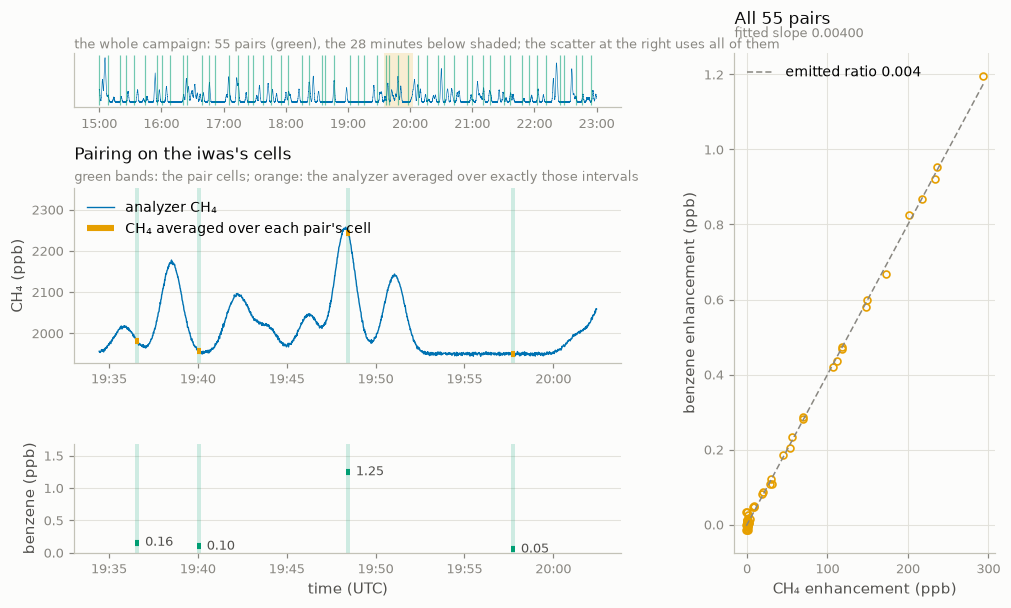

In [30]:
# Figure only. Twenty-eight minutes around the fill with the most benzene.
k = int(np.nanargmax(pairs["benzene"].values))
centre = pd.Timestamp(pairs["time"].values[k])
span = (centre - pd.Timedelta("14min"), centre + pd.Timedelta("14min"))
trace = streams["methane_analyzer"].sel(time=slice(*span))
t_trace, v_trace = break_gaps(trace["time"].values, trace["ch4"].values)
near = pairs.sel(time=slice(*span))
f0, f1 = bounds_of(near)

fig = plt.figure(figsize=(10.8, 5.9))
gs = fig.add_gridspec(
    3, 2, width_ratios=[2.1, 1.0], height_ratios=[0.5, 1.6, 1.0], hspace=0.72, wspace=0.28
)
axo = fig.add_subplot(gs[0, 0])
ax, axs = fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[:, 1])
axb = fig.add_subplot(gs[2, 0], sharex=ax)
# An overview strip, because the panels below show 28 minutes of a campaign
# hours long: every fill marked, and the drawn window shaded. The scatter on
# the right uses ALL the pairs, not only the ones in the window.
axo.plot(
    *break_gaps(
        streams["methane_analyzer"]["time"].values, streams["methane_analyzer"]["ch4"].values
    ),
    color=C1,
    lw=0.4,
)
all0, all1 = bounds_of(pairs)
axo.vlines(all0 + (all1 - all0) / 2, *axo.get_ylim(), color=C3, lw=0.8, alpha=0.55)
axo.axvspan(span[0], span[1], color=C2, alpha=0.16, lw=0)
axo.set_yticks([])
finish(
    axo,
    None,
    f"the whole campaign: {paired.n_pairs} pairs (green), the {(span[1] - span[0]).seconds // 60} "
    "minutes below shaded; the scatter at the right uses all of them",
    None,
    None,
    grid_axis=None,
)
hhmm(axo)
ax.plot(t_trace, v_trace, color=C1, lw=0.9, label="analyzer CH₄")
for x0, x1 in zip(f0, f1):
    ax.axvspan(x0, x1, color=C3, alpha=0.18, lw=0)
    axb.axvspan(x0, x1, color=C3, alpha=0.18, lw=0)
ax.hlines(near["ch4"].values, f0, f1, color=C2, lw=4.0, label="CH₄ averaged over each pair's cell")
lo, hi = np.nanmin(v_trace), np.nanmax(v_trace)
ax.set_ylim(lo - 0.05 * (hi - lo), hi + 0.3 * (hi - lo))
finish(
    ax,
    f"Pairing on the {paired.clock}'s cells",
    "green bands: the pair cells; orange: the analyzer averaged over exactly those intervals",
    "CH₄ (ppb)",
    legend=True,
    loc="upper left",
)
axb.hlines(near["benzene"].values, f0, f1, color=C3, lw=4.0)
for x0, x1, b in zip(f0, f1, near["benzene"].values):
    axb.text(x0 + (x1 - x0) / 2, b, f"  {b:.2f}", va="center", ha="left", fontsize=8.2, color=INK2)
axb.set_ylim(0, float(np.nanmax(near["benzene"].values)) * 1.35)
finish(axb, None, None, "benzene (ppb)", "time (UTC)")
hhmm(axb)
axs.plot(x, y, "o", color=C2, ms=4.5, mfc="none", mew=1.1)
line = np.linspace(min(0.0, np.nanmin(x)), np.nanmax(x), 10)
axs.plot(
    line,
    TRUE_RATIO * line,
    color=MUTED,
    lw=1.0,
    ls=(0, (4, 2)),
    label=f"emitted ratio {TRUE_RATIO}",
)
finish(
    axs,
    f"All {paired.n_pairs} pairs",
    f"fitted slope {slope:.5f}",
    "benzene enhancement (ppb)",
    "CH₄ enhancement (ppb)",
    legend=True,
    loc="upper left",
    grid_axis="both",
)
plt.show()

**What to read off the output.**

* **The clock is the canister**, and the printed reason names the widths, not
  the rates.
* **Every pair holds real measurements of both species, and each is exactly the
  definition over its own cell.** Each methane value is the average of the 1 Hz
  readings over the interval that canister filled: sixteen contributing
  readings, counting the two partial ones at the edges.
* **Most of the methane record is not used.** It has no benzene partner, and
  pairing does not manufacture one.
* **The fitted slope recovers the emitted ratio**, over one pair per fill.

That last phrase is the property pairing protects: **no measurement is counted
twice**, so the number of pairs is the number of independent points a
regression really has (property 5). Section 4 guards the obvious violation;
section 9 is a case where it broke anyway, quietly, until the walkthrough found
it. And when a reading *must* land in two pairs, the product says so: the
`readings behind the pairs` line.

**Try it.**

* `ANALYZER_RATE = "30s"`: the analyzer now reports 30 s means, wider than a
  15 s fill, so **the clock flips to the analyzer** and the reason says why.
  There are now more pairs than canister readings, because a fill that straddles
  two analyzer cells lands in both. TSARA warns about exactly that, and the
  readings line shows it. The slope still recovers the ratio.
* `FILL_WIDTH = "90s"`: the canister stays the clock, and each pair's methane
  now rests on about ninety readings.
* `TRUE_RATIO = 0.02`: the checks hold and the scatter plot steepens.

---
### What a paired product holds

`pair_species` returns a small record around an ordinary, self-describing
dataset: the clock, the pair count, and how many distinct readings of each
species stand behind the pairs. Here is the dataset, and each species'
attributes.

In [31]:
print(
    f"y_name={paired.y_name!r}  x_name={paired.x_name!r}  clock={paired.clock!r}  "
    f"n_pairs={paired.n_pairs}  y_readings={paired.y_readings}  x_readings={paired.x_readings}\n"
)
print(pairs)
for name in (paired.y_name, paired.x_name):
    print(f"\n{name}:")
    for key, value in pairs[name].attrs.items():
        print(f"    {key:24} {value}")

y_name='benzene'  x_name='ch4'  clock='iwas'  n_pairs=55  y_readings=55  x_readings=880

<xarray.Dataset> Size: 5kB
Dimensions:             (time: 55, nv: 2)
Coordinates:
  * time                (time) datetime64[ns] 440B 2026-06-16T15:00:11.897017...
    time_bnds           (time, nv) datetime64[ns] 880B 2026-06-16T15:00:04.39...
Dimensions without coordinates: nv
Data variables:
    benzene             (time) float64 440B 0.6291 0.3374 ... 0.1572 0.04521
    n_readings_benzene  (time) int64 440B 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    coverage_benzene    (time) float64 440B 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    borrowed_benzene    (time) float64 440B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    ch4                 (time) float64 440B 2.098e+03 2.019e+03 ... 1.951e+03
    n_readings_ch4      (time) int64 440B 16 16 16 16 16 16 ... 16 16 16 16 16
    coverage_ch4        (time) float64 440B 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    borrowed_ch4        (time) float64 440B 0.01232 0.03319 ..

One row per surviving pair. `time` is the midpoint of the canister fill, and
`time_bnds` its own start and stop, so each pair says which interval of air it
describes. Each species brings its value, `n_readings_`, `coverage_` and `borrowed_`.
Uncertainty columns travel too when the streams carry them: these generated
streams publish none, while the ingested ones in sections 5 and 7 do.

The dataset's attributes record every decision `pair_species` made: which
clock and why, the `min_coverage` applied, how many candidate cells it
considered and how many it dropped. Each species keeps what its manifest
declared (`units`, `role`, `cell_methods`) and adds where it came from, whether
this stage averaged it (`tsara_binned`: 0 for benzene, already on its own
clock; 1 for methane), what the join did to it (`tsara_support_transform`, the
width ratio and the borrowed share, §4), and `tsara_n_readings`, counted over the
surviving pairs.

A paired product is not saved into a bundle. It is an intermediate the
detection phase will request once per event, and `to_netcdf` writes it like any
other dataset.

---
### One window at a time, and only cells that were measured

Two arguments narrow what is paired. `interval` keeps the clock's cells that
overlap a window, which is how an event will be paired once plumes are
detected. `min_coverage` drops pairs whose cell was too thinly measured.
Section 2's campaign has what both need: two clocks, and dropouts. One left a
minute under a tenth measured; another took a quarter of a minute holding a
plume, which left that minute wrong by about 50 ppb.

In [32]:
# ---- PARAMETERS (section 8, windows and coverage) --------------------------
WINDOW_START_S = -30  # window start, in seconds from the start of the least-covered minute
WINDOW_LENGTH_S = 180  # window length, seconds
MIN_COVERAGES = [0.0, 0.5, 0.9, 1.0]

In [33]:
minute_streams = minute_campaign().streams  # section 2's campaign at its defaults
on_minutes = bin_streams_onto_cells(minute_streams, cells_of(minute_streams["minute"]), ["ch4"])
least = pd.Timestamp(
    minute_streams["minute"]["time_bnds"].values[
        int(np.argmin(on_minutes["coverage_ch4"].values)), 0
    ]
)
window = (
    least + pd.Timedelta(seconds=WINDOW_START_S),
    least + pd.Timedelta(seconds=WINDOW_START_S + WINDOW_LENGTH_S),
)

in_window = pair_species(minute_streams, "minute_ch4", "ch4", interval=window)
edges = in_window.dataset["time_bnds"].values
print(f"least-covered minute starts {least:%H:%M:%S}")
print(
    f"window {window[0]:%H:%M:%S} to {window[1]:%H:%M:%S}: {in_window.n_pairs} pairs, "
    f"from {pd.Timestamp(edges[0, 0]):%H:%M:%S} to {pd.Timestamp(edges[-1, 1]):%H:%M:%S}"
)
# CHECK: the window returns whole cells, exactly those of the clock that overlap it.
clock_cells = cells_of(minute_streams["minute"])
overlapping = (clock_cells.stop_ns > window[0].value) & (clock_cells.start_ns < window[1].value)
check(
    "§8 a window returns exactly the clock's whole cells that overlap it",
    np.array_equal(cells_of(in_window.dataset).start_ns, clock_cells.start_ns[overlapping]),
)

print(
    f"\n{'min_coverage':>12} {'pairs':>6} {'dropped':>8} {'least coverage kept':>20} "
    f"{'worst |difference|':>19}"
)
coverage_ok = True
for threshold in MIN_COVERAGES:
    kept = pair_species(minute_streams, "minute_ch4", "ch4", min_coverage=threshold).dataset
    worst = np.abs(kept["ch4"].values - kept["minute_ch4"].values).max()
    coverage_ok &= bool(np.all(kept["coverage_ch4"].values >= threshold))
    coverage_ok &= (
        kept.sizes["time"] + kept.attrs["tsara_pairing_cells_dropped"]
        == kept.attrs["tsara_pairing_cells_considered"]
    )
    dropped = kept.attrs["tsara_pairing_cells_dropped"]
    print(
        f"{threshold:>12.2f} {kept.sizes['time']:>6} {dropped:>8} "
        f"{kept['coverage_ch4'].values.min():>20.3f} {worst:>15.2f} ppb"
    )
check("§8 every pair kept meets min_coverage, and kept + dropped = considered", coverage_ok)

least-covered minute starts 14:40:00
window 14:39:30 to 14:42:30: 4 pairs, from 14:39:00 to 14:43:00
  ✔ §8 a window returns exactly the clock's whole cells that overlap it

min_coverage  pairs  dropped  least coverage kept  worst |difference|
        0.00     60        0                0.075           51.23 ppb
        0.50     58        2                0.617           51.23 ppb
        0.90     55        5                0.992            0.84 ppb
        1.00     54        6                1.000            0.84 ppb
  ✔ §8 every pair kept meets min_coverage, and kept + dropped = considered


**What to read off the output.** A window selects **whole cells**: asking for
three minutes starting half a minute before the bad minute returns the four
minutes that window touches, from their own starts to their own stops. Clipping a
cell would make a pair describe a different interval from the one the
instrument averaged.

`min_coverage` is the lever on the bad minutes. At 0 they stay, and the worst
pair is out by about 50 ppb. At 0.5 the two most thinly measured minutes go but
the worst pair stays, since three-quarters of a minute passes that threshold.
At 0.9 it goes too, and the worst pair is at the level of the noise. The default is 0 (record coverage, drop nothing), because how much of a
cell must be measured is a science question. On the real 2024 canister drive, a
methane analyzer reporting every 2–3 s covers a median 0.43 of each fill
(`METHODS.md` §11.4), so a threshold of 0.9 would silently discard the whole
canister record. Notebook 04b shows that refusal on the real files.

**Try it.** `MIN_COVERAGES = [0.99, 1.0]`: at 1.0 the hour's last minute also
goes, because the record stops half a reading before its end.

---
### One species on two analyzers

Comparing two analyzers of the same gas is routine, and it is the one case
where a bare name cannot say which measurement is meant. A manifest may give
both instruments' methane the same name, `ch4`, because names only have to be
unique *within* an instrument; what says they are the same gas is that both
record `field: ch4` (`METHODS.md` §1.6). Here section 2's campaign is built
with `minute_variable="ch4"`, so both instruments call their methane `ch4`.

In [34]:
# Section 2's campaign, with the minute instrument's methane also named plain `ch4`.
same_names = minute_campaign(minute_variable="ch4").streams
two_analyzers = {"fast": measured(same_names["fast"]), "minute": measured(same_names["minute"])}
print(
    "fields:", {name: stream["ch4"].attrs["field"] for name, stream in two_analyzers.items()}, "\n"
)
try:
    pair_species(two_analyzers, "ch4", "ch4")
    refused_bare = False
except TsaraAlignError as refused:
    refused_bare = True
    print(f"named alone: {refused}\n")
check("§8 a species name two instruments share is refused rather than guessed", refused_bare)

compared = pair_species(two_analyzers, ("minute", "ch4"), ("fast", "ch4"))
print(
    f"named with instruments: y_name={compared.y_name!r}, x_name={compared.x_name!r}, "
    f"clock {compared.clock!r}, {compared.n_pairs} pairs"
)
check(
    "§8 naming the instruments suffixes each column with its instrument",
    (compared.y_name, compared.x_name) == ("ch4_minute", "ch4_fast"),
)

for chosen in (None, [("fast", "ch4")]):
    out = bin_streams_onto_cells(two_analyzers, cells_of(two_analyzers["minute"]), chosen)
    print(f"\nbin_streams_onto_cells(variables={chosen}) -> {sorted(map(str, out.data_vars))}")
print(f"where that plain ch4 came from: {out['ch4'].attrs['tsara_instrument']!r}")

fields: {'fast': 'ch4', 'minute': 'ch4'} 

named alone: 'ch4' is measured by more than one instrument (['fast', 'minute']), so naming it alone is ambiguous. Pass an (instrument, variable) pair to say which one.

  ✔ §8 a species name two instruments share is refused rather than guessed
named with instruments: y_name='ch4_minute', x_name='ch4_fast', clock 'minute', 60 pairs
  ✔ §8 naming the instruments suffixes each column with its instrument

bin_streams_onto_cells(variables=None) -> ['borrowed_ch4_fast', 'borrowed_ch4_minute', 'ch4_fast', 'ch4_minute', 'coverage_ch4_fast', 'coverage_ch4_minute', 'n_readings_ch4_fast', 'n_readings_ch4_minute']

bin_streams_onto_cells(variables=[('fast', 'ch4')]) -> ['borrowed_ch4', 'ch4', 'coverage_ch4', 'n_readings_ch4']
where that plain ch4 came from: 'fast'


Neither analyzer silently wins. Named alone, `ch4` is refused, naming both
instruments. Named with its instrument, each column gains that instrument as a
suffix. The spelling depends on the selection (the same methane is plain `ch4`
when it is the only one selected), which is why every column also records
`tsara_instrument`, and why code reading a pair should ask `y_name` and
`x_name` rather than assume a name.

`variables=None` selects every variable in every stream except companion
columns (`n_readings_`, `coverage_`, sigmas, angular quality numbers). It is the
exploratory default; a receptor-model matrix normally names its columns. The
generator's streams also carry their answer key as `truth_*` columns, which the
default would take like any other variable, which is why `measured` drops them.

---
## 9. When the two clocks are the same width

**The question.** "The wider-supported member" has no answer when both
instruments have 1 s cells, which in a 1 s drive suite is the ordinary case.
What happens then?

**Why it matters.** Equal-width cells in phase coincide, and nothing is
averaged. Two things put them half a cell apart in practice. One file's
timestamps name the start of each second and another's the middle, a real
disagreement between instrument teams sharing one data merge (the 2024 NOAA
drives: NOy-LIF writes `Time_Mid`, the Picarro `Time_Start`). And an analyzer
that reports only every second or third row of a 1 s file sits beside one that
fills every row.

The code as first written broke the tie by taking **whichever species you named
first**. On the real 2024-07-18 drive, `pair_species(streams, "noy", "co2")`
made twice as many pairs as the other order, from the same readings.

**What TSARA does now.** A width tie goes to the member with **fewer measured
values where the records overlap**; a tie in that goes to the instrument name.
Argument order never matters.

**The construction.** A sparse CO₂ analyzer on cells starting on the second, and
a dense NOy instrument on cells centred on it, both built from exact
half-second tiles of generator truth.

In [35]:
# ---- PARAMETERS (section 9) -------------------------------------------------
SEED = 9
CO2_NEXT_ROW_PROBABILITY = 0.7  # chance the next CO₂ value is 2 rows later (otherwise 3)
NOY_HALF_SECOND_LATE = True  # False puts both instruments on identical cells
MC_REALIZATIONS = 300  # noise redraws in the Monte Carlo below (about 20 s at 300)

In [36]:
start_section("§9")
TIE = {
    "name": "tie_demo",
    "seed": SEED,
    "start": "2026-06-17T18:00:00Z",
    "duration": "1h",
    "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
    "atmosphere": {
        "fields": {"co2": _field(420.0, "ppm"), "noy": _field(2.0)},
        "sources": {
            "traffic": {
                "rate_per_hour": 150.0,
                "reference_species": "co2",
                "shape": {"kind": "emg", "sigma": "1.5s", "tau": "3s"},
                "amplitude": {"kind": "lognormal", "median": 12.0, "sigma_log": 0.7},
                "ratios": {"noy": {"mean": 8.0}},
            }
        },
    },
    # Half-second means of the atmosphere, so both 1 s instruments below can be
    # built from exact pairs of tiles at two different phases.
    "instruments": {
        "fine": {
            "native_rate": "0.5s",
            "support": {"method": "mean"},
            "measures": {"co2": {}, "noy": {}},
        }
    },
}
fine = generate(SyntheticConfig.model_validate(TIE)).streams["fine"]
tiles = cells_of(fine)
offset = 1 if NOY_HALF_SECOND_LATE else 0
n_cells = (len(tiles) - 1) // 2
# CO₂ cells: tiles (0,1), (2,3), ...   NOy cells: tiles (offset, offset+1), ...
co2_start, co2_stop = tiles.start_ns[0 : 2 * n_cells : 2], tiles.stop_ns[1 : 2 * n_cells : 2]
noy_start, noy_stop = (
    tiles.start_ns[offset : 2 * n_cells + offset : 2],
    tiles.stop_ns[offset + 1 : 2 * n_cells + offset + 1 : 2],
)
co2_true = fine["co2"].values[: 2 * n_cells].reshape(n_cells, 2).mean(axis=1)
noy_true = fine["noy"].values[offset : 2 * n_cells + offset].reshape(n_cells, 2).mean(axis=1)

rng = np.random.default_rng(3)
has_value = np.zeros(n_cells, dtype=bool)
row = 0
while row < n_cells:  # a CO₂ value every 2nd or 3rd row, as the analyzer writes them
    has_value[row] = True
    row += 2 if rng.random() < CO2_NEXT_ROW_PROBABILITY else 3
co2_observed = np.where(has_value, co2_true + rng.normal(0.0, 0.15, n_cells), np.nan)
noy_observed = noy_true + rng.normal(0.0, 1.0, n_cells)
tie_streams = {
    "picarro": make_stream(co2_start, co2_stop, {"co2": co2_observed}),
    "lif": make_stream(noy_start, noy_stop, {"noy": noy_observed}),
}
print(f"CO₂ readings: {int(has_value.sum())};  NOy readings: {n_cells}\n")

# What naming NOy first used to do: the same join on NOy's cells.
on_noy = bin_streams_onto_cells(tie_streams, cells_of(tie_streams["lif"]), ["co2", "noy"])
old_pairs = int((np.isfinite(on_noy["co2"].values) & np.isfinite(on_noy["noy"].values)).sum())
print(
    f"on the NOy clock (the old tie-break): {old_pairs} pairs "
    f"from {int(has_value.sum())} CO₂ readings\n"
)

results = {}
for y, x in (("noy", "co2"), ("co2", "noy")):
    p = pair_species(tie_streams, y, x)
    results[y, x] = p
    print(
        f"pair_species(streams, {y!r:6}, {x!r:6}) -> clock {p.clock:8} {p.n_pairs:>5} pairs; "
        f"readings co2 {p.dataset['co2'].attrs['tsara_n_readings']}, "
        f"noy {p.dataset['noy'].attrs['tsara_n_readings']}; "
        f"noy readings shared between pairs {p.dataset['noy'].attrs['tsara_shared_readings']}"
    )
print(f"\nwhy: {p.dataset.attrs['tsara_pairing_clock_reason']}\n")
forward, backward = results["noy", "co2"], results["co2", "noy"]
check(
    "§9 swapping the arguments changes neither the clock nor the pairs",
    forward.clock == backward.clock
    and np.array_equal(forward.dataset["co2"].values, backward.dataset["co2"].values),
)
check(
    "§9 on the chosen clock each CO₂ reading is in exactly one pair",
    forward.dataset["co2"].attrs["tsara_n_readings"] == forward.n_pairs == int(has_value.sum()),
)
check(
    "§9 sparse CO₂: no NOy reading formed two pairs, so the pairs are independent",
    forward.dataset["noy"].attrs["tsara_shared_readings"] == 0,
)

2026-09-23 12:21:46 | WARNING  | tsara.align.binning | 1 column(s) of this join rest on air the readings did not measure over the cells reported (METHODS §11.2.4): 'co2' (3127 rows from 1564 readings; borrowed share 0.50). A reading wider than the cell it fills has its value stand for a shorter interval than it measured; rows outnumbering readings means some reading sits in more than one row, which a fit or receptor model treating rows as independent counts more than once. Each column records tsara_support_transform, tsara_width_ratio_max, tsara_borrowed_share and tsara_n_readings, and carries the share borrowed per cell in borrowed_<name>.


2026-09-23 12:21:46 | WARNING  | tsara.align.pairing | Every pair blends two readings of 'noy': its cells are as wide as the clock's (1 s) but offset by 0.5 s, so each value blends the two readings straddling its cell and rests on air outside it by the borrowed share (0.50). No reading formed more than one of the 1564 pairs, so the pairs are independent and no coarser clock is needed (METHODS §11.4.1).


2026-09-23 12:21:46 | WARNING  | tsara.align.pairing | Every pair blends two readings of 'noy': its cells are as wide as the clock's (1 s) but offset by 0.5 s, so each value blends the two readings straddling its cell and rests on air outside it by the borrowed share (0.50). No reading formed more than one of the 1564 pairs, so the pairs are independent and no coarser clock is needed (METHODS §11.4.1).


CO₂ readings: 1564;  NOy readings: 3599

on the NOy clock (the old tie-break): 3127 pairs from 1564 CO₂ readings

pair_species(streams, 'noy' , 'co2' ) -> clock picarro   1564 pairs; readings co2 1564, noy 3127; noy readings shared between pairs 0
pair_species(streams, 'co2' , 'noy' ) -> clock picarro   1564 pairs; readings co2 1564, noy 3127; noy readings shared between pairs 0

why: equal cells (1 s); fewer measured values where the records overlap (1564 vs 3599)

  ✔ §9 swapping the arguments changes neither the clock nor the pairs
  ✔ §9 on the chosen clock each CO₂ reading is in exactly one pair
  ✔ §9 sparse CO₂: no NOy reading formed two pairs, so the pairs are independent


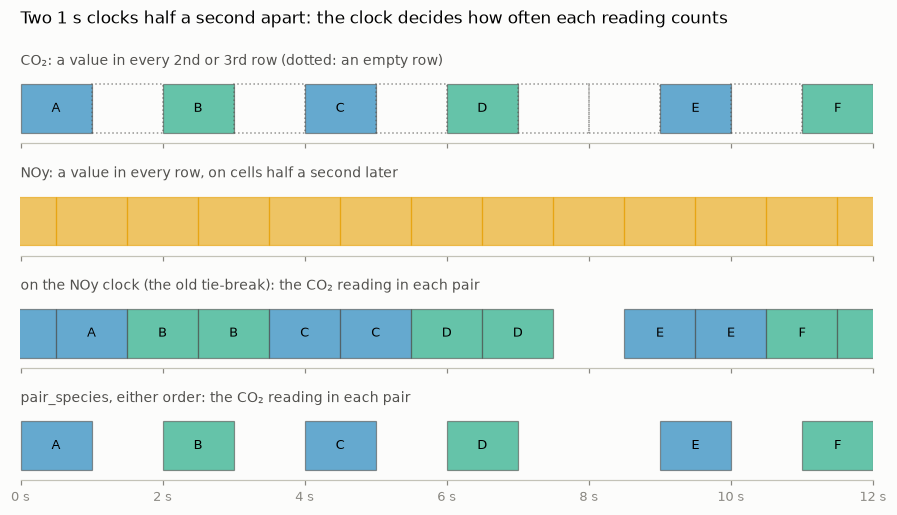

In [37]:
# Figure only: which CO₂ reading each pair draws on, over twelve seconds.
def co2_reading_in_each_pair(pair_cells):
    """Index of the CO₂ reading each pair cell overlaps (-1 if none), by a plain loop."""
    chosen = np.full(len(pair_cells), -1)
    for k in range(len(pair_cells)):
        overlap = np.minimum(co2_stop, pair_cells.stop_ns[k]) - np.maximum(
            co2_start, pair_cells.start_ns[k]
        )
        hit = np.flatnonzero((overlap > 0) & has_value)
        if hit.size:
            chosen[k] = hit[0]
    return chosen


z0 = int(co2_start[40])
z1 = z0 + 12 * SECOND
letters = {
    int(i): "ABCDEFGHIJKLMNOP"[j]
    for j, i in enumerate(np.flatnonzero(has_value & (co2_start >= z0) & (co2_stop <= z1)))
}


def lane(ax, starts, stops, filled, label, tags=None, colours=None):
    """Draw one row of cells; label whole cells inside the window."""
    for i, (s, e) in enumerate(zip(starts, stops)):
        if e <= z0 or s >= z1:
            continue
        colour = colours[i] if colours is not None else C2
        ax.add_patch(
            plt.Rectangle(
                (s, 0.15),
                e - s,
                0.7,
                facecolor=colour if filled[i] else "none",
                edgecolor=colour if colours is None else INK2,
                alpha=0.6,
                lw=0.8 if filled[i] else 1.0,
                ls="-" if filled[i] else ":",
            )
        )
        if tags is not None and tags[i] and s >= z0 and e <= z1:
            ax.text(s + (e - s) / 2, 0.5, tags[i], ha="center", va="center", fontsize=8.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)
    ax.text(0, 1.08, label, transform=ax.transAxes, fontsize=9, color=INK2, va="bottom")


def shade(tag):
    """Alternate two colours by reading, so neighbouring readings differ."""
    return C1 if "ABCDEFGHIJKLMNOP".index(tag) % 2 == 0 else C3


fig, axes = plt.subplots(4, 1, figsize=(10.0, 4.8), sharex=True, gridspec_kw={"hspace": 0.62})
co2_tags = [letters.get(i, "") for i in range(n_cells)]
lane(
    axes[0],
    co2_start,
    co2_stop,
    has_value,
    "CO₂: a value in every 2nd or 3rd row (dotted: an empty row)",
    tags=co2_tags,
    colours=[shade(t) if t else C1 for t in co2_tags],
)
lane(
    axes[1],
    noy_start,
    noy_stop,
    np.ones(n_cells, dtype=bool),
    "NOy: a value in every row"
    + (", on cells half a second later" if NOY_HALF_SECOND_LATE else ", on the same cells"),
)
old = on_noy.isel(
    time=np.flatnonzero(np.isfinite(on_noy["co2"].values) & np.isfinite(on_noy["noy"].values))
)
for ax, (pairs9, label) in zip(
    axes[2:],
    (
        (old, "on the NOy clock (the old tie-break): the CO₂ reading in each pair"),
        (forward.dataset, "pair_species, either order: the CO₂ reading in each pair"),
    ),
):
    cells9 = cells_of(pairs9)
    tags = [letters.get(int(r), "") for r in co2_reading_in_each_pair(cells9)]
    lane(
        ax,
        cells9.start_ns,
        cells9.stop_ns,
        np.ones(len(tags), dtype=bool),
        label,
        tags=tags,
        colours=[shade(t) if t else GRID for t in tags],
    )
axes[-1].set_xlim(z0, z1)
ticks = np.arange(z0, z1 + 1, 2 * SECOND)
axes[-1].set_xticks(ticks, [f"{(tick - z0) / SECOND:.0f} s" for tick in ticks])
fig.suptitle(
    "Two 1 s clocks half a second apart: the clock decides how often each reading counts",
    x=0.125,
    ha="left",
    fontsize=11,
    y=1.0,
)
plt.show()

**Reading the figure.** Read the bottom two rows against the top one. On the
NOy clock every CO₂ reading straddles the boundary between two NOy cells, so it
half-covers each and appears in **both** pairs: A twice, B twice. On the chosen
clock each reading is one pair, and the NOy beside it is the average of the two
NOy cells it straddles.

**Is duplication actually harmful?** Two things suggest not. The duplicates
carry *different* NOy values, so they are not pure copies. And for an ordinary
least-squares slope the two clocks give the **same** answer: a reading that
appears twice, once with each neighbour, pulls on the line exactly as one
appearance with the neighbours' mean does.

The uncertainty can tell them apart. What each copy duplicates is the CO₂
reading's *error*, and a fit that treats the pairs as independent counts that
error twice. Only an experiment settles how much that costs: the same two
clocks, a smooth signal so both instruments see identical air to well within
noise, and the noise redrawn many times.

In [38]:
def one_realization(seed, sigma_co2, sigma_noy, sparse=True):
    """Smooth truth on the two clocks above, with fresh noise."""
    draw = np.random.default_rng(seed)
    t_co2 = (co2_start + co2_stop) / 2 / SECOND
    t_noy = (noy_start + noy_stop) / 2 / SECOND

    def wave(t):
        return 10.0 * np.sin(2 * np.pi * (t - t_co2[0]) / 600.0)

    co2 = 420.0 + wave(t_co2) + draw.normal(0.0, sigma_co2, n_cells)
    if sparse:
        co2[~has_value] = np.nan
    noy = 2.0 + 8.0 * wave(t_noy) + draw.normal(0.0, sigma_noy, n_cells)
    return {
        "picarro": make_stream(co2_start, co2_stop, {"co2": co2}),
        "lif": make_stream(noy_start, noy_stop, {"noy": noy}),
    }


def ols(joined):
    """Least-squares NOy-on-CO₂ slope and the standard error it reports."""
    keep = np.isfinite(joined["co2"].values) & np.isfinite(joined["noy"].values)
    x, y = joined["co2"].values[keep], joined["noy"].values[keep]
    design = np.vstack([x, np.ones_like(x)]).T
    coef, *_ = np.linalg.lstsq(design, y, rcond=None)
    resid = y - design @ coef
    return coef[0], np.sqrt(resid @ resid / (x.size - 2) / np.sum((x - x.mean()) ** 2)), x.size


clocks = {"CO₂ cells": "picarro", "NOy cells": "lif"}
tolerance = sampling_tolerance(MC_REALIZATIONS)
print(
    f"{'CO₂ record':>10} {'σ CO₂':>6} {'clock':>10} {'pairs':>6} {'mean slope':>11} "
    f"{'real scatter':>13} "
    f"{'naive SE':>9} {'naive/real':>11}"
)
slopes_agree, honest_on_co2_clock = True, True
# Every join on the NOy clock warns, rightly, that its rows outnumber the CO₂
# readings behind them. Nine hundred identical lines would bury the table, so
# `Quietly` collects them and the count is reported once below the table.
with Quietly() as quiet:
    for sparse in (True, False):
        for sigma_co2, sigma_noy in ((0.0, 1.0), (0.15, 1.0), (0.3, 0.5)):
            runs = {label: [] for label in clocks}
            for seed in range(MC_REALIZATIONS):
                realization = one_realization(seed, sigma_co2, sigma_noy, sparse=sparse)
                for label, clock in clocks.items():
                    runs[label].append(
                        ols(
                            bin_streams_onto_cells(
                                realization, cells_of(realization[clock]), ["co2", "noy"]
                            )
                        )
                    )
            slope_gap = np.max(
                np.abs(np.array(runs["CO₂ cells"])[:, 0] - np.array(runs["NOy cells"])[:, 0])
            )
            if sparse:
                # Relative 1e-4, not exact: the identity holds for every reading
                # with a neighbour on each side, and the record's last reading has one.
                slopes_agree &= slope_gap < 1e-4 * 8.0
                largest_slope_gap = max(slope_gap, globals().get("largest_slope_gap", 0.0))
            for label, rows in runs.items():
                rows = np.array(rows)
                real = rows[:, 0].std(ddof=1)
                ratio = rows[:, 1].mean() / real
                if sparse and label == "CO₂ cells":
                    honest_on_co2_clock &= abs(ratio - 1) < tolerance
                record = "sparse" if sparse else "dense"
                print(
                    f"{record:>10} {sigma_co2:>6.2f} {label:>10} {rows[0, 2]:>6.0f} "
                    f"{rows[:, 0].mean():>11.4f} {real:>13.5f} "
                    f"{rows[:, 1].mean():>9.5f} {ratio:>10.2f}x"
                )
        print()
distinct = sorted(set(quiet.messages))
n_joins = 2 * 3 * MC_REALIZATIONS * len(clocks)
if distinct:
    print(
        f"{len(quiet.messages)} of the {n_joins} joins above warned ({len(distinct)} distinct "
        f"message{'s' if len(distinct) != 1 else ''}); the first reads:\n  "
        + distinct[0].split(". A reading wider")[0]
        + "."
    )
else:
    print(f"none of the {n_joins} joins above warned")
# The dense variant through pair_species itself: the count that separates the two rows.
dense = pair_species(one_realization(0, 0.15, 1.0, sparse=False), "noy", "co2")
averaged = "co2" if dense.clock == "lif" else "noy"
n_shared = dense.dataset[averaged].attrs["tsara_shared_readings"]
print(
    f"one dense realization on the rule's clock ({dense.clock}): {dense.n_pairs} pairs; "
    f"{averaged} readings shared between neighbouring pairs {n_shared}"
)
# Every reading of the averaged member but the one at the record's end formed two
# pairs -- unless the cells coincide, when nothing is averaged and nothing is shared.
expected_shared = dense.n_pairs - 1 if dense.dataset[averaged].attrs["tsara_binned"] == 1 else 0
check(
    "§9 dense CO₂: every reading of the averaged member but one formed two pairs",
    n_shared == expected_shared,
    f"{n_shared} of {dense.n_pairs}",
)
check(
    "§9 sparse CO₂: the least-squares slope agrees on both clocks, draw by draw, to 1 in 10⁴",
    slopes_agree,
    f"largest difference {largest_slope_gap:.1e}",
)
check(
    "§9 sparse CO₂ on its own clock: the naive standard error matches the real scatter",
    honest_on_co2_clock,
    f"tolerance ±{tolerance:.2f}",
)

CO₂ record  σ CO₂      clock  pairs  mean slope  real scatter  naive SE  naive/real


    sparse   0.00  CO₂ cells   1564      7.9998       0.00263   0.00253       0.96x
    sparse   0.00  NOy cells   3127      7.9998       0.00263   0.00263       1.00x


    sparse   0.15  CO₂ cells   1564      7.9961       0.00486   0.00497       1.02x
    sparse   0.15  NOy cells   3127      7.9961       0.00486   0.00401       0.82x


    sparse   0.30  CO₂ cells   1564      7.9853       0.00838   0.00863       1.03x
    sparse   0.30  NOy cells   3127      7.9853       0.00838   0.00621       0.74x



     dense   0.00  CO₂ cells   3599      7.9999       0.00237   0.00167       0.70x
     dense   0.00  NOy cells   3599      8.0002       0.00237   0.00236       0.99x


     dense   0.15  CO₂ cells   3599      7.9962       0.00383   0.00328       0.86x
     dense   0.15  NOy cells   3599      7.9982       0.00383   0.00309       0.81x


2026-09-23 12:22:07 | WARNING  | tsara.align.pairing | Every pair blends two readings of 'co2': its cells are as wide as the clock's (1 s) but offset by 0.5 s, so each value blends the two readings straddling its cell and rests on air outside it by the borrowed share (0.50). 3598 of its readings formed two neighbouring pairs, so neighbouring pairs share an error and a fit treating the pairs as independent has a standard error too narrow by up to 1/sqrt(2) (METHODS §11.4.1). Pair both species on a coarser common clock with target=, e.g. target='10s'.


     dense   0.30  CO₂ cells   3599      7.9853       0.00578   0.00570       0.99x
     dense   0.30  NOy cells   3599      7.9927       0.00576   0.00416       0.72x

900 of the 3600 joins above warned (1 distinct message); the first reads:
  1 column(s) of this join rest on air the readings did not measure over the cells reported (METHODS §11.2.4): 'co2' (3127 rows from 1564 readings; borrowed share 0.50).
one dense realization on the rule's clock (lif): 3599 pairs; co2 readings shared between neighbouring pairs 3598
  ✔ §9 dense CO₂: every reading of the averaged member but one formed two pairs   [3598 of 3599]
  ✔ §9 sparse CO₂: the least-squares slope agrees on both clocks, draw by draw, to 1 in 10⁴   [largest difference 4.0e-05]
  ✔ §9 sparse CO₂ on its own clock: the naive standard error matches the real scatter   [tolerance ±0.12]


**Reading the table.**

* **Sparse rows, the case above.** The slope is the same on both clocks, draw by
  draw, as the algebra says. Not to the last bit: the identity needs every CO₂
  reading to have a NOy cell on each side, and the record's final reading has
  only one, which is why 1564 readings make 3127 pairs rather than 3128. On the CO₂ cells, which `pair_species` now picks,
  the naive standard error matches the slope's real scatter across draws. On the
  NOy cells it does too **until CO₂ carries noise of its own**, and then it comes
  out too narrow, by up to 1/√2 when all the error sits on the duplicated
  reading. So "no measurement counted twice" is not bookkeeping: it is what
  keeps a confidence interval honest.
* **Dense rows, which the fix does not reach.** Fill every CO₂ row and no reading
  is duplicated on either clock, yet whichever member gets averaged lends each
  reading half to one pair and half to the next. Neighbouring pairs then share an
  error, and the naive standard error is too narrow on *either* clock. There is
  no right clock to pick, and the readings count cannot flag it, because sharing
  is a correlation between pairs rather than a shortfall of readings. So TSARA
  counts it directly: `tsara_shared_readings`, the readings that formed two
  pairs -- 0 in the sparse rows, all but one in the dense rows -- and names the
  remedy, `target=`, only when it is not zero. The blend itself is warned about
  in both cases, because it is real in both; only the remedy is gated. The real
  2024-07-18 drive has both shapes on one day (notebook 04b §6). Modelling the
  correlation is recorded in `METHODS.md` §11.4.1 as a question for the
  regression phase, which can see it in the overlap weights (section 15 lists it).

**Try it.**

* `NOY_HALF_SECOND_LATE = False`: the two instruments share cells. Every clock
  gives the same pairs, one reading per pair, and the naive standard error is
  honest on both, sparse or dense.
* `CO2_NEXT_ROW_PROBABILITY = 1.0`: a CO₂ value exactly every other row. The
  same picture as the default.
* `MC_REALIZATIONS = 1000`: the ratios settle and the tolerance tightens, at
  about seventy seconds.

---
## 10. Angles: a direction is not a number

**The question.** Everything so far averaged numbers. What happens to a wind
direction?

**Why it needs its own path.** A direction is a point on a circle. The
arithmetic mean of 359° and 1° is 180°, due south, from two readings that both
point essentially north. So a variable declaring `circular: true` takes a
different path through the same join (`bin_circular_onto_cells` in
`src/tsara/core/circular.py`): each reading becomes a unit vector, the vectors
are averaged with **the same overlap weights** a scalar would get, and the mean
direction is the angle of the result. The weights are shared on purpose, so a
cell's wind direction always describes the same interval as its methane.

Averaging vectors gives two numbers. The second is the **mean resultant length
R**, the length of the average vector: 1 when every reading agreed, 0 when they
cancelled. TSARA stores R, and beside it the exact circular standard deviation
√(−2 ln R), in degrees.

**How it is checked.** Against `reference_vector_mean` in the toolkit, and
against an arithmetic mean computed by hand, to show what goes wrong without it.

In [39]:
# ---- PARAMETERS (section 10) ------------------------------------------------
ANGLE_SETS = {
    "359 and 1": [359.0, 1.0],
    "a steady wind": [40.0, 42.0, 38.0, 41.0],
    "a spread-out wind": [10.0, 70.0, 350.0, 300.0],
    "the four compass points": [0.0, 90.0, 180.0, 270.0],
}
# A one-hour 1 Hz vane (the `vane_stream` recipe): veering through north, then tumbling.
START_HEADING_DEG = 320.0  # direction at the start of the hour
VEER_DEG = 80.0  # how far it turns over the hour
STEADY_MINUTES = 40  # minutes of steady wind before it starts to tumble
STEADY_SPREAD_DEG = 15.0  # scatter of readings while steady
FINAL_SPREAD_DEG = 90.0  # scatter of readings by the end of the hour
SEED = 12

In [40]:
start_section("§10")
print(f"{'readings':26} {'arithmetic':>10} {'vector mean':>12} {'R':>7} {'dispersion':>11}")
table_ok = True
for label, readings in ANGLE_SETS.items():
    result = circular_mean(readings)  # TSARA
    one_cell = CellBounds(start_ns=np.array([0]), stop_ns=np.array([len(readings) * SECOND]))
    reference_direction, reference_r = reference_vector_mean(
        uniform_cells(0, 1.0, len(readings)), readings, one_cell
    )
    if result.resultant_length == 0.0:
        # TSARA calls the vectors cancelled; the reference's leftover must be rounding.
        table_ok &= bool(np.isnan(result.mean_deg) and reference_r[0] < 1e-12)
    else:
        table_ok &= bool(
            abs(result.resultant_length - reference_r[0]) < 1e-12
            and angular_difference(result.mean_deg, reference_direction[0]) < 1e-9
        )
    print(
        f"{label:26} {np.mean(readings):>10.1f} {result.mean_deg:>12.1f} "
        f"{result.resultant_length:>7.3f} "
        f"{result.dispersion_deg:>11.1f}"
    )
check("§10 circular_mean equals the vector mean from the definition for every set", table_ok)

readings                   arithmetic  vector mean       R  dispersion
359 and 1                       180.0          0.0   1.000         1.0
a steady wind                    40.2         40.3   1.000         1.5
a spread-out wind               182.5          1.5   0.703        48.1
the four compass points         135.0          nan   0.000         inf
  ✔ §10 circular_mean equals the vector mean from the definition for every set


The last row is worth a second look. Mathematically the four compass points
cancel exactly. In floating point `sin(180°)` is 1.2e-16, not zero, so a residual
vector survives and points somewhere, confidently, and *somewhere different* if
the same four readings are added in another order. TSARA treats a resultant at
or below the rounding floor of its own sum as cancellation: no direction (`nan`),
R = 0, infinite dispersion, three numbers saying the same thing. That threshold
is a fact about float64, not a judgement about wind. No scientific cut-off on R
is applied anywhere; that choice belongs to the user.

Now a record that behaves like a vane, averaged onto minutes.

columns a binned direction carries: ['borrowed_wind_dir', 'coverage_wind_dir', 'n_readings_wind_dir', 'wind_dir', 'wind_dir_dispersion', 'wind_dir_resultant_length'] 

  ✔ §10 every minute's vector-mean direction equals the loop from the definition
  ✔ §10 every minute's R equals the loop's, and its dispersion is exactly sqrt(-2 ln R)

minutes where the arithmetic mean is more than 45° from the vector mean: 44 of 60


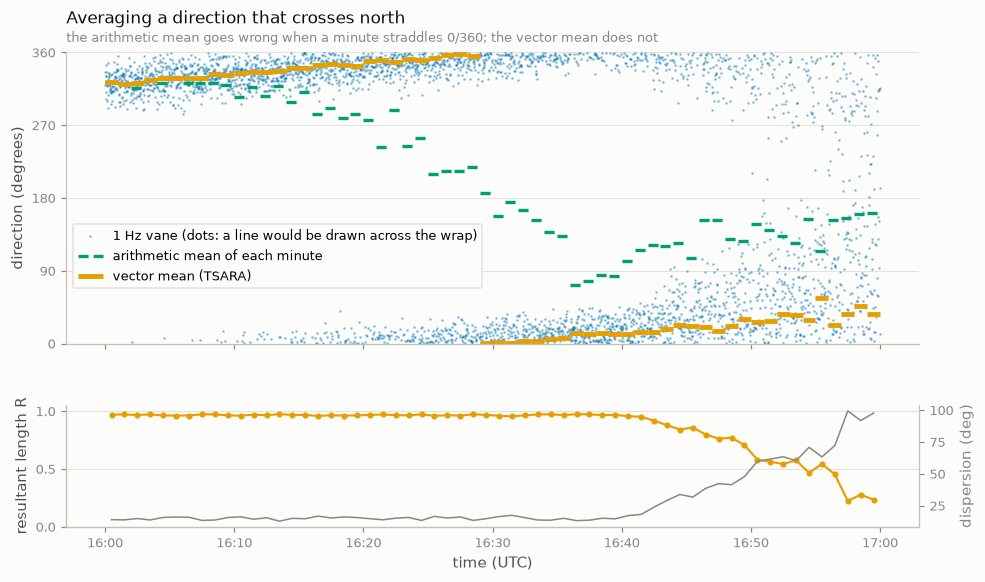

In [41]:
vane = vane_stream(
    seed=SEED,
    start_heading_deg=START_HEADING_DEG,
    veer_deg=VEER_DEG,
    steady_minutes=STEADY_MINUTES,
    steady_spread_deg=STEADY_SPREAD_DEG,
    final_spread_deg=FINAL_SPREAD_DEG,
)
minutes = uniform_cells(int(cells_of(vane).start_ns[0]), 60.0, 60)
on_minutes = bin_streams_onto_cells({"vane": vane}, minutes, ["wind_dir"])
print("columns a binned direction carries:", sorted(map(str, on_minutes.data_vars)), "\n")

# CHECK: direction and R per minute, from the definition.
reference_direction, reference_r = reference_vector_mean(
    cells_of(vane), vane["wind_dir"].values, minutes
)
check(
    "§10 every minute's vector-mean direction equals the loop from the definition",
    np.all(angular_difference(on_minutes["wind_dir"].values, reference_direction) < 1e-9),
)
check(
    "§10 every minute's R equals the loop's, and its dispersion is exactly sqrt(-2 ln R)",
    np.allclose(on_minutes["wind_dir_resultant_length"].values, reference_r, rtol=0, atol=1e-12)
    and np.allclose(
        on_minutes["wind_dir_dispersion"].values,
        np.degrees(np.sqrt(-2 * np.log(on_minutes["wind_dir_resultant_length"].values))),
        rtol=1e-9,
    ),
)

# Built BY HAND, not by TSARA: what an ordinary resample mean would report.
arithmetic = vane["wind_dir"].values.reshape(60, 60).mean(axis=1)
wrong = angular_difference(arithmetic, on_minutes["wind_dir"].values)
print(
    "\nminutes where the arithmetic mean is more than 45° from the vector mean: "
    f"{int((wrong > 45).sum())} of 60"
)

# Figure only from here.
m_start, m_stop = bounds_of(on_minutes)
fig, (ax, axr) = plt.subplots(
    2, 1, figsize=(10.0, 5.6), sharex=True, gridspec_kw={"height_ratios": [2.4, 1.0], "hspace": 0.3}
)
ax.plot(
    vane["time"].values,
    vane["wind_dir"].values,
    ".",
    color=C1,
    ms=1.6,
    alpha=0.35,
    label="1 Hz vane (dots: a line would be drawn across the wrap)",
)
ax.hlines(
    arithmetic,
    m_start,
    m_stop,
    color=C3,
    lw=2.2,
    ls=(0, (3, 1.5)),
    label="arithmetic mean of each minute",
)
ax.hlines(
    on_minutes["wind_dir"].values, m_start, m_stop, color=C2, lw=3.2, label="vector mean (TSARA)"
)
ax.set_ylim(0, 360)
ax.set_yticks([0, 90, 180, 270, 360])
finish(
    ax,
    "Averaging a direction that crosses north",
    "the arithmetic mean goes wrong when a minute straddles 0/360; the vector mean does not",
    "direction (degrees)",
)
ax.legend(
    loc="center left",
    bbox_to_anchor=(0.0, 0.3),
    fontsize=8.2,
    frameon=True,
    facecolor=SURFACE,
    edgecolor=GRID,
    framealpha=0.95,
)
axr.plot(
    on_minutes["time"].values, on_minutes["wind_dir_resultant_length"].values, "o-", color=C2, ms=3
)
axr.set_ylim(0, 1.05)
axd = axr.twinx()
axd.plot(
    on_minutes["time"].values, on_minutes["wind_dir_dispersion"].values, "-", color=MUTED, lw=1.0
)
axd.set_ylabel("dispersion (deg)", color=MUTED)
axd.tick_params(axis="y", colors=MUTED)
axd.spines["right"].set_visible(True)
finish(axr, None, None, "resultant length R", "time (UTC)")
hhmm(axr)
plt.show()

**What to read off the output.**

* **The green dashes** are what a plain resample would have stored, and they are
  not slightly wrong: once a minute holds readings on both sides of north, the
  average of 350s and 10s lands in the 180s. **The orange bars** follow the wind
  through north without noticing it.
* **The lower panel** is what a direction alone cannot tell you. While the wind
  is steady R sits near 0.97 and the dispersion near 15°: the direction means
  something. As it starts to tumble R falls and the dispersion climbs past 90°,
  until a minute's "mean direction" is a number that exists but describes very
  little. TSARA reports it anyway, beside the R that says so.

**One choice worth naming.** These are **unit-vector** means: every reading
counts equally whatever the wind speed. The other convention weights each
reading by speed, giving the direction the air actually moved in on average.
On a real drive the two differ by a couple of degrees in a typical minute and
by more when the wind is light and variable (`METHODS.md` §11.5). TSARA uses unit
vectors because the join does not know which speed belongs to which direction.
The speed-weighted direction is available by binning the wind components u and
v as ordinary scalars.

**Try it.**

* `START_HEADING_DEG = 180.0` and `VEER_DEG = 0.0`: a southerly. No minute's
  arithmetic mean is now more than 45° out, even while the wind tumbles. Wrapping
  at 0/360 only corrupts an arithmetic mean when readings cluster near north,
  which is exactly why it is easy to miss in testing and then bite on a northerly.
* `FINAL_SPREAD_DEG = 15.0`: the wind never tumbles, and R stays near 0.97 all
  hour.
* Add a set to `ANGLE_SETS`, such as `"opposite": [90.0, 270.0]`: exact
  cancellation, reported as `nan` with R = 0.

---
### How much R can say depends on how many readings made it

R is a statistic of a sample, and from a few readings it cannot get near zero
even when the directions carry no information at all. The dispersion is
understated for the same reason. That matters exactly where this phase creates
small samples: a 1 Hz wind averaged over a 15 s canister fill contributes about
fifteen readings.

**The check** uses an exact identity rather than a simulation of TSARA: for
directions with no preferred way, the average of R² is exactly 1/N.

In [42]:
# ---- PARAMETERS (section 10, small samples) --------------------------------
READINGS_PER_CELL = [2, 3, 4, 5, 7, 10, 15, 20, 30, 60, 120]
DRAWS = 3000  # random cells drawn at each N
TRUE_SPREADS_DEG = [20.0, 40.0]  # true scatter of the directions in the right panel

  ✔ §10 directionless readings: the mean of R² is 1/N, as it must be


N =   2: mean R of directionless readings 0.63; reported dispersion of a true 20°: 9.2°, a true 40°: 19.1°
N =   3: mean R of directionless readings 0.53; reported dispersion of a true 20°: 13.6°, a true 40°: 27.8°
N =   4: mean R of directionless readings 0.46; reported dispersion of a true 20°: 15.7°, a true 40°: 31.1°
N =   5: mean R of directionless readings 0.40; reported dispersion of a true 20°: 16.4°, a true 40°: 33.9°
N =   7: mean R of directionless readings 0.34; reported dispersion of a true 20°: 17.4°, a true 40°: 35.1°
N =  10: mean R of directionless readings 0.28; reported dispersion of a true 20°: 18.3°, a true 40°: 36.9°
N =  15: mean R of directionless readings 0.23; reported dispersion of a true 20°: 18.9°, a true 40°: 37.6°
N =  20: mean R of directionless readings 0.20; reported dispersion of a true 20°: 19.2°, a true 40°: 38.6°
N =  30: mean R of directionless readings 0.16; reported dispersion of a true 20°: 19.5°, a true 40°: 39.0°
N =  60: mean R of directionl

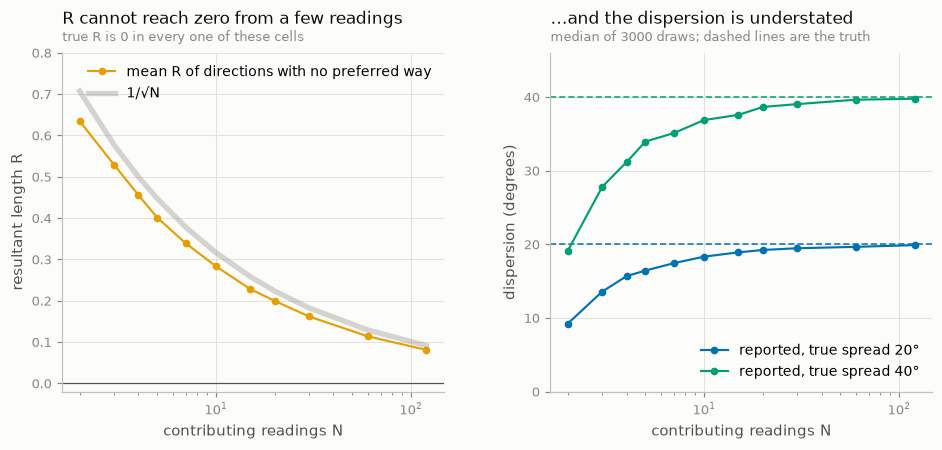

In [43]:
rng = np.random.default_rng(2)
mean_r, identity_ok = [], True
for n in READINGS_PER_CELL:
    r = np.array([circular_mean(rng.uniform(0, 360, n)).resultant_length for _ in range(DRAWS)])
    mean_r.append(r.mean())
    # E[R²] = 1/N exactly for directions with no preferred way; allow 4 standard errors.
    identity_ok &= abs((r**2).mean() - 1 / n) < 4 * (r**2).std(ddof=1) / np.sqrt(DRAWS)
check("§10 directionless readings: the mean of R² is 1/N, as it must be", identity_ok)
reported = {
    spread: [
        np.median([circular_mean(rng.normal(0, spread, n)).dispersion_deg for _ in range(DRAWS)])
        for n in READINGS_PER_CELL
    ]
    for spread in TRUE_SPREADS_DEG
}
for n, r in zip(READINGS_PER_CELL, mean_r):
    print(
        f"N = {n:>3}: mean R of directionless readings {r:.2f}; reported dispersion of "
        + ", ".join(
            f"a true {s:g}°: {reported[s][READINGS_PER_CELL.index(n)]:.1f}°"
            for s in TRUE_SPREADS_DEG
        )
    )

# Figure only from here.
fig, (axl, axq) = plt.subplots(1, 2, figsize=(10.2, 4.0), gridspec_kw={"wspace": 0.28})
axl.semilogx(
    READINGS_PER_CELL,
    mean_r,
    "o-",
    color=C2,
    ms=4,
    label="mean R of directions with no preferred way",
)
axl.semilogx(
    READINGS_PER_CELL,
    1 / np.sqrt(READINGS_PER_CELL),
    "-",
    color=MUTED,
    lw=3.5,
    alpha=0.35,
    label="1/√N",
)
axl.axhline(0, color=INK2, lw=0.8)
axl.set_ylim(-0.02, 0.8)
finish(
    axl,
    "R cannot reach zero from a few readings",
    "true R is 0 in every one of these cells",
    "resultant length R",
    "contributing readings N",
    legend=True,
    loc="upper right",
    grid_axis="both",
)
for spread, colour in zip(TRUE_SPREADS_DEG, (C1, C3)):
    axq.semilogx(
        READINGS_PER_CELL,
        reported[spread],
        "o-",
        color=colour,
        ms=4,
        label=f"reported, true spread {spread:g}°",
    )
    axq.axhline(spread, color=colour, lw=1.0, ls=(0, (4, 2)))
axq.set_ylim(0, 1.15 * max(TRUE_SPREADS_DEG))
finish(
    axq,
    "…and the dispersion is understated",
    f"median of {DRAWS} draws; dashed lines are the truth",
    "dispersion (degrees)",
    "contributing readings N",
    legend=True,
    loc="lower right",
    grid_axis="both",
)
plt.show()

Both panels converge on the truth, and by sixty readings the difference is a
degree or two. Below ten it is not small: five readings of a wind whose true
spread is 40° report about 34°, and five random readings report an R near 0.4,
which on its own would read as "moderately steady".

TSARA does not correct for this. A correction would need an assumption about the
distribution of directions, and `n_readings` travels with every binned direction,
so a reader can see when R rests on a handful of readings. It is a caveat worth
knowing rather than a defect.

---
### A declared conversion can carry a direction across north

Ingestion converts units before QA/QC, deliberately: a range bound is a physical
statement in canonical units. For a direction the commonest conversion is an
offset, a magnetic bearing to a true one, and the most natural QA/QC rule is a
range of 0 to 360. Here is a vane straddling magnetic north, corrected by a
declination, through a real manifest and real ingestion.

In [44]:
# ---- PARAMETERS (section 10, magnetic to true) -----------------------------
DECLINATION_DEG = 10.3  # added to every magnetic reading (Salt Lake City is about +10.3°)
MAGNETIC_READINGS = [352.0, 355.0, 358.0, 1.0, 3.0, 350.0, 357.0, 359.0]

In [45]:
folder = WORK / "vane"
folder.mkdir(exist_ok=True)
stamps = pd.date_range("2026-01-19 20:00:00", periods=len(MAGNETIC_READINGS), freq="1s")
pd.DataFrame({"time": stamps.strftime("%Y-%m-%d %H:%M:%S"), "wdir_mag": MAGNETIC_READINGS}).to_csv(
    folder / "met.csv", index=False
)
(folder / "manifest.yaml").write_text(f"""
name: declination_demo
base_path: {folder}
platform: {{kind: stationary, latitude: 40.76, longitude: -111.89}}
instruments:
  vane:
    loader:
      format: csv
      path_template: "met.csv"
      time: {{column: time, format: "%Y-%m-%d %H:%M:%S", timezone: UTC}}
    variables:
      wind_dir:
        column: wdir_mag
        role: met
        units: degrees
        circular: true
        convert:
          from_unit: degrees_magnetic
          to_unit: degrees
          scale: 1.0
          offset: {DECLINATION_DEG}
        qaqc:
          - {{kind: range, min: 0, max: 360}}
""")
corrected = ingest_campaign(load_manifest(folder / "manifest.yaml"))["vane"]
print("magnetic, as written :", MAGNETIC_READINGS)
print("true, as ingested    :", corrected["wind_dir"].values.round(1).tolist())
print("masked by the range rule:", corrected["wind_dir"].attrs["masked_fraction"])
check(
    "§10 a declination offset wraps every reading onto [0, 360) and none is masked",
    np.allclose(
        corrected["wind_dir"].values,
        (np.array(MAGNETIC_READINGS) + DECLINATION_DEG) % 360.0,
        atol=1e-9,
    )
    and corrected["wind_dir"].attrs["masked_fraction"] == 0,
)

magnetic, as written : [352.0, 355.0, 358.0, 1.0, 3.0, 350.0, 357.0, 359.0]
true, as ingested    : [2.3, 5.3, 8.3, 11.3, 13.3, 0.3, 7.3, 9.3]
masked by the range rule: 0.0
  ✔ §10 a declination offset wraps every reading onto [0, 360) and none is masked


Every reading arrives, on one turn: 352° magnetic is 2.3° true, not 362.3°.

Before walkthrough stage 4 of this phase, ingestion converted and then applied
QA/QC with no wrap in between, and this same manifest came back with every
reading within 10.3° west of north masked by the range rule. That is not a
random fraction of a record but a whole sector of the wind rose, and nothing
about the stream said so. A variable declaring `circular: true` is now wrapped
between conversion and QA/QC, which is exact and moves no direction. The
permitted 2026 archive carries magnetic and true directions side by side, so the
conversion is a real one.

**Try it.** `DECLINATION_DEG = -12.0`: readings just east of north move west
across it, and still none is lost.

---
### A direction keeps its columns whichever path it takes

A stream already on the target cells skips the averaging (§2). The columns that
travel *with* the value must not skip anything, or a product's columns would
depend on whether a stream happened to share the target's cells, which is
exactly what a sweep over grid period changes. The check compares the two paths
on the same rows: the vane's own cells (pass-through), and the same cells less
the last one (the general path).

In [46]:
vane = vane_stream()
own = cells_of(vane)
all_but_last = CellBounds(start_ns=own.start_ns[:-1], stop_ns=own.stop_ns[:-1])
passed = bin_streams_onto_cells({"vane": vane}, own, ["wind_dir"])
binned = bin_streams_onto_cells({"vane": vane}, all_but_last, ["wind_dir"])
for path_name, product in (("pass-through", passed), ("general path", binned)):
    print(
        f"{path_name:12} columns: {sorted(map(str, product.data_vars))}   "
        f"tsara_binned={product['wind_dir'].attrs['tsara_binned']}"
    )
rows = slice(0, len(all_but_last))
same = sorted(map(str, passed.data_vars)) == sorted(map(str, binned.data_vars))
for name in ("n_readings_wind_dir", "coverage_wind_dir", "borrowed_wind_dir"):
    same &= np.array_equal(passed[name].values[rows], binned[name].values)
same &= np.all(
    angular_difference(passed["wind_dir"].values[rows], binned["wind_dir"].values) < 1e-9
)
same &= np.allclose(
    passed["wind_dir_resultant_length"].values[rows],
    binned["wind_dir_resultant_length"].values,
    atol=1e-12,
)
# sqrt(-2 ln R) turns one rounding step below R = 1 into about 1e-6 degrees.
same &= np.allclose(
    passed["wind_dir_dispersion"].values[rows], binned["wind_dir_dispersion"].values, atol=1e-5
)
check("§10 a direction on its own cells gets the same columns and values as one binned", same)

pass-through columns: ['borrowed_wind_dir', 'coverage_wind_dir', 'n_readings_wind_dir', 'wind_dir', 'wind_dir_dispersion', 'wind_dir_resultant_length']   tsara_binned=0
general path columns: ['borrowed_wind_dir', 'coverage_wind_dir', 'n_readings_wind_dir', 'wind_dir', 'wind_dir_dispersion', 'wind_dir_resultant_length']   tsara_binned=1
  ✔ §10 a direction on its own cells gets the same columns and values as one binned


---
## 11. The one interpolation, and what it costs

**The question.** Everything so far is averaging. When does TSARA *interpolate*,
evaluating a field between two samples at an instant nobody measured?

**Only here** (`src/tsara/align/auxiliary.py`, the only module in TSARA that
interpolates). A concentration inside a plume is not a smooth field, so a gas is
never interpolated (property 3). Position and ambient meteorology change
smoothly on sampling timescales, so a value between two fixes is a reasonable
estimate **if the fixes are close enough together**. Two guards, both refusals:

* **what**: a variable declaring `role: gas` is refused, and so is one declaring
  no role, since its smoothness is unknown;
* **how far**: a target whose two bracketing samples are further apart than
  `max_interp_gap` gets `nan`, never a straight line across the gap. Nothing is
  extrapolated past either end of a record.

**The realistic use is a moving platform.** Ingestion attaches a stationary
site's single position, which is exact, but leaves a moving platform's track
alone: putting GPS onto a gas instrument's clock is interpolation, and its guard
belongs here. `attach_positions` does that join.

**The campaign** (`drive_campaign`). A van drives a wandering route for thirty
minutes. The generator records its position every second, which is the true
track. The raw files are written and ingested as a real archive would be, then
the GPS record is **thinned** to one fix every few seconds with an outage, the
shape a real low-rate GPS log has.

**How it is checked.** Positions against an interpolation written out in a loop
from the kept fixes, with its own gap rule; and against the true 1 s track, to
measure what the guard's choice costs in metres.

In [47]:
# ---- PARAMETERS (section 11) ------------------------------------------------
SEED = 3
SPEED_M_S = 13.0  # van speed
HEADING_VOLATILITY = 0.1  # how much the route turns (higher: twistier)
GPS_EVERY_S = 10  # keep one GPS fix every this many seconds
OUTAGE_START_S = 700  # a GPS outage starting this far into the drive ...
OUTAGE_LENGTH_S = 40  # ... lasting this long
MAX_INTERP_GAP = "10s"  # the longest gap between fixes that may be bridged

In [48]:
start_section("§11")
drive = drive_campaign(seed=SEED, speed_m_s=SPEED_M_S, heading_volatility=HEADING_VOLATILITY)
drive_streams = ingest_campaign(load_manifest(export_raw(drive, WORK / "drive")))
analyzer = drive_streams["van_analyzer"]
print("ingested analyzer coordinates:", sorted(map(str, analyzer.coords)), "(no position yet)")
print("its GPS binding              :", analyzer.attrs["platform_gps_instrument"])

gps_full = drive_streams["gps"]
fix_seconds = (cells_of(gps_full).midpoint_ns - cells_of(gps_full).midpoint_ns[0]) / SECOND
keep = (np.round(fix_seconds) % GPS_EVERY_S == 0) & ~(
    (fix_seconds >= OUTAGE_START_S) & (fix_seconds < OUTAGE_START_S + OUTAGE_LENGTH_S)
)
thinned = gps_full.isel(time=np.flatnonzero(keep))

# THE JOIN.
placed = attach_positions(
    analyzer, {**drive_streams, "gps": thinned}, max_interp_gap=MAX_INTERP_GAP
)

# CHECK: the same positions from a loop over the kept fixes.
fix_t = cells_of(thinned).midpoint_ns
guard_ns = pd.Timedelta(MAX_INTERP_GAP).value
targets = cells_of(analyzer).midpoint_ns
expected = {"latitude": np.full(targets.size, np.nan), "longitude": np.full(targets.size, np.nan)}
refused = 0
for k, t in enumerate(targets):
    before, after = np.flatnonzero(fix_t <= t), np.flatnonzero(fix_t >= t)
    if before.size == 0 or after.size == 0:
        continue  # outside the record: never extrapolated
    i, j = before[-1], after[0]
    if i != j and fix_t[j] - fix_t[i] > guard_ns:
        refused += 1  # bracketing fixes too far apart
        continue
    share = 0.0 if i == j else (t - fix_t[i]) / (fix_t[j] - fix_t[i])
    for name in expected:
        values = thinned[name].values
        expected[name][k] = values[i] + share * (values[j] - values[i])
check(
    "§11 every attached position equals the interpolation written out from the kept fixes",
    all(
        np.allclose(placed[name].values, expected[name], rtol=0, atol=1e-9, equal_nan=True)
        for name in expected
    ),
)
check(
    "§11 exactly the cells whose bracketing fixes are too far apart were refused",
    placed["latitude"].attrs["tsara_interp_gap_masked"] == refused,
    f"{refused} refused",
)

# How wrong the interpolated positions are, against the true 1 s track.
metres_per_degree = 111_320.0
truth = drive.streams["van_analyzer"].sel(time=placed["time"])
error_m = np.hypot(
    (placed["latitude"].values - truth["latitude"].values) * metres_per_degree,
    (placed["longitude"].values - truth["longitude"].values)
    * metres_per_degree
    * np.cos(np.radians(40.76)),
)
positioned = np.isfinite(error_m)
print(
    f"\ncells positioned: {positioned.sum()} of {positioned.size}; "
    f"refused across the outage: {refused}"
)
print(
    f"error against the true track: median {np.median(error_m[positioned]):.1f} m, "
    f"90th percentile {np.percentile(error_m[positioned], 90):.1f} m, "
    f"largest {error_m[positioned].max():.1f} m"
)

ingested analyzer coordinates: ['time', 'time_bnds'] (no position yet)
its GPS binding              : gps
  ✔ §11 every attached position equals the interpolation written out from the kept fixes
  ✔ §11 exactly the cells whose bracketing fixes are too far apart were refused   [49 refused]

cells positioned: 1742 of 1800; refused across the outage: 49
error against the true track: median 2.5 m, 90th percentile 7.2 m, largest 18.3 m


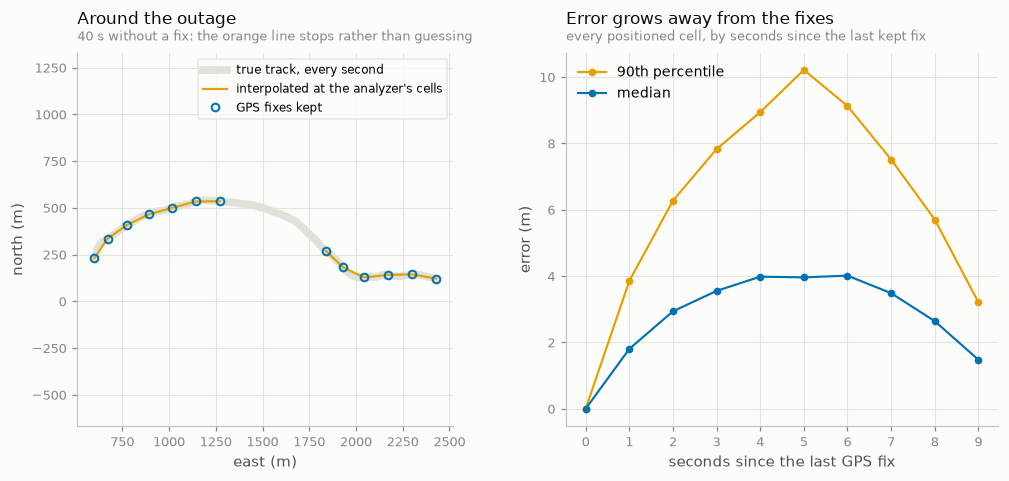

In [49]:
# Figure only.
def east(lon):
    """Metres east of the drive's start longitude."""
    return (np.asarray(lon) + 111.89) * metres_per_degree * np.cos(np.radians(40.76))


def north(lat):
    """Metres north of the drive's start latitude."""
    return (np.asarray(lat) - 40.76) * metres_per_degree


outage_at = pd.Timestamp(gps_full["time"].values[0]) + pd.Timedelta(seconds=OUTAGE_START_S)
around = (outage_at - pd.Timedelta("60s"), outage_at + pd.Timedelta(seconds=OUTAGE_LENGTH_S + 60))
truth_near, placed_near, fixes_near = (
    s.sel(time=slice(*around)) for s in (drive.streams["gps"], placed, thinned)
)
since_fix = np.round(
    (targets - fix_t[np.clip(np.searchsorted(fix_t, targets, side="right") - 1, 0, None)]) / SECOND
).astype(int)
offsets = np.arange(GPS_EVERY_S)
by_offset = [error_m[positioned & (since_fix == k)] for k in offsets]

fig = plt.figure(figsize=(10.8, 4.4))
gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.15], wspace=0.28)
axm, axe = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])
axm.plot(
    east(truth_near["longitude"]),
    north(truth_near["latitude"]),
    color=GRID,
    lw=5.0,
    label="true track, every second",
)
axm.plot(
    east(placed_near["longitude"]),
    north(placed_near["latitude"]),
    color=C2,
    lw=1.4,
    label="interpolated at the analyzer's cells",
)
axm.plot(
    east(fixes_near["longitude"]),
    north(fixes_near["latitude"]),
    "o",
    color=C1,
    ms=5,
    mfc="none",
    mew=1.3,
    label="GPS fixes kept",
)
axm.set_aspect("equal", adjustable="datalim")
finish(
    axm,
    "Around the outage",
    f"{OUTAGE_LENGTH_S} s without a fix: the orange line stops rather than guessing",
    "north (m)",
    "east (m)",
    grid_axis="both",
)
axm.legend(fontsize=7.8, loc="best", frameon=True, facecolor=SURFACE, edgecolor=GRID)
axe.plot(
    offsets,
    [np.percentile(e, 90) if e.size else np.nan for e in by_offset],
    "o-",
    color=C2,
    ms=4,
    label="90th percentile",
)
axe.plot(
    offsets,
    [np.median(e) if e.size else np.nan for e in by_offset],
    "o-",
    color=C1,
    ms=4,
    label="median",
)
axe.set_xticks(offsets)
finish(
    axe,
    "Error grows away from the fixes",
    "every positioned cell, by seconds since the last kept fix",
    "error (m)",
    "seconds since the last GPS fix",
    legend=True,
    loc="upper left",
    grid_axis="both",
)
plt.show()

**What to read off the output.**

* **The ✔ lines**: every position is the straight-line interpolation between
  the two kept fixes around it, and exactly the cells inside the outage were
  refused.
* **Left panel.** The orange line follows the grey one and then stops. The
  outage is not drawn, because a straight line across it would be a guess, and
  the analyzer cells inside it carry no position.
* **Right panel.** A cell that falls on a kept fix is exact; the further it sits
  from one, the more time the van has had to turn away from the straight chord
  between fixes, and the error peaks mid-way between them.

That error is the whole content of `max_interp_gap`: how far a platform may
stray from a straight line between fixes. Measured on real city driving at a
median 13 m/s, bridging 10 s gaps costs about 10 m at the 90th percentile, 50 s
gaps about 110 m, and 60 s gaps about 140 m (`METHODS.md` §11.6). Whether 100 m
is acceptable depends on what the position is for, which is why it is a setting
rather than a constant.

**Try it.**

* `MAX_INTERP_GAP = "60s"`: the outage is bridged, no cell is refused, and the
  largest error grows, since the straight line now crosses fifty seconds of turns.
* `GPS_EVERY_S = 1`: every analyzer cell now lands exactly on a fix, so every
  position is measured rather than interpolated and the error is zero. The
  outage is still refused.
* `HEADING_VOLATILITY = 0.5`: a twistier route. The same 10 s spacing now costs
  more metres.

---
### When a record's own spacing is wider than the guard

In [50]:
# ---- PARAMETERS (section 11, a sparse GPS log) -----------------------------
SPARSE_EVERY_S = 50  # one fix every this many seconds
SPARSE_GUARD = "10s"

In [51]:
drive_streams = ingest_campaign(load_manifest(export_raw(drive_campaign(), WORK / "drive")))
sparse_gps = drive_streams["gps"].isel(time=slice(None, None, SPARSE_EVERY_S))
field = interpolate_onto_cells(
    {**drive_streams, "gps": sparse_gps},
    ("gps", "latitude"),
    cells_of(drive_streams["van_analyzer"]),
    max_interp_gap=SPARSE_GUARD,
)
print(
    f"a fix every {SPARSE_EVERY_S} s, guard {SPARSE_GUARD}: {field.n_exact} exact, "
    f"{field.n_interpolated} interpolated, "
    f"{field.n_gap_masked} refused, {field.n_outside} outside the record"
)
guard_s = pd.Timedelta(SPARSE_GUARD).total_seconds()
check(
    "§11 nothing is interpolated exactly when every gap is longer than the guard",
    (field.n_interpolated == 0) == (SPARSE_EVERY_S > guard_s),
)

2026-09-23 12:22:15 | WARNING  | tsara.align.auxiliary | 'latitude' on 'gps' is sampled every 50 s (median), longer than max_interp_gap=10s, so the guard refused 1715 of 1800 cells and only the 36 landing exactly on a sample kept a value. That is the guard working as configured. If bridging 50 s is acceptable for this field, raise max_interp_gap; METHODS §11.6 tabulates what that costs for a moving platform's position.


a fix every 50 s, guard 10s: 36 exact, 0 interpolated, 1715 refused, 49 outside the record
  ✔ §11 nothing is interpolated exactly when every gap is longer than the guard


Almost every cell is refused, which is correct: a 10 s guard says no gap wider
than 10 s may be bridged, and every gap here is 50 s. What survives is worth a
second look: the few cells whose midpoints land *exactly* on a fix keep a
position, because those values were measured rather than interpolated. The
result is a record positioned at one cell in fifty, which at a glance looks like
a join that worked.

So TSARA now warns, as printed above, whenever a record's own median spacing is
longer than its guard. Real archives have exactly this shape: seven of the
University of Wyoming's 2024 GPS logs record a fix every 50 s (notebook 04b
shows them). The fix the warning suggests is deliberately not automatic,
because widening the guard is a decision about how wrong a position may be.

**Try it.** `SPARSE_GUARD = "60s"`: every cell is interpolated, and the warning
goes away.

---
### An instant is not an interval

Interpolation evaluates a field at a cell's **midpoint**. For a sparse record
that is the only option: a fix every 10 s cannot fill 1 s cells by averaging.
For a *dense* record placed on *wider* cells it throws most of the record away
and reports one instant for a value that describes an interval. Section 10's
vane shows the difference, on cells the width of a canister fill.

In [52]:
# ---- PARAMETERS (section 11, instant against interval) ---------------------
FILL_WIDTH_S = 15

In [53]:
vane = vane_stream()
fills = uniform_cells(int(cells_of(vane).start_ns[0]), FILL_WIDTH_S, 3600 // FILL_WIDTH_S)
at_midpoint = interpolate_onto_cells({"vane": vane}, "wind_dir", fills, max_interp_gap="10s")
averaged = bin_streams_onto_cells({"vane": vane}, fills, ["wind_dir"])
apart = angular_difference(at_midpoint.values, averaged["wind_dir"].values)
steady = averaged["wind_dir_resultant_length"].values > 0.9
print(
    f"{FILL_WIDTH_S} s cells, midpoint instant against the cell's vector mean: "
    f"median {np.nanmedian(apart):.1f}°, "
    f"90th percentile {np.nanpercentile(apart, 90):.1f}°, largest {np.nanmax(apart):.1f}°"
)
print(
    f"  where the wind was steady (R > 0.9): median {np.nanmedian(apart[steady]):.1f}°; "
    f"where it was not: median {np.nanmedian(apart[~steady]):.1f}°"
)

print()
for label, streams11, name in (
    ("a gas (role: gas)", canister_campaign(duration="1h").streams, "benzene"),
    (
        "a variable that declares no role",
        {"logger": make_stream(fills.start_ns, fills.stop_ns, {"noy": np.ones(len(fills))})},
        "noy",
    ),
):
    try:
        interpolate_onto_cells(streams11, name, fills)
        was_refused = False
    except TsaraAlignError as refusal:
        was_refused = True
        print(f"{label}: {str(refusal).split('. ')[0]}.")
    check(f"§11 interpolation refuses {label}", was_refused)

15 s cells, midpoint instant against the cell's vector mean: median 12.3°, 90th percentile 53.3°, largest 161.1°
  where the wind was steady (R > 0.9): median 9.2°; where it was not: median 36.6°

a gas (role: gas): 'benzene' on 'iwas' has role 'gas' and will not be interpolated.
  ✔ §11 interpolation refuses a gas (role: gas)
a variable that declares no role: 'noy' on 'logger' declares no role, so TSARA cannot tell whether interpolating it is physically justified.
  ✔ §11 interpolation refuses a variable that declares no role


Even while the wind is steady the instant sits several degrees from the average,
which is simply the scatter of the one or two readings an instant is built from;
once the wind tumbles the difference is several times that, and the worst cell
is off by more than a right angle. Only the average comes with an R saying how
much the direction means.

So the rule of thumb is: **bin a field that is denser than the cells;
interpolate one that is sparser.** The output grid follows it: met is binned onto
the grid, never interpolated. `attach_positions` interpolates because a GPS
record is often the sparser one, and because for a position the instant costs
little: on a real drive a canister fill's midpoint position is within a few
metres of its mean position (`METHODS.md` §11.6). And the last two lines are the
first guard: a gas, or anything whose smoothness is unknown, is refused.

**Try it.** `FILL_WIDTH_S = 1`: cells identical to the vane's own. The instant
at each midpoint is a reading, the average of one reading is that reading, and
the two agree to 0°.

---
## 12. The campaign grid: the matrix a receptor model reads

**The question.** Pairing puts two species on the clock that suits *them*. A
receptor model such as PMF needs every chosen variable on **one** uniform set of
cells, a `(time × variable)` matrix. How is that built, and what can go wrong?

**What TSARA does** (`build_output_grid` in `src/tsara/align/grid.py`). The same
one operation with a different target: uniform cells of a chosen period. There
is deliberately **no "PMF matrix" object**. Which columns go in (raw species,
the enhancements Phase 5 will compute, met) is a scientific choice, so a matrix
is simply this call with those columns named. That is property 1 again, and it
is what lets a parameter sweep change the columns without changing any code.

**The one rule it adds.** No selected reading may be **twice as wide as a grid
cell it touches** (§4's rule, applied to the grid's actual cells), unless
`finer_support="allow"` asks for the copies. So *which variables are selected*
is a real lever: leaving out a slow instrument allows a finer grid.

**How it is checked.** Each request's verdict against that rule written as
arithmetic; the gridded values against `reference_bin`; and the readings behind
each column against a count made independently from the fill intervals.

In [54]:
# ---- PARAMETERS (section 12) ------------------------------------------------
SEED = 21
FILL_WIDTH = "15s"  # the canisters' fill duration
GRID_REQUESTS = [  # (period, variables to grid)
    ("5s", ["ch4", "benzene"]),
    ("7.5s", ["ch4", "benzene"]),
    ("8s", ["ch4", "benzene"]),
    ("5s", ["ch4"]),
    ("60s", ["ch4", "benzene"]),
]

In [55]:
start_section("§12")
canister = canister_campaign(seed=SEED, fill_width=FILL_WIDTH)
streams = canister.streams
widest = {
    "ch4": float(cells_of(streams["methane_analyzer"]).width_ns.max()) / SECOND,
    "benzene": float(cells_of(streams["iwas"]).width_ns.max()) / SECOND,
}

verdicts_ok = True
print(f"{'period':>7} {'variables':20} {'TSARA':>8} {'rule':>7}  rows holding each")
for freq, chosen in GRID_REQUESTS:
    period_s = pd.Timedelta(freq).total_seconds()
    rule_refuses = any(
        widest[v] >= 2 * period_s for v in chosen
    )  # a reading twice as wide as a cell
    try:
        grid = build_output_grid(streams, OutputGridConfig(freq=freq), chosen)
        shares = ", ".join(f"{v} {(grid[f'n_readings_{v}'].values > 0).mean():.1%}" for v in chosen)
        tsara_refuses = False
    except TsaraAlignError:
        tsara_refuses, shares = True, "-"
    verdicts_ok &= tsara_refuses == rule_refuses
    print(
        f"{freq:>7} {', '.join(chosen):20} {'refused' if tsara_refuses else 'built':>8} "
        f"{'refuse' if rule_refuses else 'allow':>7}  {shares}"
    )
check(
    "§12 the grid refuses exactly the periods at which a selected reading is twice as wide "
    "as a cell",
    verdicts_ok,
)

# The 60 s matrix, checked column by column against the definition.
grid60 = build_output_grid(streams, OutputGridConfig(freq="60s"), ["ch4", "benzene"])
rows60 = cells_of(grid60)
values_ok = True
for variable, instrument in (("ch4", "methane_analyzer"), ("benzene", "iwas")):
    reference = reference_bin(
        cells_of(streams[instrument]), streams[instrument][variable].values, rows60
    )
    values_ok &= np.allclose(
        grid60[variable].values, reference["value"], rtol=1e-12, atol=0, equal_nan=True
    )
    values_ok &= np.allclose(
        grid60[f"coverage_{variable}"].values, reference["coverage"], rtol=1e-12, atol=0
    )
check(
    "§12 every row of the 60 s matrix equals the loop from the definition, for both columns",
    values_ok,
)

# How many rows each fill lands in, counted from the fill intervals alone:
# a fill occupies every grid row its [start, stop) interval reaches into.
fills = cells_of(streams["iwas"])
period_ns = 60 * SECOND
first_row = (fills.start_ns - rows60.start_ns[0]) // period_ns
last_row = (fills.stop_ns - 1 - rows60.start_ns[0]) // period_ns
rows_per_fill = (last_row - first_row + 1).astype(int)
occupied = int((grid60["n_readings_benzene"].values > 0).sum())
print(
    f"\n{len(fills)} fills: {int((rows_per_fill == 1).sum())} in one row, "
    f"{int((rows_per_fill == 2).sum())} in two; {occupied} rows hold benzene; "
    f"tsara_n_readings = {grid60['benzene'].attrs['tsara_n_readings']}; "
    f"label {grid60['benzene'].attrs['tsara_support_transform']!r}, "
    f"borrowed share {grid60['benzene'].attrs['tsara_borrowed_share']:.3f}"
)
check(
    "§12 rows holding benzene = the rows the fills reach into, counted from the intervals",
    occupied == int(rows_per_fill.sum()),
)
check(
    "§12 tsara_n_readings = the number of distinct fills behind the column",
    grid60["benzene"].attrs["tsara_n_readings"] == len(fills),
)

2026-09-23 12:22:15 | WARNING  | tsara.align.binning | 1 column(s) of this join rest on air the readings did not measure over the cells reported (METHODS §11.2.4): 'benzene' (narrowed, readings up to 1.88x a cell; 157 rows from 55 readings; borrowed share 0.57). A reading wider than the cell it fills has its value stand for a shorter interval than it measured; rows outnumbering readings means some reading sits in more than one row, which a fit or receptor model treating rows as independent counts more than once. Each column records tsara_support_transform, tsara_width_ratio_max, tsara_borrowed_share and tsara_n_readings, and carries the share borrowed per cell in borrowed_<name>.


2026-09-23 12:22:15 | WARNING  | tsara.align.binning | 1 column(s) of this join rest on air the readings did not measure over the cells reported (METHODS §11.2.4): 'benzene' (69 rows from 55 readings; borrowed share 0.09). A reading wider than the cell it fills has its value stand for a shorter interval than it measured; rows outnumbering readings means some reading sits in more than one row, which a fit or receptor model treating rows as independent counts more than once. Each column records tsara_support_transform, tsara_width_ratio_max, tsara_borrowed_share and tsara_n_readings, and carries the share borrowed per cell in borrowed_<name>.


2026-09-23 12:22:15 | WARNING  | tsara.align.binning | 1 column(s) of this join rest on air the readings did not measure over the cells reported (METHODS §11.2.4): 'benzene' (69 rows from 55 readings; borrowed share 0.09). A reading wider than the cell it fills has its value stand for a shorter interval than it measured; rows outnumbering readings means some reading sits in more than one row, which a fit or receptor model treating rows as independent counts more than once. Each column records tsara_support_transform, tsara_width_ratio_max, tsara_borrowed_share and tsara_n_readings, and carries the share borrowed per cell in borrowed_<name>.


 period variables               TSARA    rule  rows holding each
     5s ch4, benzene          refused  refuse  -
   7.5s ch4, benzene          refused  refuse  -
     8s ch4, benzene            built   allow  ch4 100.0%, benzene 4.4%
     5s ch4                     built   allow  ch4 100.0%
    60s ch4, benzene            built   allow  ch4 100.0%, benzene 14.3%
  ✔ §12 the grid refuses exactly the periods at which a selected reading is twice as wide as a cell


  ✔ §12 every row of the 60 s matrix equals the loop from the definition, for both columns

55 fills: 41 in one row, 14 in two; 69 rows hold benzene; tsara_n_readings = 55; label 'straddled', borrowed share 0.086
  ✔ §12 rows holding benzene = the rows the fills reach into, counted from the intervals
  ✔ §12 tsara_n_readings = the number of distinct fills behind the column


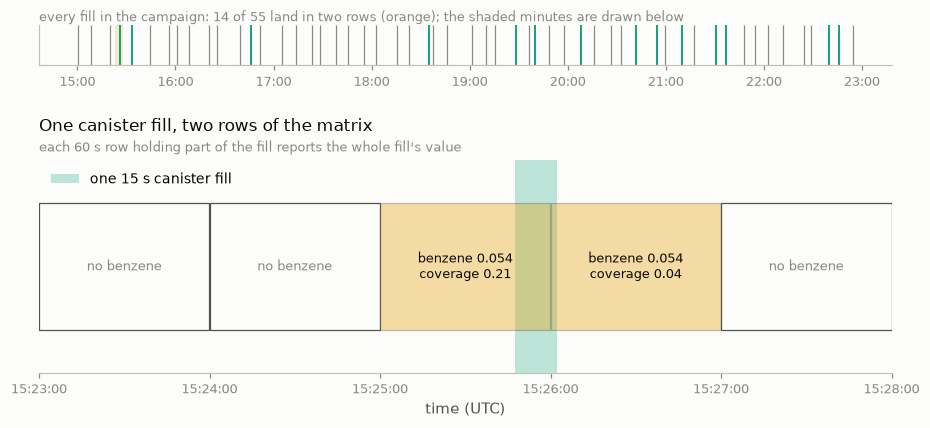

In [56]:
# Figure only: the first fill that straddles a minute boundary, and the rows around it.
k = int(np.flatnonzero(rows_per_fill == 2)[0])
middle = pd.Timestamp(int(fills.midpoint_ns[k]))
view = grid60.sel(
    time=slice(
        middle.floor("min") - pd.Timedelta("90s"), middle.floor("min") + pd.Timedelta("150s")
    )
)
r0, r1 = bounds_of(view)
fig, (axo, ax) = plt.subplots(
    2, 1, figsize=(10.0, 4.1), gridspec_kw={"height_ratios": [0.45, 2.4], "hspace": 0.75}
)
# An overview strip: every fill in the campaign, and where the four minutes
# below sit among them. One fill in four crosses a boundary this way.
axo.vlines(pd.to_datetime(fills.midpoint_ns[rows_per_fill == 1]), 0, 1, color=MUTED, lw=0.8)
axo.vlines(pd.to_datetime(fills.midpoint_ns[rows_per_fill == 2]), 0, 1, color=C3, lw=1.2)
axo.axvspan(
    pd.Timestamp(int(r0[0])) if not hasattr(r0[0], "to_pydatetime") else r0[0],
    pd.Timestamp(int(r1[-1])) if not hasattr(r1[-1], "to_pydatetime") else r1[-1],
    color=C2,
    alpha=0.20,
    lw=0,
)
axo.set_ylim(0, 1)
axo.set_yticks([])
straddling = int((rows_per_fill == 2).sum())
finish(
    axo,
    None,
    f"every fill in the campaign: {straddling} of {len(rows_per_fill)} land in "
    "two rows (orange); the shaded minutes are drawn below",
    None,
    None,
    grid_axis=None,
)
hhmm(axo)
ax.axvspan(
    pd.Timestamp(int(fills.start_ns[k])),
    pd.Timestamp(int(fills.stop_ns[k])),
    color=C3,
    alpha=0.25,
    lw=0,
    label="one 15 s canister fill",
)
for x0, x1, value, cov in zip(r0, r1, view["benzene"].values, view["coverage_benzene"].values):
    held = np.isfinite(value)
    ax.add_patch(
        plt.Rectangle(
            (mdates.date2num(x0), 0.2),
            mdates.date2num(x1) - mdates.date2num(x0),
            0.6,
            facecolor=C2 if held else "none",
            alpha=0.35 if held else 1.0,
            edgecolor=INK2,
            lw=0.8,
        )
    )
    ax.text(
        x0 + (x1 - x0) / 2,
        0.5,
        f"benzene {value:.3f}\ncoverage {cov:.2f}" if held else "no benzene",
        ha="center",
        va="center",
        fontsize=8.5,
        color=INK if held else MUTED,
    )
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.set_xlim(r0[0], r1[-1])
finish(
    ax,
    "One canister fill, two rows of the matrix",
    "each 60 s row holding part of the fill reports the whole fill's value",
    None,
    "time (UTC)",
    legend=True,
    loc="upper left",
    grid_axis=None,
)
hhmm(ax, "%H:%M:%S")
plt.show()

**What to read off the output.**

* **The verdicts.** A 15 s fill is exactly twice as wide as a 7.5 s cell, so
  7.5 s is refused and 8 s is built -- labelled `narrowed`, ratio 1.875, since
  each fill is then wider than the cells it fills. Drop benzene from the
  selection and 5 s is built.
* **Coverage of the matrix.** On the 60 s grid every row has methane and only
  about one row in seven has benzene. That is honest: the sampler filled a
  canister every nine minutes or so. It is also why a two-species ratio uses a
  pair clock (§8) rather than this product.
* **The figure: one fill in two rows.** A fill that straddles a minute boundary
  contributes to both minutes. Each row reports that fill's benzene (the only
  benzene either minute has) and a coverage saying how little of the minute it
  saw. Nothing is fabricated, but the matrix holds **one measurement in two
  rows**, and a model that treats rows as independent counts that canister
  twice. Section 9 showed what counting a reading twice does to an uncertainty.

Refusing that would throw fills away, so the join **records** it instead. Every
column carries `tsara_n_readings`, the distinct readings behind it, beside its
label, ratio and borrowed share (§4), and the warning printed above names any
column holding values in more rows than it has readings, or narrowed. On the
ten 2024 drive days that is 320 benzene rows from 261 canister fills on a 60 s
grid, and on a 15 s grid the longest fills (20.1 s) make the column `narrowed`
at a ratio of 1.34 (`METHODS.md` §11.7).

**Try it.**

* `FILL_WIDTH = "45s"`: longer fills. The refusal line moves to 22.5 s, so the
  8 s request is refused too, and most fills now straddle a minute boundary.
* `GRID_REQUESTS = [("15s", ["ch4", "benzene"])]`: built and labelled `straddled`:
  each fill is as wide as a cell and lands in one or two of them.

---
### "Too fine" is decided per pair, not by comparing medians

Real analyzers do not report round widths. One of the 2026 van's methane
analyzers measures its own cells at 1.023 s. A rule comparing median widths
("the period must be at least the widest cell") would refuse a 1 s grid for it
over a 2 % difference. The per-pair rule builds it, labels the column `narrowed`
with a ratio of 1.023 -- which is what a 1.023 s reading on a 1 s cell is -- and
counts the slight sharing. The same rule refuses a regular 2 s record on a 1 s
grid **at every phase**; an older rule that counted target cells *wholly* inside
a reading let the out-of-phase cases through.

In [57]:
# ---- PARAMETERS (section 12, too fine) ----------------------------------------
ANALYZER_CELL = "1023ms"  # an analyzer whose cells are not quite one second
LOGGER_WIDTH_S = 2.0  # a regular logger's cell width ...
LOGGER_OFFSETS_S = [0.0, 0.3, 0.5]  # ... tried at these offsets from a 1 s grid

In [58]:
jitter_description = {
    "name": "jitter_demo",
    "seed": 1,
    "start": "2026-06-16T15:00:00Z",
    "duration": "20min",
    "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
    "atmosphere": {"fields": {"ch4": _field(1950.0)}},
    "instruments": {
        "aeris": {"native_rate": ANALYZER_CELL, "measures": {"ch4": _measure(name="aeris_ch4")}}
    },
}
aeris = generate(SyntheticConfig.model_validate(jitter_description)).streams
aeris_width_s = pd.Timedelta(ANALYZER_CELL).total_seconds()
try:
    fine = build_output_grid(aeris, OutputGridConfig(freq="1s"), ["aeris_ch4"])
    occupied = int((fine["n_readings_aeris_ch4"].values > 0).sum())
    readings = fine["aeris_ch4"].attrs["tsara_n_readings"]
    print(
        f"{ANALYZER_CELL} analyzer on a 1 s grid: built, {occupied} rows "
        f"from {readings} readings ({occupied / readings - 1:+.1%}); labelled "
        f"{fine['aeris_ch4'].attrs['tsara_support_transform']!r}, ratio "
        f"{fine['aeris_ch4'].attrs['tsara_width_ratio_max']:.3f}, borrowed share "
        f"{fine['aeris_ch4'].attrs['tsara_borrowed_share']:.2f}"
    )
    built = True
except TsaraAlignError as refused:
    print(f"{ANALYZER_CELL} analyzer on a 1 s grid: refused: {str(refused).split('. ')[0]}")
    built = False
check(
    "§12 an analyzer's cells are refused on a 1 s grid exactly when they are 2 s or wider",
    built == (aeris_width_s < 2.0),
)

verdicts_ok = True
for offset_s in LOGGER_OFFSETS_S:
    starts = (
        pd.Timestamp("2026-06-18T16:00:00").value
        + round(offset_s * SECOND)
        + np.arange(300, dtype=np.int64) * round(LOGGER_WIDTH_S * SECOND)
    )
    logger = {
        "logger": make_stream(
            starts, starts + round(LOGGER_WIDTH_S * SECOND), {"co2": np.arange(300.0)}
        )
    }
    try:
        build_output_grid(logger, OutputGridConfig(freq="1s"))
        outcome, refused_here = "built", False
    except TsaraAlignError:
        outcome, refused_here = "refused", True
    verdicts_ok &= refused_here == (LOGGER_WIDTH_S >= 2.0)
    print(f"a {LOGGER_WIDTH_S:g} s logger {offset_s:.1f} s off a 1 s grid: {outcome}")
check("§12 a regular logger's verdict on a 1 s grid does not depend on its phase", verdicts_ok)

2026-09-23 12:22:15 | WARNING  | tsara.align.binning | 1 column(s) of this join rest on air the readings did not measure over the cells reported (METHODS §11.2.4): 'aeris_ch4' (narrowed, readings up to 1.02x a cell; 1202 rows from 1174 readings; borrowed share 0.34). A reading wider than the cell it fills has its value stand for a shorter interval than it measured; rows outnumbering readings means some reading sits in more than one row, which a fit or receptor model treating rows as independent counts more than once. Each column records tsara_support_transform, tsara_width_ratio_max, tsara_borrowed_share and tsara_n_readings, and carries the share borrowed per cell in borrowed_<name>.


1023ms analyzer on a 1 s grid: built, 1202 rows from 1174 readings (+2.4%); labelled 'narrowed', ratio 1.023, borrowed share 0.34
  ✔ §12 an analyzer's cells are refused on a 1 s grid exactly when they are 2 s or wider
a 2 s logger 0.0 s off a 1 s grid: refused
a 2 s logger 0.3 s off a 1 s grid: refused
a 2 s logger 0.5 s off a 1 s grid: refused
  ✔ §12 a regular logger's verdict on a 1 s grid does not depend on its phase


The jittered analyzer is built with a couple of percent more rows than readings,
which is the sharing of a 1.023 s cell laid on 1 s ones; the warning names the
column with its ratio and its borrowed share. The 2 s logger is refused at every
offset.

**Try it.** `LOGGER_WIDTH_S = 1.9`: built at every offset, labelled `narrowed`
with a ratio of 1.9. Below the copy line nothing is refused, and what remains is
labelled and counted.

---
### Where the cells fall

With no `start`, a grid's cells begin on whole multiples of its period counted
from the epoch, so two runs over overlapping data produce rows that line up. An
instrument of the same period is **in phase** with that grid only if its own
cells start on the same boundaries. Section 2's minute instrument labels the
start of each minute, so it is in phase. The same minutes gridded half a minute
later are not.

In [59]:
# ---- PARAMETERS (section 12, phase) --------------------------------------------
GRID_START_SHIFT_S = (
    30  # start the 60 s grid this many seconds after the instrument's own boundaries
)

2026-09-23 12:22:15 | WARNING  | tsara.align.grid | Stream 'minute' has cells exactly as wide as the 60 s grid period but offset from it by 30 s, so every grid value will blend two of its cells (n_readings = 2) rather than reproduce one. Set the grid start to one of its cell boundaries to avoid the smoothing.


  ✔ §12 a grid in phase with an instrument reproduces its values exactly, one reading per row
  ✔ §12 a grid out of phase blends two minutes in every interior row
shifted 30 s: 59 of 60 rows blend two minutes; tallest row 260 ppb above background, against the tallest minute's 379


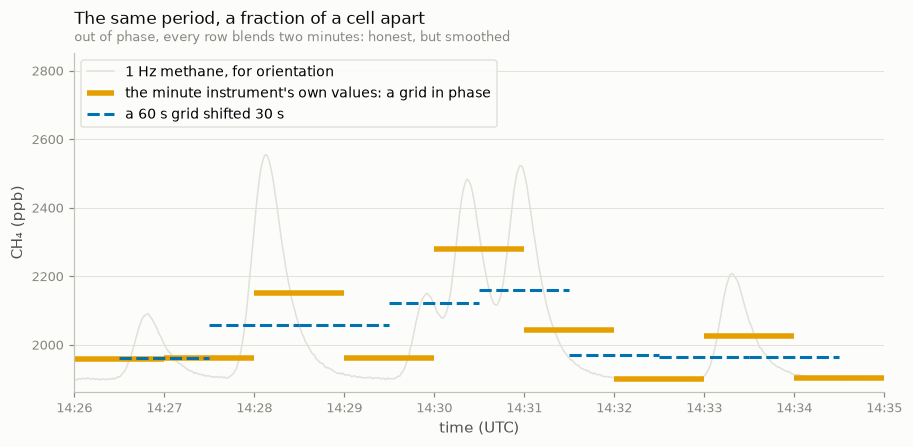

In [60]:
minute_streams = minute_campaign().streams
minute = minute_streams["minute"]
own_edge = pd.Timestamp(minute["time_bnds"].values[0, 0])
in_phase = build_output_grid({"minute": minute}, OutputGridConfig(freq="60s"), ["minute_ch4"])
shifted = build_output_grid(
    {"minute": minute},
    OutputGridConfig(freq="60s", start=own_edge + pd.Timedelta(seconds=GRID_START_SHIFT_S)),
    ["minute_ch4"],
)
own = minute["minute_ch4"].values
check(
    "§12 a grid in phase with an instrument reproduces its values exactly, one reading per row",
    np.array_equal(in_phase["minute_ch4"].values, own, equal_nan=True)
    and set(in_phase["n_readings_minute_ch4"].values) == {1},
)
blend = shifted["n_readings_minute_ch4"].values
interior = blend[1:-1]
if GRID_START_SHIFT_S % 60 == 0:
    check("§12 a shift of whole minutes stays in phase: one reading per row", set(interior) == {1})
else:
    check("§12 a grid out of phase blends two minutes in every interior row", set(interior) == {2})
print(
    f"shifted {GRID_START_SHIFT_S} s: {int((blend == 2).sum())} of {blend.size} rows "
    "blend two minutes; "
    f"tallest row {np.nanmax(shifted['minute_ch4'].values) - 1900:.0f} ppb above background, "
    f"against the tallest minute's {np.nanmax(own) - 1900:.0f}"
)

# Figure only from here.
peak = pd.Timestamp(minute["time"].values[int(np.nanargmax(own))])
around = (peak - pd.Timedelta("4min"), peak + pd.Timedelta("4min"))
own_near, off_near = (s.sel(time=slice(*around)) for s in (minute, shifted))
# The 1 Hz trace a minute wider each side, so it spans every bar drawn.
trace = minute_streams["fast"].sel(
    time=slice(around[0] - pd.Timedelta("60s"), around[1] + pd.Timedelta("60s"))
)
o0, o1 = bounds_of(own_near)
h0, h1 = bounds_of(off_near)
t_trace, v_trace = break_gaps(trace["time"].values, trace["ch4"].values)
fig, ax = plt.subplots(figsize=(9.5, 4.0))
ax.plot(t_trace, v_trace, color=GRID, lw=1.0, label="1 Hz methane, for orientation")
ax.hlines(
    own_near["minute_ch4"].values,
    o0,
    o1,
    color=C2,
    lw=3.6,
    label="the minute instrument's own values: a grid in phase",
)
ax.hlines(
    off_near["minute_ch4"].values,
    h0,
    h1,
    color=C1,
    lw=2.0,
    ls=(0, (4, 1.5)),
    label=f"a 60 s grid shifted {GRID_START_SHIFT_S} s",
)
lo, hi = np.nanmin(v_trace), np.nanmax(v_trace)
ax.set_ylim(lo - 0.05 * (hi - lo), hi + 0.45 * (hi - lo))
ax.set_xlim(min(o0[0], h0[0]), max(o1[-1], h1[-1]))
finish(
    ax,
    "The same period, a fraction of a cell apart",
    "out of phase, every row blends two minutes: honest, but smoothed",
    "CH₄ (ppb)",
    "time (UTC)",
)
ax.legend(loc="upper left", frameon=True, facecolor=SURFACE, edgecolor=GRID, framealpha=0.95)
hhmm(ax)
plt.show()

In phase, the grid *is* the instrument: every value passes through untouched.
Shifted, every row averages two neighbouring minutes, the tallest row stands
below the tallest minute, `n_readings` says 2, and the grid warns (above the
figure). It warns rather than refuses because blending is sometimes unavoidable:
in a campaign whose instruments do not share boundaries a grid can be in phase
with at most one of them, and which one is the user's choice, made with
`start`. What being out of phase costs a *ratio* is measured next, on a
two-species campaign whose true ratio is known.

**Try it.** `GRID_START_SHIFT_S = 10`: still a blend of two minutes in every
row, weighted five to one, so the smoothing is milder.

In [61]:
# The same blend, priced as a ratio. Two species emitted at a fixed ratio
# (section 14's acceptance campaign, no noise), gridded on the slow
# instrument's own boundaries and on the default epoch-anchored start, which
# its mid-labelled minutes sit half a cell off.
RATIO_TRUE = 0.25
ratio_streams = acceptance_campaign(true_ratio=RATIO_TRUE).streams


def grid_ratio(grid):
    """Mass-weighted tracer-to-methane ratio over fully covered, enhanced rows."""
    methane = grid["ch4"].values - 1900.0
    usable = (grid["coverage_ch4"].values >= 1.0 - 1e-12) & np.isfinite(methane) & (methane > 1.0)
    return grid["tracer"].values[usable].sum() / methane[usable].sum()


slow_edge = pd.Timestamp(ratio_streams["tracer_60s"]["time_bnds"].values[0, 0])
ratios = {}
for label, config in (
    ("epoch-anchored (the default)", OutputGridConfig(freq="60s")),
    ("on the slow instrument's boundaries", OutputGridConfig(freq="60s", start=slow_edge)),
):
    grid = build_output_grid(ratio_streams, config, ["ch4", "tracer"])
    ratios[label] = grid_ratio(grid)
    print(
        f"{label:36} ratio {ratios[label]:.9f}; rows blending two tracer minutes: "
        f"{int((grid['n_readings_tracer'].values == 2).sum())}"
    )
check(
    "§12 a grid in phase with the slow instrument reproduces a known ratio (error below 1e-6)",
    abs(ratios["on the slow instrument's boundaries"] / RATIO_TRUE - 1) < 1e-6,
)

2026-09-23 12:22:15 | WARNING  | tsara.align.grid | Stream 'tracer_60s' has cells exactly as wide as the 60 s grid period but offset from it by 30 s, so every grid value will blend two of its cells (n_readings = 2) rather than reproduce one. Set the grid start to one of its cell boundaries to avoid the smoothing.


2026-09-23 12:22:15 | WARNING  | tsara.align.binning | 1 column(s) of this join rest on air the readings did not measure over the cells reported (METHODS §11.2.4): 'tracer' (121 rows from 120 readings; borrowed share 0.50). A reading wider than the cell it fills has its value stand for a shorter interval than it measured; rows outnumbering readings means some reading sits in more than one row, which a fit or receptor model treating rows as independent counts more than once. Each column records tsara_support_transform, tsara_width_ratio_max, tsara_borrowed_share and tsara_n_readings, and carries the share borrowed per cell in borrowed_<name>.


epoch-anchored (the default)         ratio 0.249940526; rows blending two tracer minutes: 119
on the slow instrument's boundaries  ratio 0.250000034; rows blending two tracer minutes: 0
  ✔ §12 a grid in phase with the slow instrument reproduces a known ratio (error below 1e-6)


On the slow instrument's own boundaries the grid gives back the ratio to within
rounding. On the default start it moves in the fifth significant figure: each
row's methane is still that row's minute, binned from 1 Hz, while its tracer is
now the mean of two minutes, so the two columns in one row no longer describe
the same air. Nothing is silently wrong -- `n_readings` reports the blend and the
grid warned -- but the default start is a convention for making grids line up
with each other, not a promise to line up with any instrument.

---
### Why there is no median

A grid row could have been the *median* of its readings rather than their mean,
and the Phase 1 schema offered that choice. It was deleted before anything used
it (`METHODS.md` §11.7.1). A median exists to ignore a short excursion, and in
this science a short excursion is the plume. TSARA offers no median, so the
medians below are computed by hand, on four-hour 1 Hz records whose plumes
differ only in how sharp they are.

In [62]:
# ---- PARAMETERS (section 12, median) -----------------------------------------
PLUME_SHAPES = [
    ("2s", "4s"),
    ("6s", "12s"),
    ("15s", "30s"),
    ("40s", "80s"),
    ("120s", "240s"),
]  # (rise, tail)
ENHANCED_ABOVE_PPB = 5.0  # a minute counts as enhanced when its mean exceeds background by this

plume rise   2s, tail   4s:  97 enhanced minutes; a median discards  86.1% of their enhancement
plume rise   6s, tail  12s: 134 enhanced minutes; a median discards  32.0% of their enhancement
plume rise  15s, tail  30s: 200 enhanced minutes; a median discards   3.2% of their enhancement
plume rise  40s, tail  80s: 236 enhanced minutes; a median discards   0.1% of their enhancement


plume rise 120s, tail 240s: 239 enhanced minutes; a median discards   0.0% of their enhancement


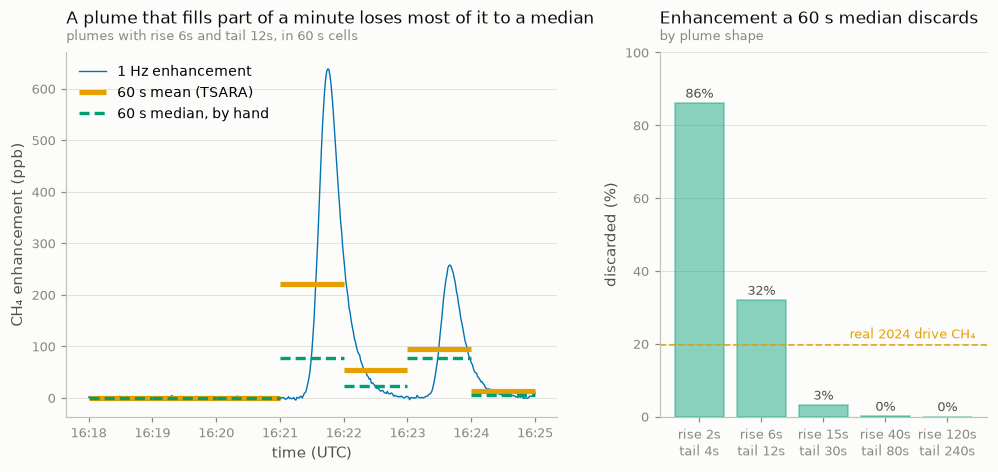

In [63]:
def minute_medians(stream, cells):
    """Median of the readings timestamped inside each cell: by hand, NOT TSARA."""
    stamps = stream["time"].values.astype("datetime64[ns]").astype("int64")
    row = np.searchsorted(cells.start_ns, stamps, side="right") - 1
    inside = (row >= 0) & (stamps < cells.stop_ns[np.clip(row, 0, len(cells) - 1)])
    by_row = pd.Series(stream["ch4"].values[inside]).groupby(row[inside]).median()
    out = np.full(len(cells), np.nan)
    out[by_row.index.to_numpy()] = by_row.to_numpy()
    return out


discarded, examples = [], {}
for rise, tail in PLUME_SHAPES:
    sharp = minute_campaign(
        duration="4h", include_minute=False, dropouts_per_day=0.0, plume_sigma=rise, plume_tau=tail
    ).streams["fast"]
    cells = uniform_cells(pd.Timestamp(sharp["time_bnds"].values[0, 0]).ceil("min"), 60.0, 239)
    mean_enh = (
        bin_streams_onto_cells({"fast": sharp}, cells, ["ch4"])["ch4"].values - 1900.0
    )  # TSARA's mean
    median_enh = minute_medians(sharp, cells) - 1900.0  # the median, by hand
    enhanced = mean_enh > ENHANCED_ABOVE_PPB
    # Share of the enhanced minutes' enhancement a median would discard;
    # a negative median counts as zero.
    discarded.append(1.0 - np.clip(median_enh[enhanced], 0, None).sum() / mean_enh[enhanced].sum())
    examples[rise] = (sharp, cells, mean_enh, median_enh)
    print(
        f"plume rise {rise:>4}, tail {tail:>4}: {int(enhanced.sum()):>3} enhanced minutes; "
        f"a median discards {discarded[-1]:6.1%} of their enhancement"
    )

# Figure only from here: one stretch of the second shape.
sharp, cells, mean_enh, median_enh = examples[PLUME_SHAPES[1][0]]
worst = int(np.nanargmax(mean_enh - np.clip(median_enh, 0, None)))
pick = slice(max(worst - 3, 0), worst + 4)
c0, c1 = cells.start_ns[pick].astype("datetime64[ns]"), cells.stop_ns[pick].astype("datetime64[ns]")
segment = sharp.sel(time=slice(pd.Timestamp(c0[0]), pd.Timestamp(c1[-1])))
fig, (axl, axr) = plt.subplots(
    1, 2, figsize=(10.8, 4.3), gridspec_kw={"width_ratios": [1.5, 1.0], "wspace": 0.25}
)
axl.plot(
    segment["time"].values,
    segment["ch4"].values - 1900.0,
    color=C1,
    lw=0.9,
    label="1 Hz enhancement",
)
axl.hlines(mean_enh[pick], c0, c1, color=C2, lw=3.4, label="60 s mean (TSARA)")
axl.hlines(
    median_enh[pick], c0, c1, color=C3, lw=2.2, ls=(0, (3, 1.5)), label="60 s median, by hand"
)
finish(
    axl,
    "A plume that fills part of a minute loses most of it to a median",
    f"plumes with rise {PLUME_SHAPES[1][0]} and tail {PLUME_SHAPES[1][1]}, in 60 s cells",
    "CH₄ enhancement (ppb)",
    "time (UTC)",
    legend=True,
    loc="upper left",
)
hhmm(axl)
axr.bar(range(len(PLUME_SHAPES)), np.array(discarded) * 100, color=C3, alpha=0.45, edgecolor=C3)
for i, share in enumerate(discarded):
    axr.text(i, share * 100 + 1.5, f"{share:.0%}", ha="center", fontsize=8.5, color=INK2)
axr.axhline(19.6, color=C2, lw=1.0, ls=(0, (4, 2)))
axr.text(len(PLUME_SHAPES) - 0.55, 21.5, "real 2024 drive CH₄", ha="right", fontsize=8.2, color=C2)
axr.set_xticks(range(len(PLUME_SHAPES)), [f"rise {r}\ntail {t}" for r, t in PLUME_SHAPES])
axr.set_ylim(0, 100)
finish(axr, "Enhancement a 60 s median discards", "by plume shape", "discarded (%)", None)
plt.show()

**What to read off the output.** On the left, the mean carries each plume's
whole contribution, spread over its minute; the median reports the middle
reading, which in a minute a plume only partly fills sits at or near the
background. On the right, how much enhancement disappears depends almost
entirely on how sharp plumes are relative to the cell: nearly all of it for
plumes a few seconds wide, nothing once they are wider than the cell. On the real
2024 drive methane, under the same rule with a rolling baseline, it is 19.6 %.

**That dependence, more than the size, is why the option was deleted.** Two
species on one grid whose plumes differ in sharpness lose different fractions,
so a ratio of their median columns is biased by the difference, with nothing in
the matrix to say so. Biased between-species ratios are exactly what TSARA must
not produce.

**Try it.** `ENHANCED_ABOVE_PPB = 50.0`: only the strongest minutes count. The
sharp shapes still lose most of their enhancement.

---
### A uniform grid spans the gaps

A uniform grid runs from the first selected cell to the last, so a campaign of
separate drives puts every hour *between* the drives into the matrix too.

In [64]:
# ---- PARAMETERS (section 12, spanning) --------------------------------------
DAYS_BETWEEN_DRIVES = 7
SPAN_PERIOD = "1s"

In [65]:
drives = two_drives(days_between=DAYS_BETWEEN_DRIVES)
first_edge = pd.Timestamp(drives["drive1"]["time_bnds"].values[0, 0])  # in phase with both drives
spanning = build_output_grid(drives, OutputGridConfig(freq=SPAN_PERIOD, start=first_edge))
any_data = (spanning["n_readings_ch4"].values > 0) | (spanning["n_readings_ch4_later"].values > 0)
span_ns = int(cells_of(drives["drive2"]).stop_ns[-1] - first_edge.value)
print(
    f"{SPAN_PERIOD} grid over two 30-minute drives {DAYS_BETWEEN_DRIVES} days apart: "
    f"{spanning.sizes['time']:,} rows, "
    f"{any_data.mean():.2%} of them holding any data, {spanning.nbytes / 1e6:.0f} MB in memory"
)
check(
    "§12 the grid's rows are exactly the span divided by the period",
    spanning.sizes["time"] == int(np.ceil(span_ns / pd.Timedelta(SPAN_PERIOD).value)),
)

1s grid over two 30-minute drives 7 days apart: 606,600 rows, 0.59% of them holding any data, 53 MB in memory
  ✔ §12 the grid's rows are exactly the span divided by the period


Well under one percent of those rows hold anything, and the cost scales with the
gap rather than with the data. On the real 2024 drive days a one-second grid spans
a month and is 92 % empty, about 95 MB per variable (`METHODS.md` §11.7). A
continuous rolling state wants that uniform span, gaps and all. A receptor-model
matrix does not, and is better built one drive at a time with `start` and `end`.

**Try it.** `DAYS_BETWEEN_DRIVES = 14`: roughly twice the rows and memory, for the
same data. `SPAN_PERIOD = "60s"`: sixty times fewer rows.

---
### The grid on disk

The campaign grid is the product this phase saves: a single netCDF file inside a
bundle directory, carrying its own provenance. It has to come back as the same
object.

In [66]:
# ---- PARAMETERS (section 12, saving) -------------------------------------------
COMPRESSION_LEVEL = 4  # zlib level 1 (fastest) to 9 (smallest), or None

In [67]:
written = save_grid(grid60, WORK / "bundle")
reloaded = load_grid(WORK / "bundle")
check(
    "§12 a saved grid reloads with every column and attribute identical",
    all(
        np.array_equal(grid60[v].values, reloaded[v].values, equal_nan=True)
        and grid60[v].attrs == reloaded[v].attrs
        for v in grid60.data_vars
    )
    and "time_bnds" in reloaded.coords,
)
print(
    f"written {written.name}; stage '{reloaded.attrs['tsara_stage']}'; readings behind benzene "
    f"{reloaded['benzene'].attrs['tsara_n_readings']}"
)
try:
    save_grid(pair_species(streams, "benzene", "ch4").dataset, WORK / "not_a_grid")
    refused_pair = False
except TsaraBundleError as refusal:
    refused_pair = True
    print("saving a paired product as a grid:", str(refusal).split(". ")[0] + ".")
check("§12 save_grid refuses anything load_grid would refuse to read", refused_pair)

# The spanning grid above, mostly empty, is where compression matters.
sizes, identical = {}, True
for level in (None, COMPRESSION_LEVEL):
    path = save_grid(spanning, WORK / f"sparse_{level}", compression=level)
    back = load_grid(WORK / f"sparse_{level}")
    identical &= all(
        np.array_equal(spanning[v].values, back[v].values, equal_nan=True)
        for v in spanning.data_vars
    )
    sizes[level] = path.stat().st_size / 1e6
    print(
        f"two drives {DAYS_BETWEEN_DRIVES} days apart on a {SPAN_PERIOD} grid, "
        f"compression={level!s:>4}: {sizes[level]:6.2f} MB on disk"
    )
check("§12 a compressed grid reloads with every value identical", identical)

  ✔ §12 a saved grid reloads with every column and attribute identical
written grid.nc; stage 'gridded'; readings behind benzene 55
saving a paired product as a grid: save_grid writes gridded products, and this dataset's tsara_stage is 'paired'.
  ✔ §12 save_grid refuses anything load_grid would refuse to read


two drives 7 days apart on a 1s grid, compression=None:  53.40 MB on disk


two drives 7 days apart on a 1s grid, compression=   4:   0.33 MB on disk
  ✔ §12 a compressed grid reloads with every value identical


The grid comes back exactly, cells and provenance included, and `save_grid`
refuses to write anything `load_grid` would refuse to read. A paired product is an
ordinary dataset, saved with `to_netcdf`.

Compression is opt-in, and on a sparse grid it is most of the file: the regular
time axis and the empty rows compress almost to nothing. On the one-second grid
over the ten 2024 drive days the file goes from 346 MB to under 4 MB at level 4,
for about twice the write time (`METHODS.md` §11.7). The default stays
uncompressed, because a single drive's grid is dense and fastest as it is.

---
## 13. Joining a product that was already joined, and why it is refused

**The question.** A grid is a dataset with cells, like any stream, so it could
be binned again: onto a coarser grid, or by a later stage onto another target.
Would that give the same answer as building the coarser product from the native
streams?

**No, and not in a way anything downstream could repair.** The second pass
cannot see what the first one knew. It reads three things from each input row —
the value, the interval it describes, and how much of that interval holds data —
and on a product all three describe a **row** rather than a measurement. A
minute row holding one 15 s canister fill is weighted, counted and reported as a
fully measured minute.

So `bin_streams_onto_cells` now refuses any input whose `tsara_stage` says TSARA
built it by joining (`binned`, `paired`, `gridded`), and pairing and the grid
inherit the refusal, since all three resolve their selection through the same
function. The cell below shows the refusal, and then what the refused operation
would have produced -- by deleting the product's `tsara_stage` label, which is a
demonstration device and not a supported route: a product stripped of its stage
no longer says what it is, and nothing downstream can tell.

In [68]:
# ---- PARAMETERS (section 13) --------------------------------------------------
FINE_PERIOD = "60s"
COARSE_PERIOD = "300s"

In [69]:
start_section("§13")

canister = canister_campaign()
fine_grid = build_output_grid(
    canister.streams, OutputGridConfig(freq=FINE_PERIOD), ["ch4", "benzene"]
)

# 1. What TSARA does now.
try:
    build_output_grid({"grid": fine_grid}, OutputGridConfig(freq=COARSE_PERIOD))
    refused = None
except TsaraAlignError as error:
    refused = error
print(f"re-gridding the {FINE_PERIOD} grid onto {COARSE_PERIOD} cells:\n  {refused}\n")
check("§13 a product may not be joined again", refused is not None)

# 2. What it would have produced. The refusal keys on `tsara_stage`, so
#    removing that attribute is enough to run the operation for illustration --
#    which is exactly what makes it a demonstration rather than a claim.
as_if_a_stream = fine_grid.copy()
del as_if_a_stream.attrs["tsara_stage"]
from_grid = build_output_grid({"grid": as_if_a_stream}, OutputGridConfig(freq=COARSE_PERIOD))
from_streams = build_output_grid(
    canister.streams, OutputGridConfig(freq=COARSE_PERIOD), ["ch4", "benzene"]
)

held = from_streams["n_readings_benzene"].values > 0
apart = np.abs(from_streams["benzene"].values - from_grid["benzene"].values)[held]
table = {
    "rows holding benzene": [
        int((p["n_readings_benzene"].values > 0).sum()) for p in (from_streams, from_grid)
    ],
    "readings recorded": [
        p["benzene"].attrs["tsara_n_readings"] for p in (from_streams, from_grid)
    ],
    "median coverage": [
        f"{np.median(p['coverage_benzene'].values[held]):.3f}" for p in (from_streams, from_grid)
    ],
}
grid_heading = f"from the {FINE_PERIOD} grid"
print(f"benzene on {COARSE_PERIOD} rows      {'from the streams':>17} {grid_heading:>18}")
for row_label, (a, b) in table.items():
    print(f"{row_label:27} {a!s:>17} {b!s:>18}")
print(
    f"{'values that differ':27} {'':>17} {int((apart > 1e-12).sum()):>18}   "
    f"(largest {apart.max():.3f} ppb)"
)

# Section 2's methane: the five minutes holding the dropout.
minute_streams = minute_campaign().streams
minute_product = bin_streams_onto_cells(minute_streams, cells_of(minute_streams["minute"]), ["ch4"])
del minute_product.attrs["tsara_stage"]
own_edge = pd.Timestamp(minute_streams["minute"]["time_bnds"].values[0, 0])
five = uniform_cells(own_edge, 300.0, 12)
straight = bin_streams_onto_cells(minute_streams, five, ["ch4"])
again = bin_streams_onto_cells({"minutes": minute_product}, five, ["ch4"])
worst = int(np.argmax(np.abs(straight["ch4"].values - again["ch4"].values)))
print("\nsection 2's methane, the five minutes holding the dropout:")
# n_readings counts whatever went in. From the stream those are readings; from
# the minute product they are that product's rows -- which is the whole problem.
for label, product, inputs in (
    ("from the 1 Hz stream", straight, "readings"),
    ("from the minute rows", again, "minute rows"),
):
    print(
        f"    {label:22}: coverage {product['coverage_ch4'].values[worst]:.3f}, "
        f"n_readings {product['n_readings_ch4'].values[worst]:>3} ({inputs}), "
        f"{product['ch4'].values[worst]:.2f} ppb"
    )
check(
    "§13 the refused operation is the one that would have been wrong",
    abs(straight["ch4"].values[worst] - again["ch4"].values[worst]) > 1.0,
)

2026-09-23 12:22:17 | WARNING  | tsara.align.binning | 1 column(s) of this join rest on air the readings did not measure over the cells reported (METHODS §11.2.4): 'benzene' (69 rows from 55 readings; borrowed share 0.09). A reading wider than the cell it fills has its value stand for a shorter interval than it measured; rows outnumbering readings means some reading sits in more than one row, which a fit or receptor model treating rows as independent counts more than once. Each column records tsara_support_transform, tsara_width_ratio_max, tsara_borrowed_share and tsara_n_readings, and carries the share borrowed per cell in borrowed_<name>.


2026-09-23 12:22:17 | WARNING  | tsara.align.binning | 1 column(s) of this join rest on air the readings did not measure over the cells reported (METHODS §11.2.4): 'benzene' (57 rows from 55 readings; borrowed share 0.03). A reading wider than the cell it fills has its value stand for a shorter interval than it measured; rows outnumbering readings means some reading sits in more than one row, which a fit or receptor model treating rows as independent counts more than once. Each column records tsara_support_transform, tsara_width_ratio_max, tsara_borrowed_share and tsara_n_readings, and carries the share borrowed per cell in borrowed_<name>.


re-gridding the 60s grid onto 300s cells:
  'grid' is a product this package built (tsara_stage is 'gridded'), and a product may not be joined again. Its rows are not readings: their coverage, counts and overlap weights describe the rows of the first join rather than the air, so a second pass would report a fully covered row over an interval that was barely measured (METHODS §11.2.3). Build what you want directly from the native streams, which is always possible and exact.

  ✔ §13 a product may not be joined again
benzene on 300s rows       from the streams  from the 60s grid
rows holding benzene                       57                 57
readings recorded                          55                 69
median coverage                         0.050              0.200
values that differ                                             3   (largest 0.068 ppb)

section 2's methane, the five minutes holding the dropout:
    from the 1 Hz stream  : coverage 0.922, n_readings 277 (readings), 196

**What it shows.** Mechanically the second pass works, which is what made it
dangerous: companion columns are excluded by default, so nothing like
`coverage_coverage_benzene` appears, and every number looks ordinary. Three of
them describe rows instead of air.

* **Coverage.** From the streams, a 15 s fill covers 0.05 of a five-minute row.
  From the grid, the minute holding it counts as fully measured, so the row
  reports 0.2.
* **Counts.** A fill split across two minute rows arrives as two contributing
  cells, so the column records more readings than there are fills.
* **Weights.** From the streams, each fill is weighted by how much of it falls
  inside the row; from the grid, by the whole minute row holding it, so a fill
  with 3 s inside the row counts as much as one with all 15 s.

The methane case is the plainest. Section 2's dropouts enter their five-minute
rows at full weight: the row where that matters most reports a coverage of
1.000 where 8 % of its five minutes was never measured, and its value moves by
about 5 ppb. That is the failure §4 exists to prevent — `coverage` claiming a
value is better determined than it is — reached by a different route.

**Why refuse rather than warn.** A *nested* re-join, where every input row lies
wholly inside one target cell, can be made exact by weighting each row by its
own coverage: measured, that recovers the values to 10⁻¹² ppb and the coverage
exactly. It is recorded in `METHODS.md` §11.2.3 and not built, because it
repairs values and coverage but not counts, and because the non-nested case
cannot be repaired at all. Cutting a row assigns that row's mean to both sides,
and the air in the two halves differs. Measured on the campaign in
`METHODS.md` §11.2.3, a 270 s re-join of 60 s rows is about 6 ppb out whatever
the weighting. That is *narrowing*, and the information is already gone from
the input.

Nothing needs the capability. Every product can be rebuilt from the native
streams, exactly, which is what the refusal's message says and what the first
column of the table above does.

---
## 14. Does an enhancement ratio survive the whole path?

**The question.** Every section so far tested a piece. Does the whole join
preserve the thing TSARA exists to measure, an enhancement ratio? And would the
check notice if it did not?

**The campaign** (`acceptance_campaign`). One source emits two species into the
atmosphere, methane and a tracer, with the ratio between them fixed at 0.25.
`methane_1s` measures methane as 1 s means and `tracer_60s` the tracer as 60 s
means, both with **no noise at all**. If pairing averages both over the same air, that
ratio comes back to within rounding. If it averages them over different air, the
ratio drifts, and nothing else would say so, because every individual number
still looks plausible.

Two scores, from `pair_species` with `min_coverage=1.0`: the **mass-weighted
ratio** (total tracer over total methane enhancement), which is what a
regression slope estimates, and the **per-cell ratio**, every pair on its own,
which is harsher. The package's own acceptance tests require errors below 10⁻⁶
and 10⁻⁴.

**How the check is tested.** A pass is only worth something if the check would
*fail* on the error it exists for. So the fast stream is moved later by a known
amount, the misplacement a misread label or a wrong clock offset would cause,
and the scores are recomputed.

In [70]:
# ---- PARAMETERS (section 14) --------------------------------------------------
SEED = 4242
TRUE_RATIO = 0.25
PLUME_SIGMA = "90s"  # width of the Gaussian plumes
FAST_LABEL = "mid"  # "mid": 1 s methane cells centred on whole seconds; "start": starting on them
SLOW_SUBSAMPLES = 64  # points the generator averages inside each 60 s tracer cell
SHIFTS_S = [0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0, 30.0]  # misplacements of the fast stream to test

mass-weighted ratio error: 1.4e-07    per-cell median error: 8.1e-06

  ✔ §14 the mass-weighted ratio survives the join (error below 1e-6)   [1.4e-07]
  ✔ §14 the per-cell ratio survives the join (median error below 1e-4)   [8.1e-06]
fast stream  0.10 s late: mass error 9.1e-06, per-cell 3.4e-04
fast stream  0.25 s late: mass error 2.3e-05, per-cell 8.3e-04
fast stream  0.50 s late: mass error 4.5e-05, per-cell 1.7e-03


fast stream  1.00 s late: mass error 9.1e-05, per-cell 3.3e-03
fast stream  2.00 s late: mass error 1.8e-04, per-cell 6.7e-03
fast stream  5.00 s late: mass error 4.6e-04, per-cell 1.7e-02
fast stream 10.00 s late: mass error 9.4e-04, per-cell 3.4e-02
fast stream 30.00 s late: mass error 3.0e-03, per-cell 1.0e-01

  ✔ §14 the check has teeth: every tested misplacement fails at least one threshold


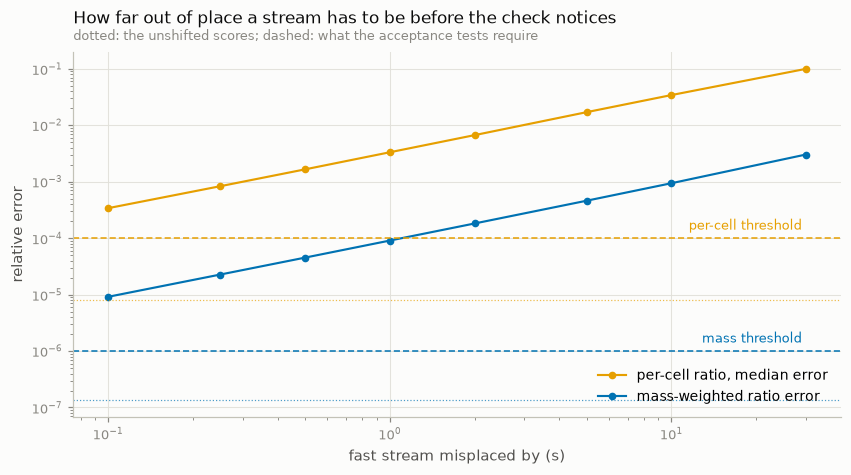

In [71]:
start_section("§14")
MASS_THRESHOLD, CELL_THRESHOLD = 1e-6, 1e-4


def acceptance_scores(streams):
    """Mass-weighted and median per-cell ratio errors over fully covered, enhanced pairs."""
    pairs = pair_species(streams, "tracer", "ch4", min_coverage=1.0).dataset
    tracer, methane = pairs["tracer"].values, pairs["ch4"].values - 1900.0
    keep = np.isfinite(methane) & np.isfinite(tracer) & (methane > 1.0)
    mass = abs((tracer[keep].sum() / methane[keep].sum()) / TRUE_RATIO - 1.0)
    per_cell = float(np.median(np.abs((tracer[keep] / methane[keep]) / TRUE_RATIO - 1.0)))
    return mass, per_cell


accepted = acceptance_campaign(
    seed=SEED,
    true_ratio=TRUE_RATIO,
    plume_sigma=PLUME_SIGMA,
    fast_label=FAST_LABEL,
    slow_subsamples=SLOW_SUBSAMPLES,
)
mass_error, cell_error = acceptance_scores(accepted.streams)
print(f"mass-weighted ratio error: {mass_error:.1e}    per-cell median error: {cell_error:.1e}\n")
check(
    "§14 the mass-weighted ratio survives the join (error below 1e-6)",
    mass_error < MASS_THRESHOLD,
    f"{mass_error:.1e}",
)
check(
    "§14 the per-cell ratio survives the join (median error below 1e-4)",
    cell_error < CELL_THRESHOLD,
    f"{cell_error:.1e}",
)

mass_curve, cell_curve = [], []
fast = accepted.streams["methane_1s"]
for shift_s in SHIFTS_S:
    delta = np.timedelta64(round(shift_s * SECOND), "ns")
    late = fast.assign_coords(
        time=fast["time"].values + delta,
        time_bnds=(("time", "nv"), fast["time_bnds"].values + delta),
    )
    mass, cell = acceptance_scores({**accepted.streams, "methane_1s": late})
    mass_curve.append(mass)
    cell_curve.append(cell)
    print(f"fast stream {shift_s:>5.2f} s late: mass error {mass:.1e}, per-cell {cell:.1e}")
print()
check(
    "§14 the check has teeth: every tested misplacement fails at least one threshold",
    all(m >= MASS_THRESHOLD or c >= CELL_THRESHOLD for m, c in zip(mass_curve, cell_curve)),
)

# Figure only from here.
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.loglog(SHIFTS_S, cell_curve, "o-", color=C2, ms=4, label="per-cell ratio, median error")
ax.loglog(SHIFTS_S, mass_curve, "o-", color=C1, ms=4, label="mass-weighted ratio error")
for threshold, colour, text in (
    (CELL_THRESHOLD, C2, "per-cell threshold "),
    (MASS_THRESHOLD, C1, "mass threshold "),
):
    ax.axhline(threshold, color=colour, lw=1.0, ls=(0, (4, 2)))
    ax.text(
        SHIFTS_S[-1], threshold * 1.25, text, ha="right", va="bottom", fontsize=8.2, color=colour
    )
ax.axhline(cell_error, color=C2, lw=0.8, ls=":", alpha=0.7)
ax.axhline(max(mass_error, 1e-12), color=C1, lw=0.8, ls=":", alpha=0.7)
finish(
    ax,
    "How far out of place a stream has to be before the check notices",
    "dotted: the unshifted scores; dashed: what the acceptance tests require",
    "relative error",
    "fast stream misplaced by (s)",
    legend=True,
    loc="lower right",
    grid_axis="both",
)
plt.show()

**What to read off the output.** Unshifted, both scores are far inside their
thresholds. Shifted, both sit above their thresholds at every shift tested, down
to a tenth of a second. The mass-weighted ratio is the more forgiving quantity (a
shift moves methane between neighbouring minutes without changing the total
much), but its threshold is strict enough that a tenth of a second still fails
it. Both grow in proportion to the shift, which is what a misplacement looks
like, as opposed to noise.

**Try it.**

* `PLUME_SIGMA = "5s"`: plumes a few seconds wide, and both unshifted checks
  **fail**. There are two causes and it takes **both** fixes to pass again, which
  is worth doing in order:

  | parameters | mass-weighted | per-cell median | |
  |---|---|---|---|
  | as shipped, 90 s plumes | 1.4 × 10⁻⁷ | 8.1 × 10⁻⁶ | pass |
  | `PLUME_SIGMA = "5s"` | 3.2 × 10⁻⁵ | 1.0 × 10⁻³ | both fail |
  | and `SLOW_SUBSAMPLES = 1024` | 2.7 × 10⁻⁵ | 7.6 × 10⁻⁴ | still fail |
  | instead, `FAST_LABEL = "start"` | 5.2 × 10⁻⁶ | 2.3 × 10⁻⁴ | still fail |
  | **both together** | 3.7 × 10⁻⁸ | 8.4 × 10⁻⁷ | pass |

  The third row is the generator's own quadrature: raising its subsamples
  barely helps *while the other term dominates*. The fourth is that term — the
  1 s methane cells are centred on whole seconds, so one straddles every minute
  boundary and the join gives half of that second's mean to each minute, which
  is exact only if the air was flat within that second. A 1 s mean says nothing
  about how the air varied inside it, and for a 5 s plume it was not flat.
  `FAST_LABEL = "start"` removes the straddle.

  The instructive part is the last row against the fourth: with the straddle
  gone, the subsamples that "barely helped" are suddenly worth a factor of 140.
  The two terms are not independent in the way the old wording implied — **the
  bigger one was hiding the smaller**, and neither alone gets you there.
  **The finest detail any join can respect is the input's own cell.** A failure
  you can attribute, and then make go away, is the most convincing kind.
* `SHIFTS_S = [0.01, 0.05]`: find where the check stops seeing a misplacement.

---
### The same check through real files

The acceptance campaign above is built straight from the generator, so it never
*reads* a timestamp label. A label misread during ingestion is a different code
path, caught there by the round-trip harness and the support tests. What this
check adds is the size of the consequence. The same campaign, written to files
with the slow instrument's timestamps naming the *start* of each minute, and
ingested with the label declared and without it:

In [72]:
start_labelled = acceptance_campaign(
    seed=SEED,
    true_ratio=TRUE_RATIO,
    plume_sigma=PLUME_SIGMA,
    fast_label=FAST_LABEL,
    slow_label="start",
    slow_subsamples=SLOW_SUBSAMPLES,
)
scores = {}
for declaration in ("declared", "none"):
    ingested = ingest_campaign(
        load_manifest(
            export_raw(
                start_labelled, WORK / f"accept_{declaration}", support_declaration=declaration
            )
        )
    )
    scores[declaration] = acceptance_scores(ingested)
    used = ingested["tracer_60s"].attrs["tsara_support_label"]
    print(
        f"label {declaration:>8} in the manifest -> TSARA uses '{used}': "
        f"mass error {scores[declaration][0]:.1e}, per-cell {scores[declaration][1]:.1e}"
    )
check(
    "§14 through real files with the label declared, the ratio survives",
    scores["declared"][0] < MASS_THRESHOLD and scores["declared"][1] < CELL_THRESHOLD,
)
check(
    "§14 with the label undeclared, the check fails as it should",
    scores["none"][0] >= MASS_THRESHOLD or scores["none"][1] >= CELL_THRESHOLD,
)

label declared in the manifest -> TSARA uses 'start': mass error 9.5e-08, per-cell 8.4e-06
label     none in the manifest -> TSARA uses 'unknown': mass error 2.3e-03, per-cell 9.5e-02
  ✔ §14 through real files with the label declared, the ratio survives
  ✔ §14 with the label undeclared, the check fails as it should


With the label declared, the ratio survives the whole path from files to pairs.
Without it, TSARA has to assume the timestamp sits mid-cell, every minute is
placed half a minute early, and the per-cell ratio is off by about a tenth. That
is the Phase 3.5 headline restated as a ratio: an undeclared label is not a
documentation nicety, it is a ratio error.

---
## 15. The scoreboard, and what is known to be imperfect

Every check this notebook ran, as it last ran. If you changed parameters and
re-ran sections, these are the results at *your* parameters.

In [73]:
held = [claim for claim, (ok, _) in CHECKS.items() if ok]
failed = [claim for claim, (ok, _) in CHECKS.items() if not ok]
sections = sorted({claim.split(" ", 1)[0] for claim in CHECKS}, key=lambda s: int(s.strip("§")))
for tag in sections:
    claims = [c for c in CHECKS if c.startswith(tag + " ")]
    print(f"{tag:>4}: {sum(CHECKS[c][0] for c in claims)} of {len(claims)} hold")
print(f"\n{len(held)} of {len(CHECKS)} checks hold.")
for claim in failed:
    print(f"  ✘ {claim}   [{CHECKS[claim][1]}]")

  §1: 6 of 6 hold
  §2: 4 of 4 hold
  §3: 3 of 3 hold
  §4: 5 of 5 hold
  §5: 5 of 5 hold
  §6: 6 of 6 hold
  §7: 13 of 13 hold
  §8: 8 of 8 hold
  §9: 6 of 6 hold
 §10: 6 of 6 hold
 §11: 5 of 5 hold
 §12: 13 of 13 hold
 §13: 2 of 2 hold
 §14: 5 of 5 hold

87 of 87 checks hold.


### What these checks do and do not establish

**They establish** that, on data whose truth is known, TSARA's joins compute the
overlap-weighted definition exactly; that its uncertainties match the scatter of
real random draws; that it refuses the operations that would invent data; that it
records rather than hides the readings it shares between rows; and that an
enhancement ratio survives the whole path, with a check sensitive to a tenth of
a second.

**They do not establish** that real instruments behave like the generator.
Notebook `04b` runs the same operations on the campaign archive, where there is
no answer key, and checks every archive number `METHODS.md` quotes.

### Known imperfections and open questions

1. **Readings shared between neighbouring pairs** (§9, dense rows). Two dense
   instruments half a cell apart give pairs that share errors, and a naive
   standard error is too narrow on either clock. The product records the blend
   (`borrowed_<name>` = 0.5, label `straddled`), counts the readings that formed
   two pairs (`tsara_shared_readings`), and names the remedy only when that count
   is not zero -- `pair_species(target=)` on a common clock five to ten times
   coarser, where the standard error is honest again (`METHODS.md` §11.4.1).
   Modelling the correlation from the overlap weights is still the regression
   phase's.
2. **Overlapping target cells give rows that are individually faithful and not
   independent** (§1, §4). Every column records how much of its value was
   borrowed; the warning that names shared columns is not issued for
   overlapping targets, because sharing is then the question asked.
3. **Narrowing is recorded, never priced** (§4). The only calibrated price is a
   faster stream's within-cell spread, and with a faster stream the honest
   operation is to bin it instead.
4. **The cheap correlated-error form is not always conservative** (§7). It is
   safe for one cadence with holes, which is every real stream here, and can
   report a third of the true uncertainty when a cell's gaps are strongly
   bimodal. `ar1_double_sum` is right in every case measured and is selectable.
5. **Section 6 shows the arithmetic is right *given* AR(1)**, not that real
   instrument error is AR(1). Drift or flicker would pass unnoticed.
6. **R is biased high from few readings** (§10). Not corrected, because a
   correction needs a distributional assumption; `n_readings` travels beside it.
7. **Unit-vector, not speed-weighted, wind means** (§10). A choice, documented;
   the speed-weighted direction is available by binning u and v.
8. **No archive file declares a decorrelation timescale** (§6, §7), so the
   correlated-error machinery is exercised only by tests today. Estimating τ from
   the data is recorded as a future avenue.

**Closed since the last read-through:** re-joining a joined product (§13) is
refused rather than open; the rule that summed a reading's shared time is
replaced by the per-pair width ratio (§4), which closes its two narrowing holes
and admits sliding windows; a declared sigma on a direction is dropped aloud
(§10); and the grid's out-of-phase warning prints seconds rather than raw
nanoseconds.